In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
fpaths = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists3/*.root")
print(f"found {len(fpaths)} files")

found 555 files


In [3]:
wissals_2022_runs = [8025, 8115, 8120, 8124, 8155, 8157, 8175, 8179, 8182, 8190, 8191, 8248, 8252, 8266, 8269, 8290, 8294, 8301, 8320, 8326, 8327, 8330, 8331, 8332, 8333, 8336, 8728, 8731, 8733, 8736, 8775, 8777, 8798, 8799, 8834, 8841, 8848, 8850, 8906, 8908, 8913, 8915, 8916, 8917, 8930, 8933, 8934, 8943, 8945, 8947, 8948, 8949, 8950, 8970, 8972, 8975, 8977, 8981, 8985, 8987, 9058, 9060, 9069, 9072, 9073, 9092, 9094, 9148, 9166, 9181, 9183, 9188]
wissals_2023_runs = [10604, 10605, 10615, 10694, 10695, 10699, 10700, 10701, 10729, 10732, 10733, 10738, 10775, 10792, 10794, 10796, 10829, 10847, 10849, 10857, 10859, 10881, 10921, 10928, 10955, 10956, 11041, 11070, 11081, 11082, 11086, 11088, 11089, 11093, 11096, 11098, 11127, 11156, 11208, 11211, 11212, 11213, 11243, 11523, 11527, 11528, 11583, 11584, 11585, 11586, 11589, 11590, 11595, 11597, 11613, 11700, 11703]
wissals_2024_noCaloNu_runs = [14743, 14758, 14760, 14767, 14769, 14771, 14777, 14797, 14799, 14804, 14809, 14810, 14906, 14954, 14971, 14972, 14974, 14975, 14977, 14980, 14981, 14985, 15007, 15015, 15016, 15024, 15025, 15031, 15032, 15034, 15050, 15051, 15052, 15055, 15059, 15269, 15270, 15287, 15290, 15387, 15388, 15390, 15391, 15394, 15398, 15415, 15422, 15425, 15429, 15432, 15434, 15438, 15439, 15445, 15446, 15683, 15685, 15687, 15751, 15754, 15755, 15758, 15762, 15763, 15766, 15784, 15785, 15786, 15787, 15789, 15790, 15814, 15818, 15820, 16800, 16929, 16930, 16931, 16934, 16937, 16938, 16940, 16941, 16943, 16974, 17018, 17023, 17095, 17102, 17147, 17199, 17230]
wissals_2024_CaloNu_runs = [15838, 15839, 15844, 15874, 15877, 15878, 15883, 15884, 15903, 15909, 15912, 15913, 15915, 15917, 15918, 15919, 15945, 15946, 15948, 15949, 15951, 15953, 15956, 15957, 15961, 15963, 15967, 15977, 15996, 15998, 16000, 16001, 16018, 16022, 16023, 16028, 16042, 16043, 16057, 16064, 16065, 16068, 16072, 16075, 16076, 16077, 16096, 16098, 16099, 16103, 16393, 16396, 16400, 16403, 16405, 16517, 16531, 16533, 16542, 16558, 16581, 16628, 16635, 16650, 16653, 16658, 16660, 16661, 16663, 16667, 16685, 16696, 16697, 16699, 16715, 16731, 16732, 16798, 16802, 16805, 16848, 16853, 16916, 16923]

good_runs = wissals_2022_runs + wissals_2023_runs + wissals_2024_noCaloNu_runs + wissals_2024_CaloNu_runs

In [4]:
print(f"Total number of good runs: {len(good_runs)}")

Total number of good runs: 305


In [5]:
cutflow = {}

runs_with_missing_waveforms = {}
complete_runs = set()
total_number_of_events = 0

run_yields = {}

for fpath in tqdm.tqdm(fpaths):
    with uproot.open(fpath) as f:
        tree = f["cutflow"]
        lumi = f["meta"].arrays(library="pd")["lumi"][0]
        df = tree.arrays(library="pd")

        # print(f"Run {fpath} has lumi {lumi}")
        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        if run not in good_runs:
            # print(f"Run {run} is not in the good runs list, skipping")
            continue

        
        # if len(lumi) == 0 or lumi == 0:
        #     # print(f"Run {fpath} has zero lumi, skipping")
        #     continue

    for idx, row in df.iterrows():
        cut = row["cut_name"]
        all = row["all"]
        passed = row["passed"]

        if cut not in cutflow:
            cutflow[cut] = {"all": 0, "passed": 0}

        cutflow[cut]["all"] += all
        cutflow[cut]["passed"] += passed
    
    all_events = np.amax(df["all"])
    final_yield = np.amin(df["passed"])
    total_number_of_events += all_events
    run_yields[int(run)] = final_yield


    # print(f"{total_number_of_events:,.2g}")
    
    # all_in_ = cutflow["Sanity check for aux lookup"]["all"]
    # passed_in_ = cutflow["Sanity check for aux lookup"]["passed"]

    # if all_in_ != passed_in_:
    #     runs_with_missing_waveforms[run] = (all_in_, passed_in_)
    # else:
    #     complete_runs.add(run)

  0%|          | 1/555 [00:00<01:54,  4.84it/s]

100%|██████████| 555/555 [01:41<00:00,  5.48it/s]


In [6]:
print(f"Found {len(runs_with_missing_waveforms)} runs with missing waveforms:")

n_2022_runs = 0
n_2023_runs = 0
n_2024_preCaloNu_runs = 0
n_2024_CaloNu_runs = 0
n_2024_afterCaloNu_runs = 0

n_2022_missing_waveforms = 0
n_2023_missing_waveforms = 0
n_2024_preCaloNu_missing_waveforms = 0
n_2024_CaloNu_missing_waveforms = 0
n_2024_afterCaloNu_missing_waveforms = 0

for run, events in runs_with_missing_waveforms.items():
    all_, passed_ = events
    missing = all_ - passed_

    # if missing == 1: continue # ignore runs with only 1 missing waveform

    run = int(run)
    if run < 1e4: # 2022
        n_2022_runs += 1
        n_2022_missing_waveforms += missing
        print(f"{n_2022_missing_waveforms:,.2g}")
    elif run < 1.2e4: # 2023
        n_2023_runs += 1
        n_2023_missing_waveforms += missing
    elif 15821 < run < 16924: # 2024_CaloNu
        n_2024_CaloNu_runs += 1
        n_2024_CaloNu_missing_waveforms += missing
    elif run < 15821: # 2024_preCaloNu
        n_2024_preCaloNu_runs += 1
        n_2024_preCaloNu_missing_waveforms += missing
    elif run > 16924: # 2024_afterCaloNu
        n_2024_afterCaloNu_runs += 1
        n_2024_afterCaloNu_missing_waveforms += missing

    print(f"{run}: {all_} total, {passed_} passed, {missing} missing waveforms. percent missing: {missing/total_number_of_events:.2%}")   

print(f"2022 runs with missing waveforms: {n_2022_runs}")
print(f"2023 runs with missing waveforms: {n_2023_runs}")
print(f"2024_preCaloNu runs with missing waveforms: {n_2024_preCaloNu_runs}")
print(f"2024_CaloNu runs with missing waveforms: {n_2024_CaloNu_runs}")
print(f"2024_afterCaloNu runs with missing waveforms: {n_2024_afterCaloNu_runs}")

print(f"2022 missing waveforms: {n_2022_missing_waveforms}")
print(f"2023 missing waveforms: {n_2023_missing_waveforms}")
print(f"2024_preCaloNu missing waveforms: {n_2024_preCaloNu_missing_waveforms}")
print(f"2024_CaloNu missing waveforms: {n_2024_CaloNu_missing_waveforms}")
print(f"2024_afterCaloNu missing waveforms: {n_2024_afterCaloNu_missing_waveforms}")

Found 0 runs with missing waveforms:
2022 runs with missing waveforms: 0
2023 runs with missing waveforms: 0
2024_preCaloNu runs with missing waveforms: 0
2024_CaloNu runs with missing waveforms: 0
2024_afterCaloNu runs with missing waveforms: 0
2022 missing waveforms: 0
2023 missing waveforms: 0
2024_preCaloNu missing waveforms: 0
2024_CaloNu missing waveforms: 0
2024_afterCaloNu missing waveforms: 0


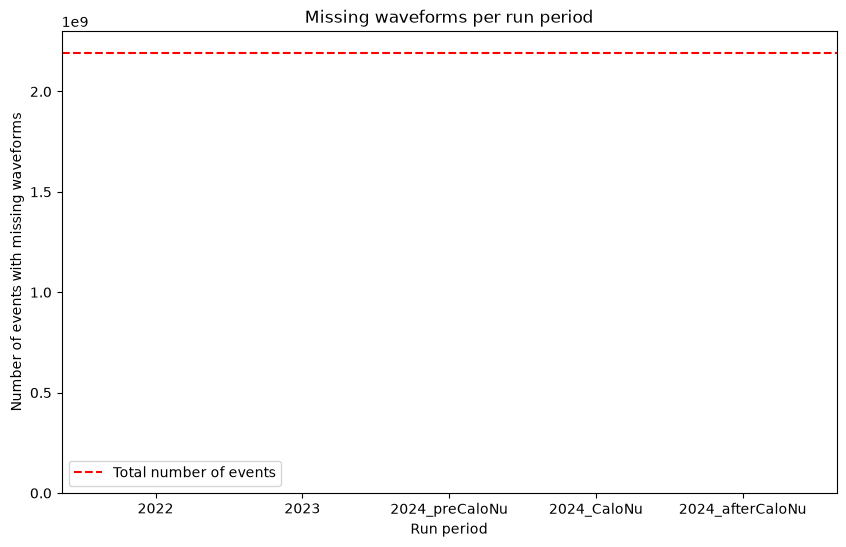

In [7]:
# plot missing waveforms per period
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(["2022", "2023", "2024_preCaloNu", "2024_CaloNu", "2024_afterCaloNu"],
       [n_2022_missing_waveforms, n_2023_missing_waveforms, n_2024_preCaloNu_missing_waveforms, n_2024_CaloNu_missing_waveforms, n_2024_afterCaloNu_missing_waveforms])
ax.axhline(y=total_number_of_events, color='r', linestyle='--', label='Total number of events')
ax.set_ylabel("Number of events with missing waveforms")
ax.set_xlabel("Run period")
ax.set_title("Missing waveforms per run period")
# ax.set_yscale("log")
# ax.set_ylim(1, total_number_of_events*10
ax.legend()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'Colliding'),
  Text(1, 0, 'Trigger'),
  Text(2, 0, 'Good times'),
  Text(3, 0, 'Excluded times'),
  Text(4, 0, 'At least one long track'),
  Text(5, 0, 'Sanity cut to remove events with missing aux data'),
  Text(6, 0, 'VetoNu0 reduced charge < 30 pC'),
  Text(7, 0, 'VetoNu1 reduced charge < 30 pC'),
  Text(8, 0, 'VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid)'),
  Text(9, 0, 'VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid)'),
  Text(10, 0, 'CaloNu status cleaning'),
  Text(11, 0, 'Veto20 and Veto21 charge > 40 pC'),
  Text(12, 0, 'Timing Station Charge > 20 pC'),
  Text(13, 0, 'Preshower Charge > 2.5 pC'),
  Text(14, 0, 'Track pz > 100 GeV'),
  Text(15, 0, 'Leading track has at >= 7 layers'),
  Text(16, 0, 'Track nDoF >= 9'),
  Text(17, 0, 'Leading track has chi2/ndof < 15'),
  Text(18, 0, 

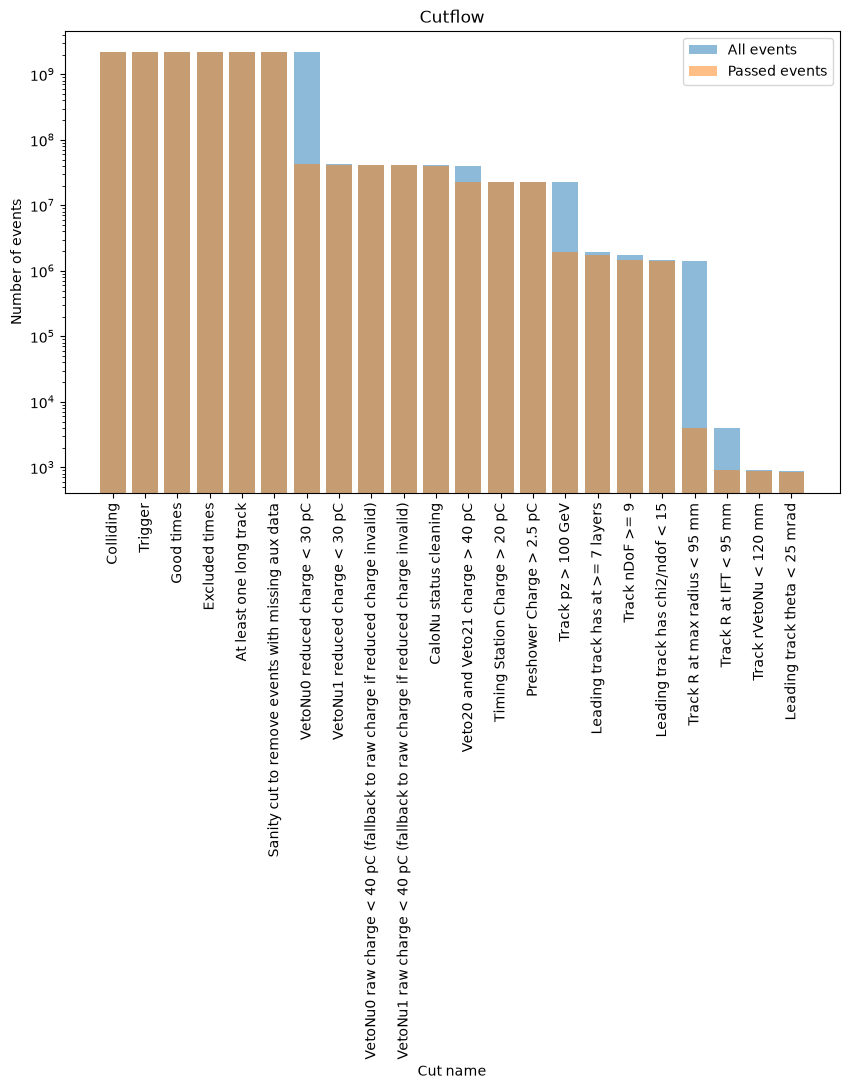

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cutflow.keys(), [cutflow[cut]["all"] for cut in cutflow.keys()], label="All events", alpha=0.5)
ax.bar(cutflow.keys(), [cutflow[cut]["passed"] for cut in cutflow.keys()], label="Passed events", alpha=0.5)
ax.set_yscale("log")
ax.set_ylabel("Number of events")
ax.set_xlabel("Cut name")
ax.set_title("Cutflow")
ax.legend()
plt.xticks(rotation=90)

In [9]:
for run in complete_runs:

    if int(run) > 1.2e4: # only print 2024 runs
        print(f"{run} has complete waveforms")

In [10]:
cutflow_df = pd.DataFrame(cutflow).T
cutflow_df["efficiency"] = cutflow_df["passed"] / cutflow_df["all"]
cutflow_df = cutflow_df.reset_index().rename(columns={"index": "cut_name"})
display(cutflow_df)

,cut_name,all,passed,efficiency
0,Colliding,2191332216,2181397182,0.995466
1,Trigger,2181397182,2181394300,0.999999
2,Good times,2181394300,2181394300,1.000000
3,Excluded times,2181394300,2179509794,0.999136
4,At least one long track,2179509794,2179509794,1.000000
5,Sanity cut to remove events with missing aux data,2179509794,2179509794,1.000000
6,VetoNu0 reduced charge < 30 pC,2179509794,42086368,0.019310
7,VetoNu1 reduced charge < 30 pC,42086368,40963335,0.973316
8,VetoNu0 raw charge < 40 pC (fallback to raw ch...,40963335,40818119,0.996455
9,VetoNu1 raw charge < 40 pC (fallback to raw ch...,40818119,40817945,0.999996


In [11]:
status_variables = [
    "VetoNu0_status", "VetoNu1_status", "Veto20_status", "Veto21_status", "Preshower0_status", "Preshower1_status"
]

df_list = []

for f in tqdm.tqdm(fpaths):
    run = int(os.path.basename(f).split(".")[0])
    if run not in good_runs:
        continue

    df = uproot.open(f)["nt"].arrays(library="pd", filter_name=status_variables+["run", "VetoNu0_raw_charge", "VetoNu1_raw_charge", "VetoNu0_reduced_charge", "VetoNu1_reduced_charge"])
    df_list.append(df)

df_my_full_data = pd.concat(df_list, ignore_index=True)

100%|██████████| 555/555 [01:09<00:00,  7.94it/s]


In [12]:
display(df_my_full_data)

,Preshower0_status,Preshower1_status,Veto20_status,Veto21_status,VetoNu0_raw_charge,VetoNu0_reduced_charge,VetoNu0_status,VetoNu1_raw_charge,VetoNu1_reduced_charge,VetoNu1_status,run
0,0,0,4,4,0.476265,0.000000,1,1.526050,0.000000,0,10956
1,0,0,0,0,6.978232,4.327383,0,1.374429,0.000000,0,10956
2,0,0,0,0,0.720483,0.155688,1,0.578896,0.174595,1,10956
3,0,0,0,0,0.626133,0.096641,1,0.493457,0.000000,1,10956
4,0,0,4,4,0.564209,0.145703,1,0.722690,0.314844,1,10956
...,...,...,...,...,...,...,...,...,...,...,...
843,0,0,516,516,0.621870,0.031597,1,2.160977,0.007266,0,16018
844,0,0,4,4,0.756499,0.104692,1,0.584282,0.108901,1,16018
845,0,0,0,0,0.587324,0.030078,1,0.391406,0.004248,1,16018
846,0,16,4,4,43.648117,5.225430,0,84.266846,27.698631,0,15269


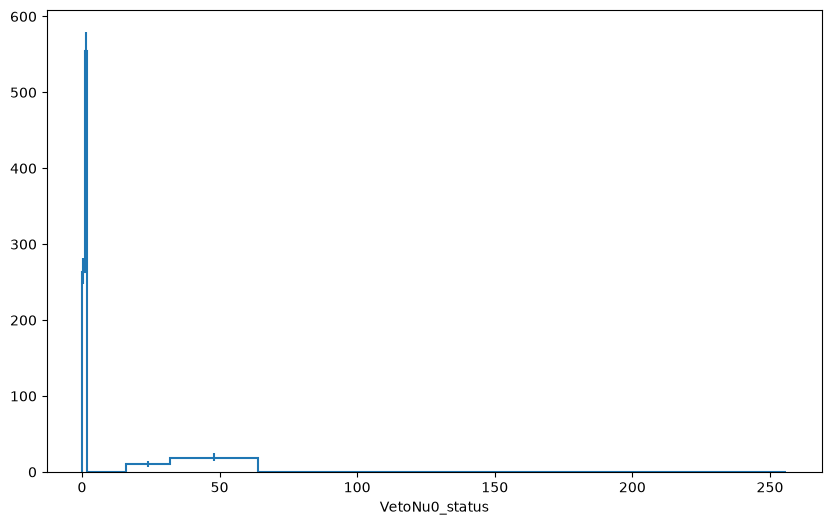

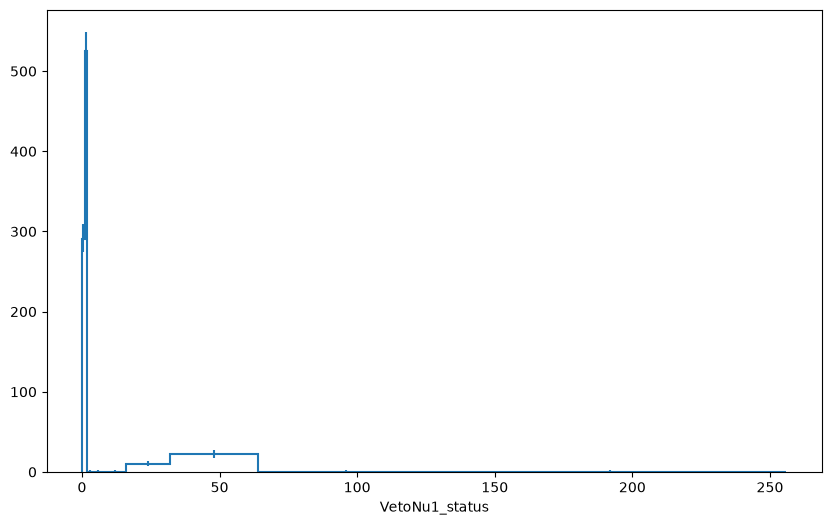

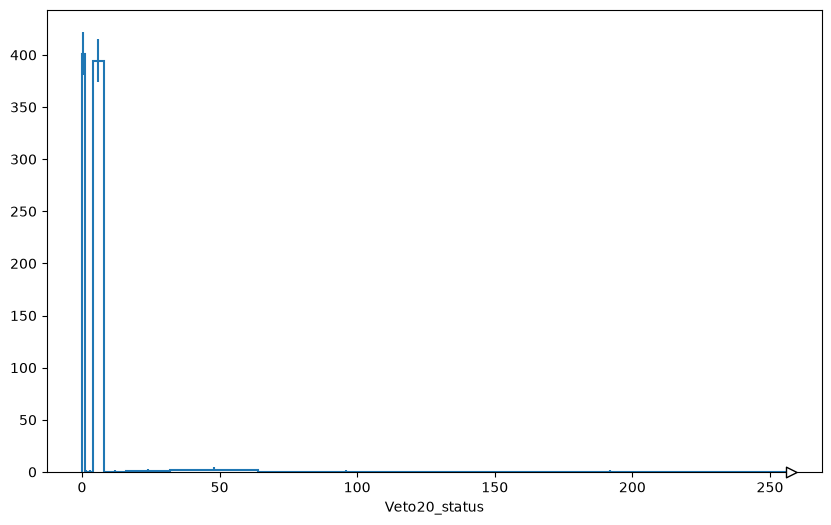

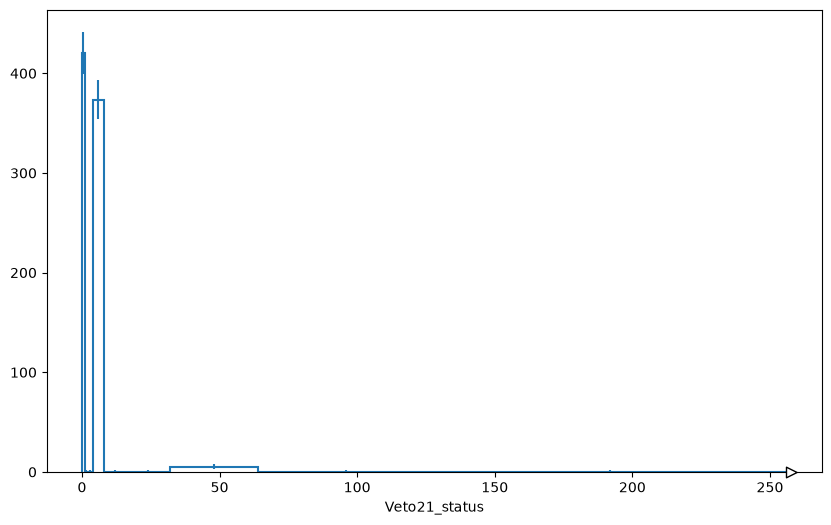

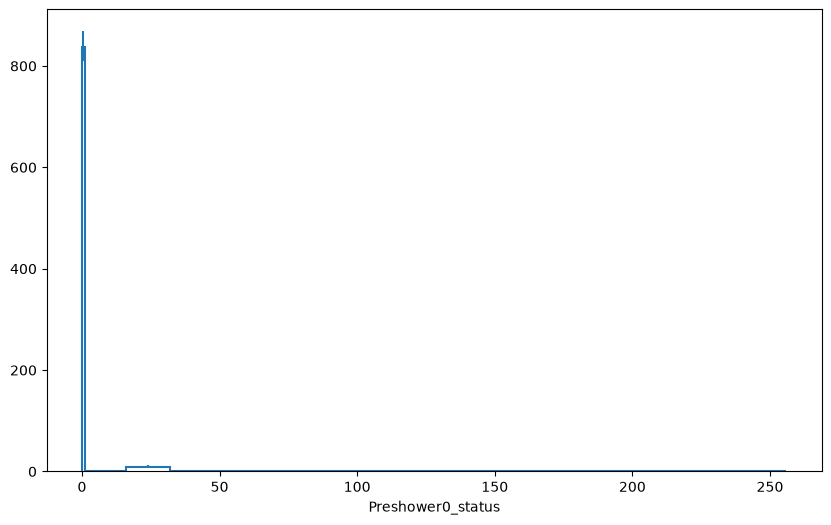

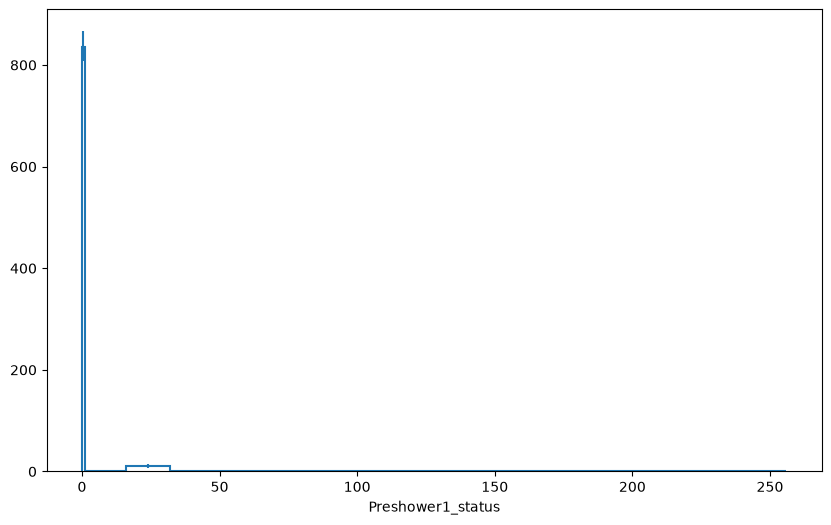

In [13]:
for v in status_variables:
    bins = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
    hist = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Int64())

    hist.fill(df_my_full_data[v])

    fig, ax = plt.subplots(figsize=(10, 6))
    mplhep.histplot(hist, ax=ax)
    ax.set_xlabel(f"{v}")


In [14]:
n_events_2022 = 0
n_events_2023 = 0
n_events_2024_preCaloNu = 0
n_events_2024_CaloNu = 0
n_events_2024_afterCaloNu = 0

my_runs_2022 = set()
my_runs_2023 = set()
my_runs_2024_preCaloNu = set()
my_runs_2024_CaloNu = set()
my_runs_2024_afterCaloNu = set()
my_runs_noCaloNu_2024 = set()

for run, yield_ in run_yields.items():
    if run < 1e4: # 2022
        n_events_2022 += yield_
        my_runs_2022.add(run)
    elif run < 1.2e4: # 2023
        n_events_2023 += yield_
        my_runs_2023.add(run)
    elif 15821 < run < 16924: # 2024_CaloNu
        n_events_2024_CaloNu += yield_
        my_runs_2024_CaloNu.add(run)
    elif run < 15821: # 2024_preCaloNu
        n_events_2024_preCaloNu += yield_
        my_runs_2024_preCaloNu.add(run)
        my_runs_noCaloNu_2024.add(run)
    elif run > 16924: # 2024_afterCaloNu
        n_events_2024_afterCaloNu += yield_
        my_runs_2024_afterCaloNu.add(run)
        my_runs_noCaloNu_2024.add(run)

print(f"2022 events: {n_events_2022}")
print(f"2023 events: {n_events_2023}")
print(f"2024_preCaloNu events: {n_events_2024_preCaloNu}")
print(f"2024_CaloNu events: {n_events_2024_CaloNu}")
print(f"2024_afterCaloNu events: {n_events_2024_afterCaloNu}")
print(f"Total 2024 no CaloNu events: {n_events_2024_preCaloNu + n_events_2024_afterCaloNu}")
print(f"Total 2024 events: {n_events_2024_preCaloNu + n_events_2024_CaloNu + n_events_2024_afterCaloNu}")
print(f"Total events: {n_events_2022 + n_events_2023 + n_events_2024_preCaloNu + n_events_2024_CaloNu + n_events_2024_afterCaloNu}")

# print(185 + 169 + 249 + 218)
print(f"Total number of runs in my list: {len(my_runs_2022) + len(my_runs_2023) + len(my_runs_noCaloNu_2024) + len(my_runs_2024_CaloNu)}")


2022 events: 190
2023 events: 174
2024_preCaloNu events: 210
2024_CaloNu events: 228
2024_afterCaloNu events: 46
Total 2024 no CaloNu events: 256
Total 2024 events: 484
Total events: 848
Total number of runs in my list: 305



Wissals numbers:
- 2022: 185
- 2023: 169
- 2024 No CaloNu: 249
- 2024 With CaloNu: 218 

Total: 821

My Numbers:
- 2022: 191
- 2023: 172
- 2024 No CaloNu: 255
- 2024 With CaloNu: 246

Total = 852

Difference: 31

In [15]:
wissals_2022_runs = [8025, 8115, 8120, 8124, 8155, 8157, 8175, 8179, 8182, 8190, 8191, 8248, 8252, 8266, 8269, 8290, 8294, 8301, 8320, 8326, 8327, 8330, 8331, 8332, 8333, 8336, 8728, 8731, 8733, 8736, 8775, 8777, 8798, 8799, 8834, 8841, 8848, 8850, 8906, 8908, 8913, 8915, 8916, 8917, 8930, 8933, 8934, 8943, 8945, 8947, 8948, 8949, 8950, 8970, 8972, 8975, 8977, 8981, 8985, 8987, 9058, 9060, 9069, 9072, 9073, 9092, 9094, 9148, 9166, 9181, 9183, 9188]
wissals_2023_runs = [10604, 10605, 10615, 10694, 10695, 10699, 10700, 10701, 10729, 10732, 10733, 10738, 10775, 10792, 10794, 10796, 10829, 10847, 10849, 10857, 10859, 10881, 10921, 10928, 10955, 10956, 11041, 11070, 11081, 11082, 11086, 11088, 11089, 11093, 11096, 11098, 11127, 11156, 11208, 11211, 11212, 11213, 11243, 11523, 11527, 11528, 11583, 11584, 11585, 11586, 11589, 11590, 11595, 11597, 11613, 11700, 11703]
wissals_2024_noCaloNu_runs = [14743, 14758, 14760, 14767, 14769, 14771, 14777, 14797, 14799, 14804, 14809, 14810, 14906, 14954, 14971, 14972, 14974, 14975, 14977, 14980, 14981, 14985, 15007, 15015, 15016, 15024, 15025, 15031, 15032, 15034, 15050, 15051, 15052, 15055, 15059, 15269, 15270, 15287, 15290, 15387, 15388, 15390, 15391, 15394, 15398, 15415, 15422, 15425, 15429, 15432, 15434, 15438, 15439, 15445, 15446, 15683, 15685, 15687, 15751, 15754, 15755, 15758, 15762, 15763, 15766, 15784, 15785, 15786, 15787, 15789, 15790, 15814, 15818, 15820, 16800, 16929, 16930, 16931, 16934, 16937, 16938, 16940, 16941, 16943, 16974, 17018, 17023, 17095, 17102, 17147, 17199, 17230]
wissals_2024_CaloNu_runs = [15838, 15839, 15844, 15874, 15877, 15878, 15883, 15884, 15903, 15909, 15912, 15913, 15915, 15917, 15918, 15919, 15945, 15946, 15948, 15949, 15951, 15953, 15956, 15957, 15961, 15963, 15967, 15977, 15996, 15998, 16000, 16001, 16018, 16022, 16023, 16028, 16042, 16043, 16057, 16064, 16065, 16068, 16072, 16075, 16076, 16077, 16096, 16098, 16099, 16103, 16393, 16396, 16400, 16403, 16405, 16517, 16531, 16533, 16542, 16558, 16581, 16628, 16635, 16650, 16653, 16658, 16660, 16661, 16663, 16667, 16685, 16696, 16697, 16699, 16715, 16731, 16732, 16798, 16802, 16805, 16848, 16853, 16916, 16923]

diff_2022 = set(wissals_2022_runs) - my_runs_2022
diff_2023 = set(wissals_2023_runs) - my_runs_2023
diff_2024_noCaloNu = set(wissals_2024_noCaloNu_runs) - my_runs_noCaloNu_2024
diff_2024_CaloNu = set(wissals_2024_CaloNu_runs) - my_runs_2024_CaloNu

print(f"2022 runs in wissals list but not in my list: {diff_2022}")
print(f"2023 runs in wissals list but not in my list: {diff_2023}")
print(f"2024_noCaloNu runs in wissals list but not in my list: {diff_2024_noCaloNu}")
print(f"2024_CaloNu runs in wissals list but not in my list: {diff_2024_CaloNu}")


2022 runs in wissals list but not in my list: set()
2023 runs in wissals list but not in my list: set()
2024_noCaloNu runs in wissals list but not in my list: {16800}
2024_CaloNu runs in wissals list but not in my list: set()


In [16]:
print(max(good_runs))

17230


In [17]:
diff_2022 = my_runs_2022 - set(wissals_2022_runs)
diff_2023 = my_runs_2023 - set(wissals_2023_runs)
diff_2024_preCaloNu = my_runs_noCaloNu_2024 - set(wissals_2024_noCaloNu_runs)
diff_2024_CaloNu = my_runs_2024_CaloNu - set(wissals_2024_CaloNu_runs)

print(f"2022 runs in my list but not in wissals list: {diff_2022}")
print(f"2023 runs in my list but not in wissals list: {diff_2023}")
print(f"2024_preCaloNu runs in my list but not in wissals list: {diff_2024_preCaloNu}")
print(f"2024_CaloNu runs in my list but not in wissals list: {diff_2024_CaloNu}")

2022 runs in my list but not in wissals list: set()
2023 runs in my list but not in wissals list: set()
2024_preCaloNu runs in my list but not in wissals list: set()
2024_CaloNu runs in my list but not in wissals list: {16800}


In [18]:
print(f"Yield for run  16800 (2024_noCaloNu): {run_yields[16800]}")


Yield for run  16800 (2024_noCaloNu): 3


In [19]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]
runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [20]:
nevents_miss_2022 = 0
nevents_miss_2023 = 0
nevents_miss_2024_preCaloNu = 0
nevents_miss_2024_CaloNu = 0
nevents_miss_2024_afterCaloNu = 0

In [21]:
wissals_2022_data = pd.read_parquet("unblinded_data/2022_unblinded.parq")
wissals_2023_data = pd.read_parquet("unblinded_data/2023_unblinded.parq")
wissals_2024_noCaloNu_data = pd.read_parquet("unblinded_data/2024_woCaloNu_unblinded_NOSTATUS.parq")
wissals_2024_CaloNu_data = pd.read_parquet("unblinded_data/caloNu_unblinded_NOSTATUS.parq")

wissals_run_yields = {}

for run in wissals_2022_runs:
    yield_ = wissals_2022_data[wissals_2022_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

for run in wissals_2023_runs:
    yield_ = wissals_2023_data[wissals_2023_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

for run in wissals_2024_noCaloNu_runs:
    yield_ = wissals_2024_noCaloNu_data[wissals_2024_noCaloNu_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

for run in wissals_2024_CaloNu_runs:
    yield_ = wissals_2024_CaloNu_data[wissals_2024_CaloNu_data["run"] == run].shape[0]
    wissals_run_yields[run] = yield_

n_runs_with_different_yields = 0
n_runs_with_same_yields = 0

n_events_wissal_has_but_i_dont = 0
n_events_i_have_but_wissal_doesnt = 0

for run, yield_ in wissals_run_yields.items():
    if run not in run_yields:
        print(f"Run {run} is in wissals list but not in my list, yield: {yield_}")
    else:
        my_yield = run_yields[run]
        if my_yield != yield_:
            n_runs_with_different_yields += 1

            if my_yield > yield_:
                n_events_i_have_but_wissal_doesnt += my_yield - yield_
                print(f"Run {run} has different yields: my yield {my_yield}, wissals yield {yield_} - I have {my_yield - yield_} more events than wissal")

                if runs_2022[0] <= run <= runs_2022[1]:
                    nevents_miss_2022 += my_yield - yield_
                elif runs_2023[0] <= run <= runs_2023[1]:
                    nevents_miss_2023 += my_yield - yield_
                elif runs_2024_preCaloNu[0] <= run <= runs_2024_preCaloNu[1]:
                    nevents_miss_2024_preCaloNu += my_yield - yield_
                elif runs_2024_CaloNu[0] <= run <= runs_2024_CaloNu[1]:
                    nevents_miss_2024_CaloNu += my_yield - yield_
                elif runs_2024_afterCaloNu[0] <= run <= runs_2024_afterCaloNu[1]:
                    nevents_miss_2024_afterCaloNu += my_yield - yield_


            if yield_ > my_yield:
                n_events_wissal_has_but_i_dont += yield_ - my_yield
                print(f"Run {run} has different yields: my yield {my_yield}, wissals yield {yield_} - Wissal has {yield_ - my_yield} more events than me")
        elif my_yield == yield_ == 0:
            print(f"Run {run} has zero yields in both lists")
        else:
            n_runs_with_same_yields += 1

print(f"Number of runs with different yields: {n_runs_with_different_yields}")
print(f"Number of runs with same yields: {n_runs_with_same_yields}")
print(f"Number of events wissal has but I don't: {n_events_wissal_has_but_i_dont}")
print(f"Number of events I have but wissal doesn't: {n_events_i_have_but_wissal_doesnt}")
print(f"Number of events I have but wissal doesn't in 2022: {nevents_miss_2022}")
print(f"Number of events I have but wissal doesn't in 2023: {nevents_miss_2023}")
print(f"Number of events I have but wissal doesn't in 2024_preCaloNu: {nevents_miss_2024_preCaloNu}")
print(f"Number of events I have but wissal doesn't in 2024_CaloNu: {nevents_miss_2024_CaloNu}")
print(f"Number of events I have but wissal doesn't in 2024_afterCaloNu: {nevents_miss_2024_afterCaloNu}")

Run 8266 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8916 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8948 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8975 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 8981 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 10955 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 11211 has different yields: my yield 5, wissals yield 4 - I have 1 more events than wissal
Run 11585 has different yields: my yield 6, wissals yield 5 - I have 1 more events than wissal
Run 11586 has different yields: my yield 3, wissals yield 2 - I have 1 more events than wissal
Run 11613 has different yields: my yield 7, wissals yield 6 - I have 1 more events than wissal
Run 14981 has different yields: my yield 4, wissals yie

In [22]:
df_wissals_data = pd.concat([wissals_2022_data, wissals_2023_data, wissals_2024_noCaloNu_data, wissals_2024_CaloNu_data])
my_data = uproot.concatenate([f"{f}:nt" for f in fpaths], library="pd",filter_name=["run", "eventID"])

my_data = my_data[my_data["run"].isin(good_runs)]

In [23]:
run_15844_cutflow_df = uproot.open("AnalysisZipFramework/submission/analysis_output/15844.root")["cutflow"].arrays(library="pd")
display(run_15844_cutflow_df)


,cut_name,all,passed,efficiency
0,Colliding,4112464,4085316,99.339859
1,Trigger,4085316,4085310,99.999847
2,Good times,4085310,4085310,100.000000
3,Excluded times,4085310,4085310,100.000000
4,Sanity cut to remove events with missing aux data,4085310,4085310,100.000000
5,VetoNu0 reduced charge < 30 pC,4085310,75556,1.849456
6,VetoNu1 reduced charge < 30 pC,75556,73774,97.641487
7,VetoNu0 raw charge < 40 pC (fallback to raw ch...,73774,73443,99.551331
8,VetoNu1 raw charge < 40 pC (fallback to raw ch...,73443,73442,99.998642
9,CaloNu status cleaning,73442,71850,97.832306


In [24]:
my_events = set(my_data["eventID"])
wissals_events = set(df_wissals_data["eventID"])

In [25]:
print(len(my_data["eventID"]))
print(len(df_wissals_data["eventID"]))

848
815


In [26]:
diff_events_i_have_but_wissal_doesnt = my_events - wissals_events
diff_events_wissal_has_but_i_dont = wissals_events - my_events

In [27]:
print(f"Number of events in my data: {len(my_events)}")
print(f"Number of events in wissals data: {len(wissals_events)}")
print(f"Number of events I have but wissal doesn't: {len(diff_events_i_have_but_wissal_doesnt)}")
print(f"Number of events wissal has but I don't: {len(diff_events_wissal_has_but_i_dont)}")

Number of events in my data: 848
Number of events in wissals data: 815
Number of events I have but wissal doesn't: 34
Number of events wissal has but I don't: 1


In [28]:
for i, event in enumerate(diff_events_i_have_but_wissal_doesnt):
    print(f"{i+1}/{len(diff_events_i_have_but_wissal_doesnt)} Event {event} in run {my_data[my_data['eventID'] == event]['run'].iloc[0]} is in my data but not in wissals data")

1/34 Event 4075266 in run 8916 is in my data but not in wissals data
2/34 Event 3189382 in run 16696 is in my data but not in wissals data
3/34 Event 7006730 in run 10955 is in my data but not in wissals data
4/34 Event 41360274 in run 16103 is in my data but not in wissals data
5/34 Event 63916307 in run 14981 is in my data but not in wissals data
6/34 Event 933273 in run 15839 is in my data but not in wissals data
7/34 Event 46293663 in run 11613 is in my data but not in wissals data
8/34 Event 39728933 in run 16635 is in my data but not in wissals data
9/34 Event 42487717 in run 15445 is in my data but not in wissals data
10/34 Event 67660075 in run 15055 is in my data but not in wissals data
11/34 Event 9102891 in run 15948 is in my data but not in wissals data
12/34 Event 32632619 in run 8981 is in my data but not in wissals data
13/34 Event 5418799 in run 11211 is in my data but not in wissals data
14/34 Event 53631539 in run 15685 is in my data but not in wissals data
15/34 Even

In [29]:
run_event_list = []
for i, event in enumerate(diff_events_wissal_has_but_i_dont):
    print(f"{i+1}/{len(diff_events_wissal_has_but_i_dont)} Event {event:.0f} in run {df_wissals_data[df_wissals_data['eventID'] == event]['run'].iloc[0]:.0f} is in wissals data but not in my data")
    run_event_list.append((df_wissals_data[df_wissals_data['eventID'] == event]['run'].iloc[0], event))

1/1 Event 12407980 in run 15838 is in wissals data but not in my data


In [30]:
for run, event in run_event_list:

    if not os.path.exists(f"build/{run:.0f}.root"): continue

    run_data = uproot.open(f"build/{run:.0f}.root")

    if "eventID_pass" not in run_data: continue

    print(f"Run {run:.0f} has event {event:.0f} in wissals data but not in my data")

    my_num_events = np.amin(run_data["cutflow"].arrays(library="pd")["passed"])
    wissals_num_events = df_wissals_data[df_wissals_data["run"] == run].shape[0]

    print(f"Run {run:.0f} has {my_num_events} events in my data and {wissals_num_events} events in wissals data")

    cut_pass = run_data["eventID_pass"].arrays(library="pd")
    event_data = cut_pass[cut_pass["eventID"] == event]

    for col in event_data.columns:
        if event_data[col].iloc[0] == 1:
            print(f"Event {event:.0f} in run {run:.0f} passed cut {col}")
        elif event_data[col].iloc[0] == 0:
            print(f"Event {event:.0f} in run {run:.0f} failed cut {col}")

    display(event_data)

In [31]:
for k in df_wissals_data.keys():
    print(f"{k}: {df_wissals_data[k].dtype}, {df_wissals_data[k].shape[0]} entries")

Track_Chi2: float64, 815 entries
Track_ThetaX_atVetoNu: float64, 815 entries
Track_ThetaX_atVetoStation2: float64, 815 entries
Track_ThetaY_atVetoNu: float64, 815 entries
Track_ThetaY_atVetoStation2: float64, 815 entries
Track_X_atTrig: float64, 815 entries
Track_X_atVetoNu: float64, 815 entries
Track_X_atVetoStation2: float64, 815 entries
Track_Y_atTrig: float64, 815 entries
Track_Y_atVetoNu: float64, 815 entries
Track_Y_atVetoStation2: float64, 815 entries
Track_charge: float64, 815 entries
Track_nDoF: float64, 815 entries
Track_nLayers: float64, 815 entries
Track_p0: float64, 815 entries
Track_p1: float64, 815 entries
Track_px0: float64, 815 entries
Track_px1: float64, 815 entries
Track_py0: float64, 815 entries
Track_py1: float64, 815 entries
Track_pz0: float64, 815 entries
Track_pz1: float64, 815 entries
Track_r_atMaxRadius: float64, 815 entries
Track_x0: float64, 815 entries
Track_x1: float64, 815 entries
Track_y0: float64, 815 entries
Track_y1: float64, 815 entries
Track_z0: flo

In [32]:
variable_names = [
    "VetoNu0_reduced_charge",
    "VetoNu1_reduced_charge",
    "Veto20_charge",
    "Veto21_charge",
    "Timing_charge_top",
    "Timing_charge_bottom",
    "Preshower0_charge",
    "Preshower1_charge",
    "longTracks",
    "LeadTrack_nLayers",
    "LeadTrack_nDoF",
    "LeadTrack_Chi2",
    "LeadTrack_pz0",
    "LeadTrack_r_atMaxRadius",
    "LeadTrack_rIFT",
    "LeadTrack_rVetoNu",
    "LeadTrack_Theta",
    "run",
    "eventID",
    "fallbackVetoNu0Charge",
    "fallbackVetoNu0Charge",
   "Calo0_baseline",
"Calo0_baseline_rms",
"Calo1_baseline",
"Calo1_baseline_rms",
"Calo2_baseline",
"Calo2_baseline_rms",
"Calo3_baseline",
"Calo3_baseline_rms",
"CaloNu0_baseline",
"CaloNu0_baseline_rms",
"CaloNu1_baseline",
"CaloNu1_baseline_rms",
"CaloNu2_baseline",
"CaloNu2_baseline_rms",
"CaloNu3_baseline",
"CaloNu3_baseline_rms",
"Preshower0_baseline",
"Preshower0_baseline_rms",
"Preshower1_baseline",
"Preshower1_baseline_rms",
"Timing0_baseline",
"Timing0_baseline_rms",
"Timing1_baseline",
"Timing1_baseline_rms",
"Timing2_baseline",
"Timing2_baseline_rms",
"Timing3_baseline",
"Timing3_baseline_rms",
"Veto10_baseline",
"Veto10_baseline_rms",
"Veto20_baseline",
"Veto20_baseline_rms",
"Veto21_baseline",
"Veto21_baseline_rms",
"VetoNu0_baseline",
"VetoNu0_baseline_rms",
"VetoNu1_baseline",
"VetoNu1_baseline_rms",
]

variable_name_in_wissals_data = [
    "reduced_VetoNu0_charge",
    "reduced_VetoNu1_charge",
    "VetoSt20_charge",
    "VetoSt21_charge",
    "Timing_charge_top",
    "Timing_charge_bottom",
    "Preshower0_charge",
    "Preshower1_charge",
    "longTracks",
    "Track_nLayers",
    "Track_nDoF",
    "Track_Chi2",
    "Track_pz_gev",
    "Track_r_atMaxRadius",
    "Track_rIFT",
    "Track_rVetoNu",
    "theta",
    "run",
    "eventID",
    "reduced_VetoNu0_charge",
    "reduced_VetoNu1_charge",
  "Calo0_baseline",
"Calo0_baseline_rms",
"Calo1_baseline",
"Calo1_baseline_rms",
"Calo2_baseline",
"Calo2_baseline_rms",
"Calo3_baseline",
"Calo3_baseline_rms",
"CaloNu0_baseline",
"CaloNu0_baseline_rms",
"CaloNu1_baseline",
"CaloNu1_baseline_rms",
"CaloNu2_baseline",
"CaloNu2_baseline_rms",
"CaloNu3_baseline",
"CaloNu3_baseline_rms",
"Preshower0_baseline",
"Preshower0_baseline_rms",
"Preshower1_baseline",
"Preshower1_baseline_rms",
"Timing0_baseline",
"Timing0_baseline_rms",
"Timing1_baseline",
"Timing1_baseline_rms",
"Timing2_baseline",
"Timing2_baseline_rms",
"Timing3_baseline",
"Timing3_baseline_rms",
"Veto10_baseline",
"Veto10_baseline_rms",
"Veto20_baseline",
"Veto20_baseline_rms",
"Veto21_baseline",
"Veto21_baseline_rms",
"VetoNu0_baseline",
"VetoNu0_baseline_rms",
"VetoNu1_baseline",
"VetoNu1_baseline_rms",
]

In [33]:
# my_full_data = uproot.concatenate([f"{f}:nt" for f in fpaths], library="ak", filter_name=variable_names)

df_list = []

for f in tqdm.tqdm(fpaths):
    run = int(os.path.basename(f).split(".")[0])
    if run not in good_runs:
        continue

    df = uproot.open(f)["nt"].arrays(library="pd", filter_name=variable_names)
    df_list.append(df)

df_my_full_data = pd.concat(df_list, ignore_index=True)
    

  0%|          | 0/555 [00:00<?, ?it/s]

100%|██████████| 555/555 [01:13<00:00,  7.59it/s]


In [34]:
df_my_full_data

,Calo0_baseline,Calo0_baseline_rms,Calo1_baseline,Calo1_baseline_rms,Calo2_baseline,Calo2_baseline_rms,Calo3_baseline,Calo3_baseline_rms,LeadTrack_Chi2,LeadTrack_Theta,...,longTracks,run,CaloNu0_baseline,CaloNu0_baseline_rms,CaloNu1_baseline,CaloNu1_baseline_rms,CaloNu2_baseline,CaloNu2_baseline_rms,CaloNu3_baseline,CaloNu3_baseline_rms
0,1921.150879,0.338250,1917.417969,0.472960,1901.155273,0.295506,1900.323608,0.318462,11.542088,11.109666,...,1,10956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1920.968994,0.321361,1917.280884,0.532008,1901.285767,0.361293,1900.340088,0.464183,10.462689,3.844690,...,1,10956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1921.051270,0.332510,1917.433472,0.499870,1901.242310,0.416563,1900.259399,0.369072,14.299299,10.002620,...,1,10956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1921.106201,0.368908,1917.420654,0.398458,1901.155518,0.354884,1900.536133,0.358997,7.284149,1.588221,...,1,10956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1920.862915,0.353077,1917.296143,0.633027,1901.137695,0.490047,1900.470825,0.416943,20.102646,0.421739,...,1,10956,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.611604,11.415446,...,1,16018,1914.456177,0.275487,1899.822144,0.429396,1907.407349,0.324509,1913.200928,0.360474
844,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.397497,8.415004,...,1,16018,1914.394531,0.274354,1899.689209,0.300059,1907.386230,0.342450,1913.254150,0.360512
845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.024605,3.790658,...,1,16018,1914.341187,0.269070,1899.843750,0.386156,1907.350952,0.373980,1913.320190,0.272108
846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.627686,14.192405,...,1,15269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_1061926/1441961001.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = my_hist.view() / her_hist.view()
/tmp/ipykernel_1061926/1441961001.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = my_hist.view() / her_hist.view()
/tmp/ipykernel_1061926/1441961001.py:33: RuntimeWarning: divide by zero encountered in divide
  ratio = my_hist.view() / her_hist.view()
/tmp/ipykernel_1061926/1441961001.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = my_hist.view() / her_hist.view()
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/_utils.py:1011: RuntimeWarning: invalid value encountered in subtract
  return values - np.sqrt(variances), values + np.sqrt(variances)
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/_utils.py:1014: RuntimeWarning: invalid value encountered in subtract
  return np.abs(method_fcn(self.values(), variances) - self.values())
/tmp/ipykernel_1061926/14

Variable Calo0_baseline not found in my data or wissals data: 'Calo0_baseline'
Variable Calo0_baseline_rms not found in my data or wissals data: 'Calo0_baseline_rms'
Variable Calo1_baseline not found in my data or wissals data: 'Calo1_baseline'
Variable Calo1_baseline_rms not found in my data or wissals data: 'Calo1_baseline_rms'
Variable Calo2_baseline not found in my data or wissals data: 'Calo2_baseline'
Variable Calo2_baseline_rms not found in my data or wissals data: 'Calo2_baseline_rms'
Variable Calo3_baseline not found in my data or wissals data: 'Calo3_baseline'
Variable Calo3_baseline_rms not found in my data or wissals data: 'Calo3_baseline_rms'
Variable CaloNu0_baseline not found in my data or wissals data: 'CaloNu0_baseline'
Variable CaloNu0_baseline_rms not found in my data or wissals data: 'CaloNu0_baseline_rms'
Variable CaloNu1_baseline not found in my data or wissals data: 'CaloNu1_baseline'
Variable CaloNu1_baseline_rms not found in my data or wissals data: 'CaloNu1_ba

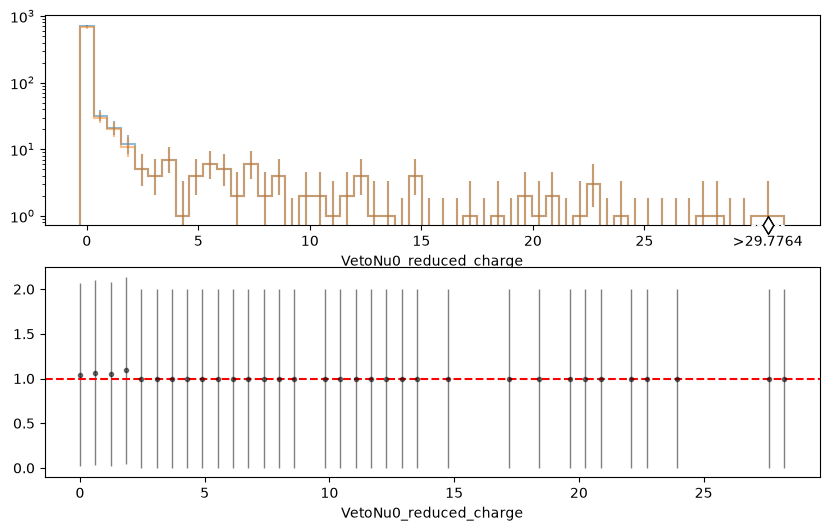

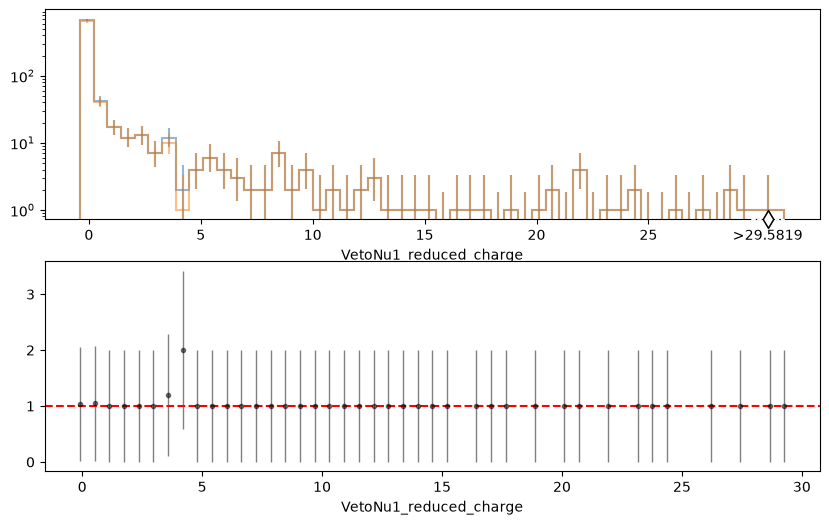

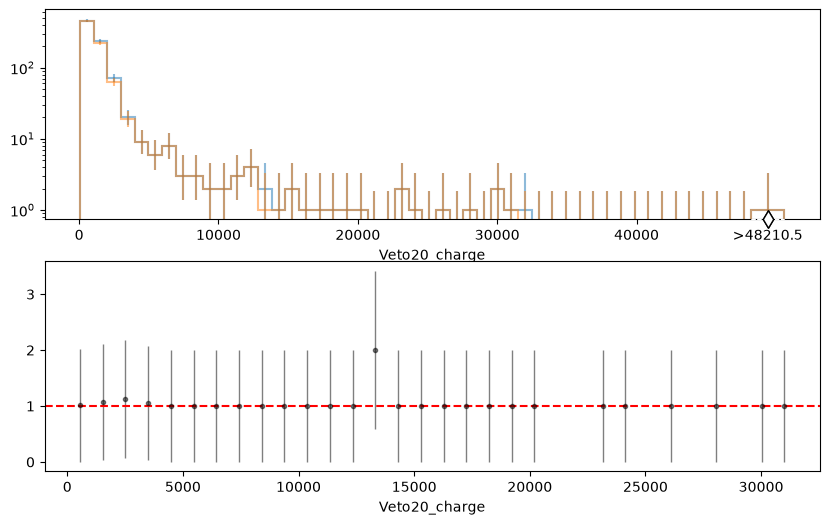

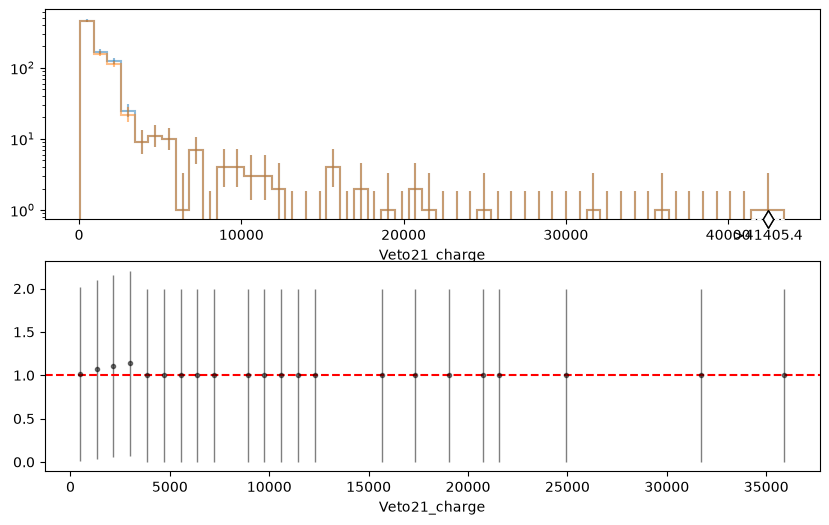

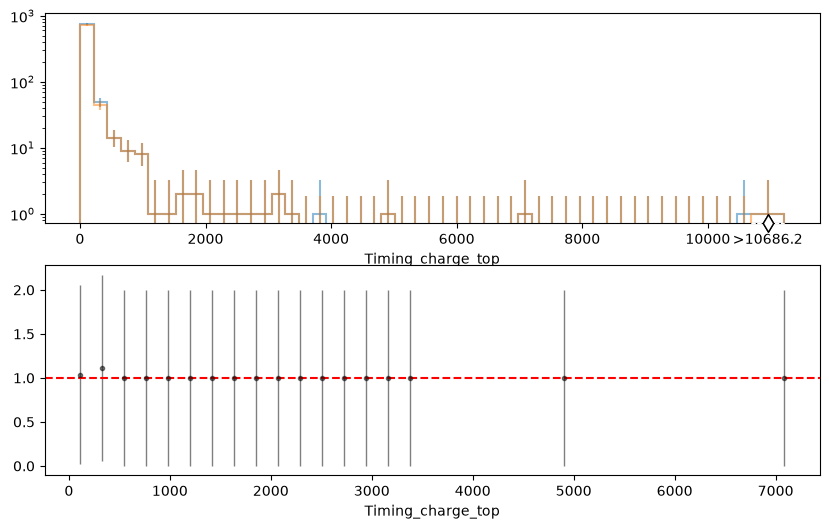

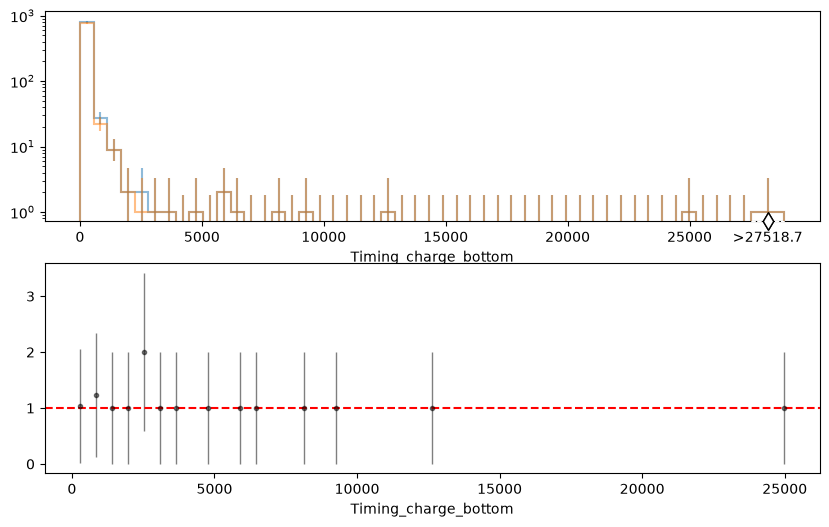

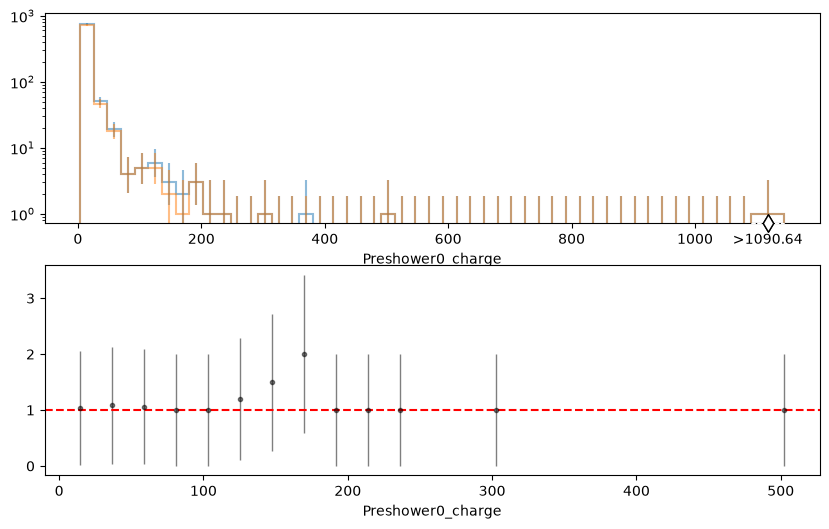

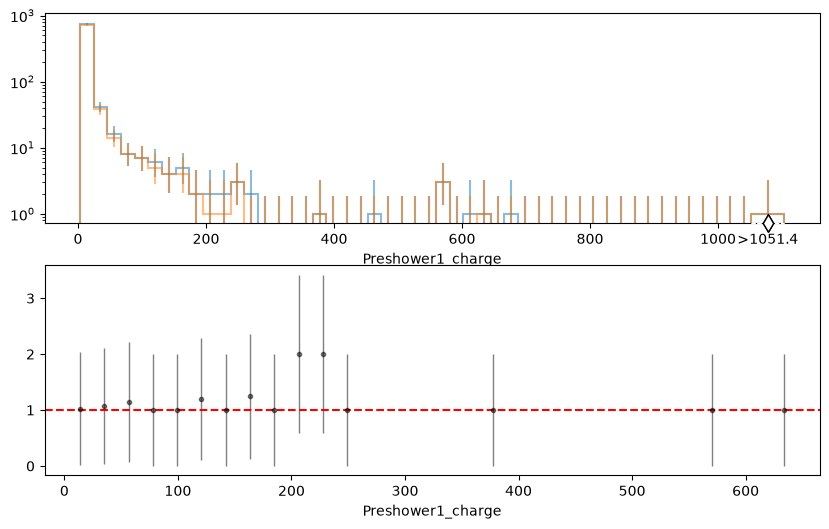

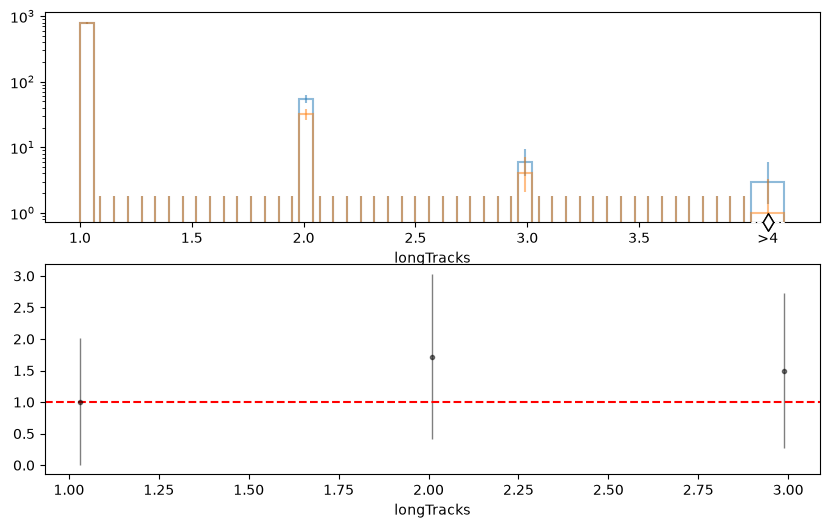

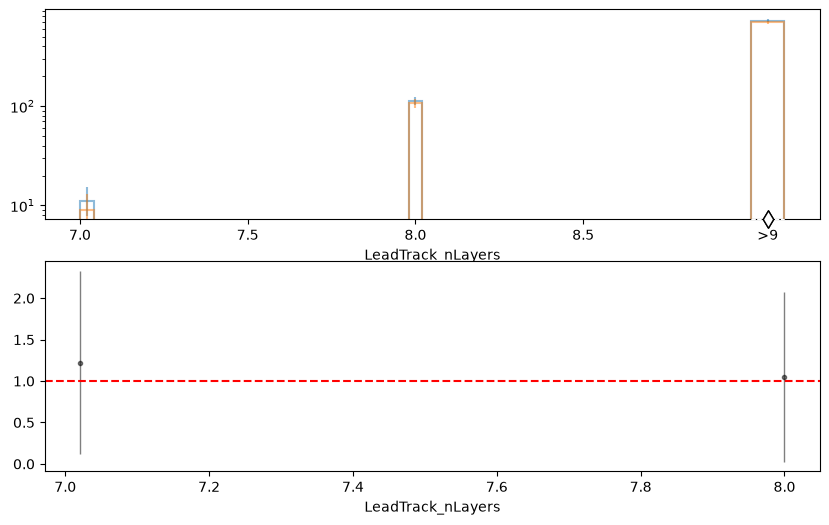

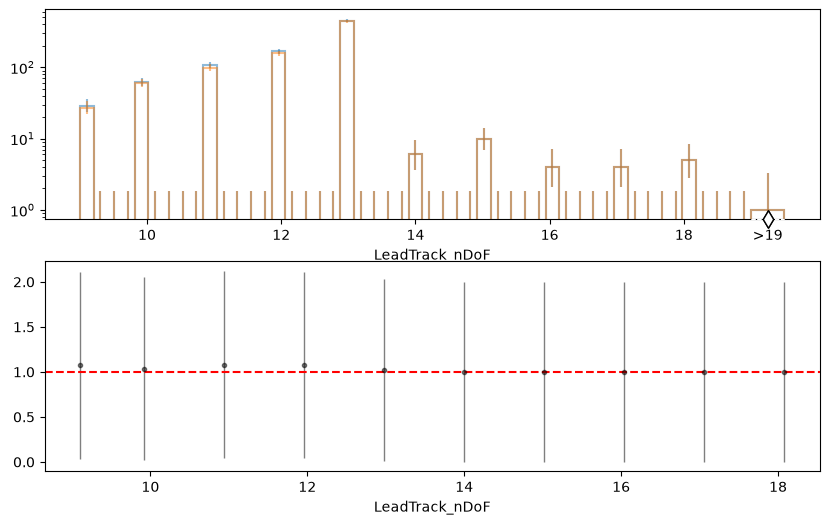

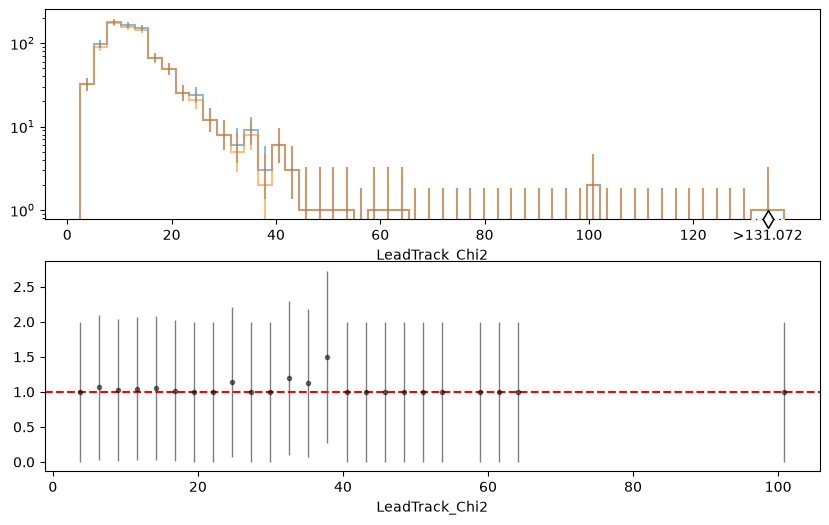

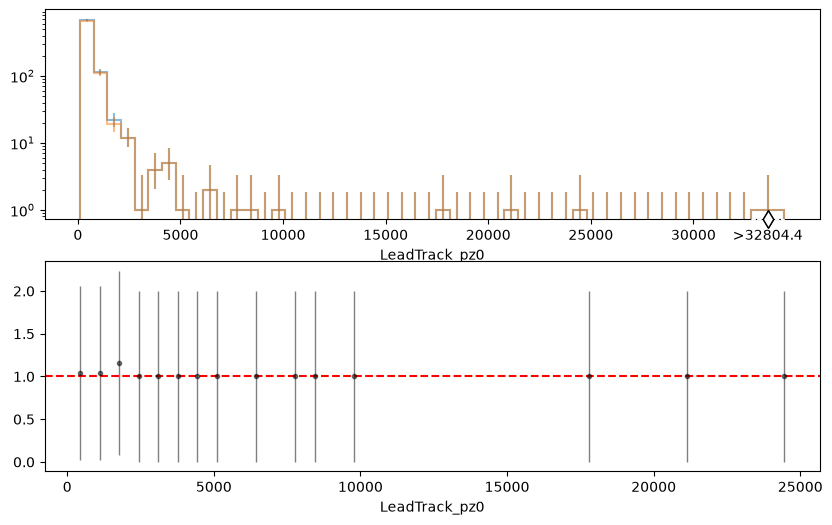

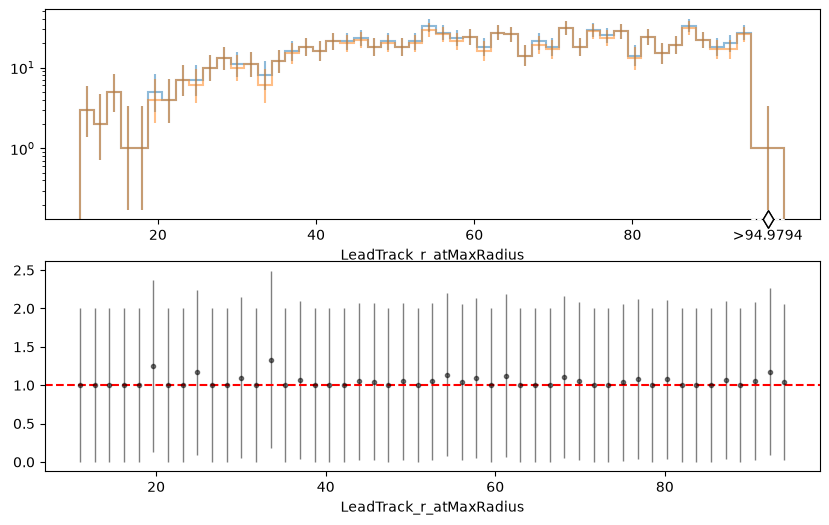

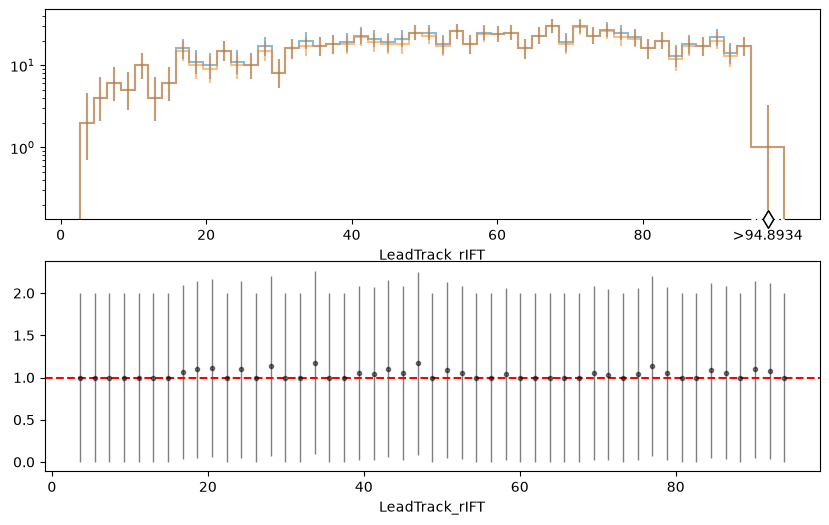

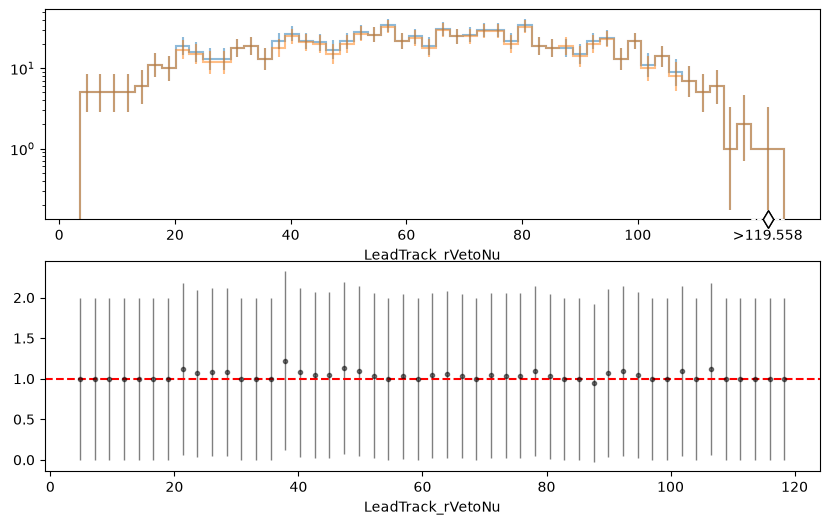

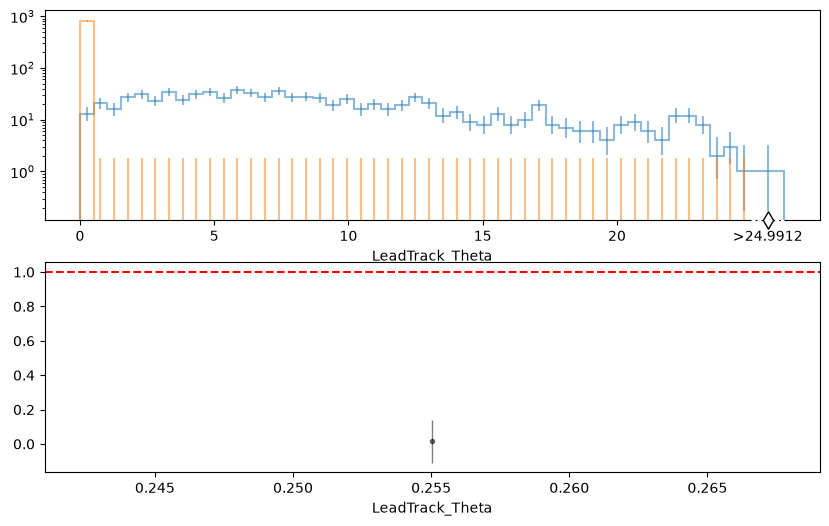

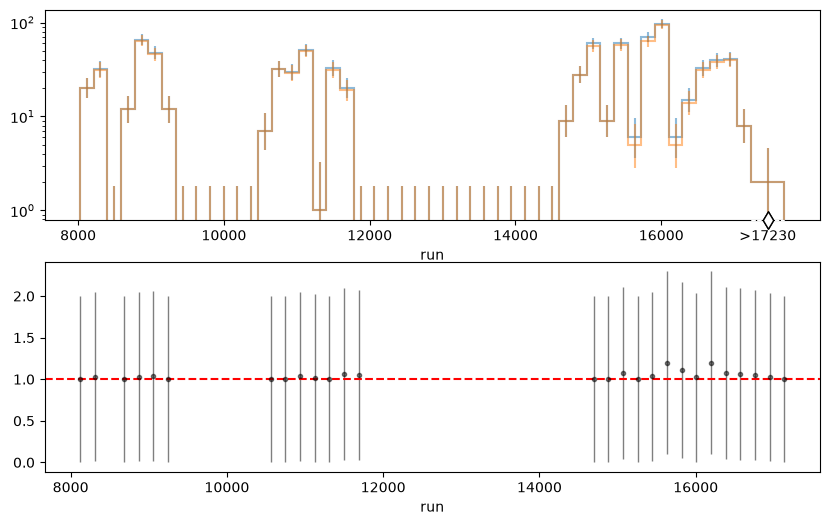

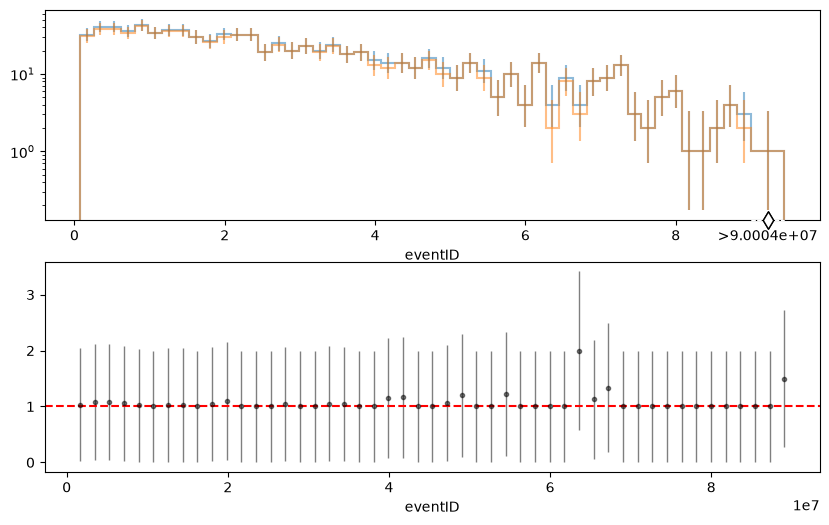

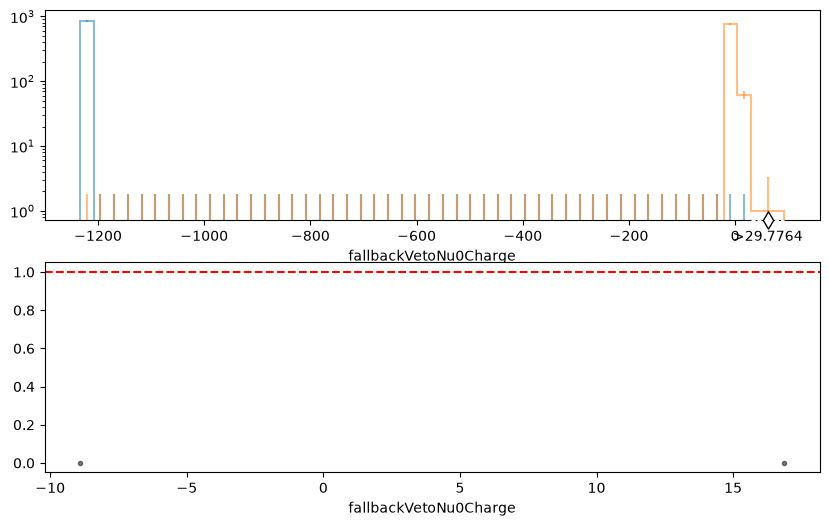

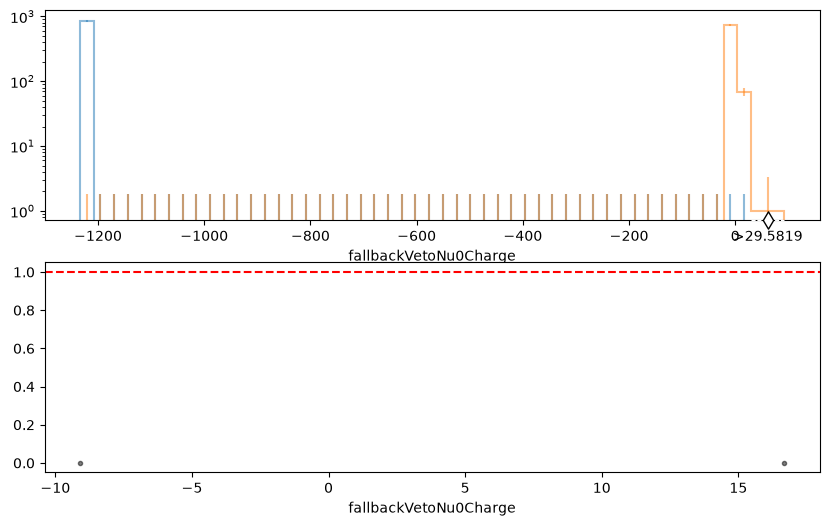

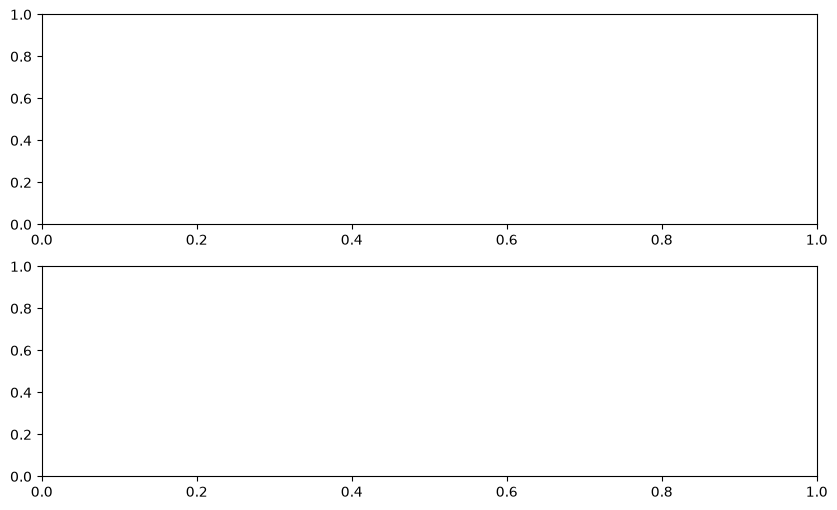

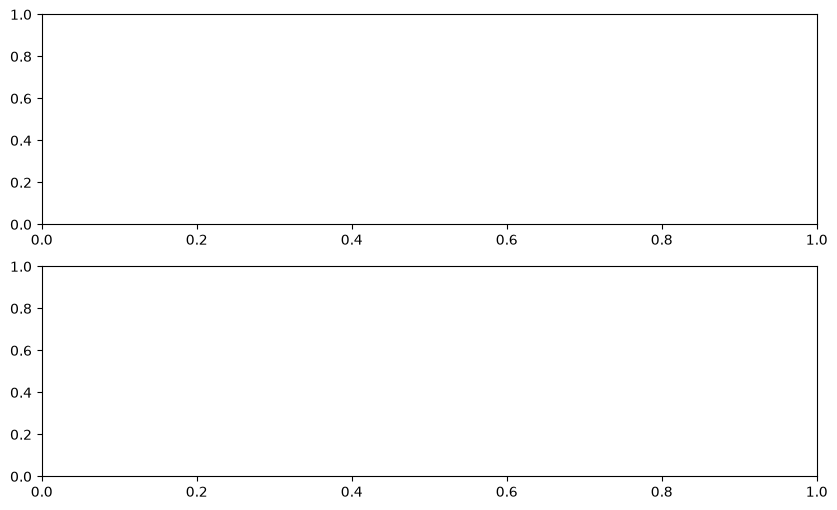

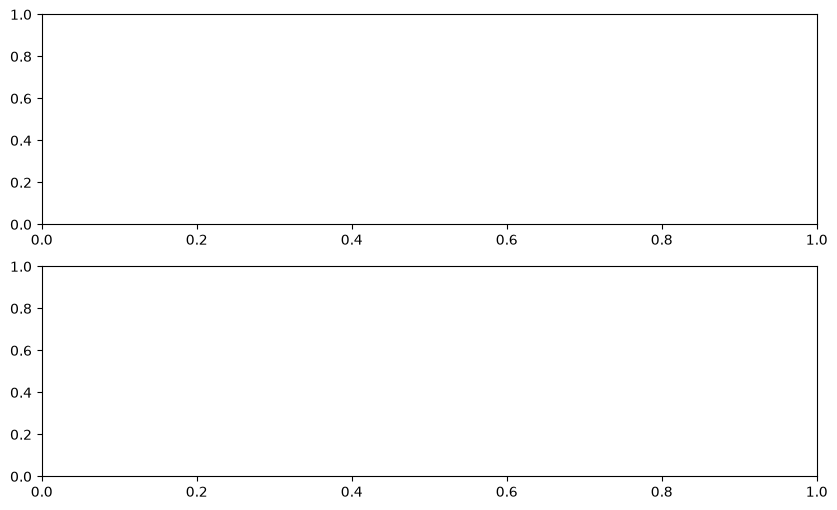

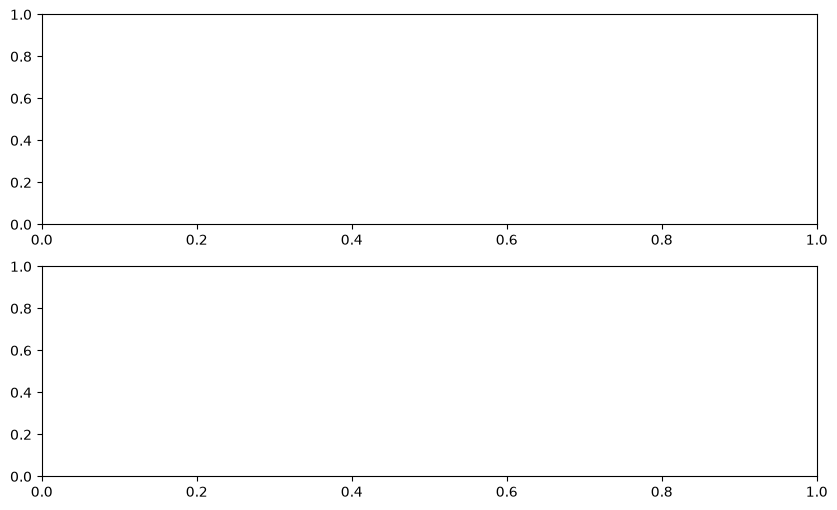

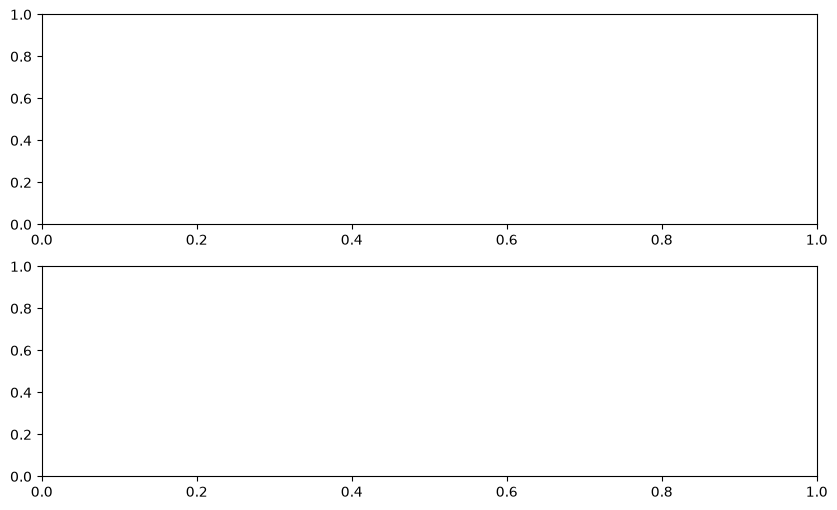

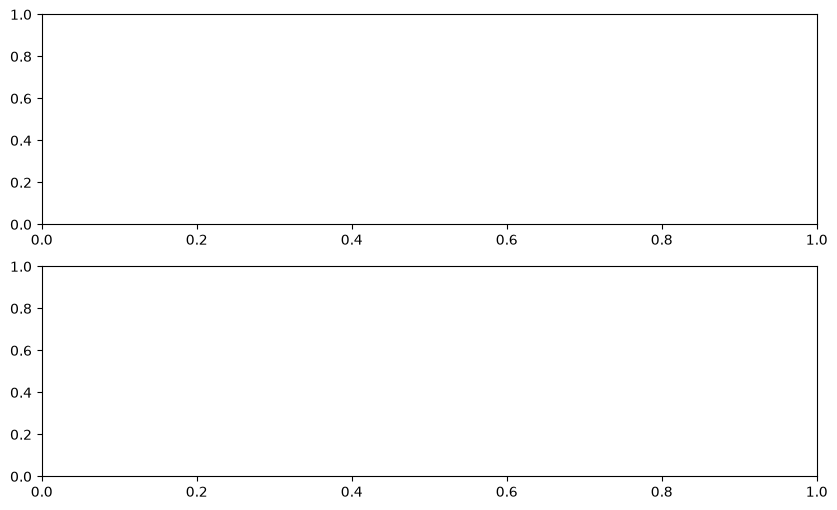

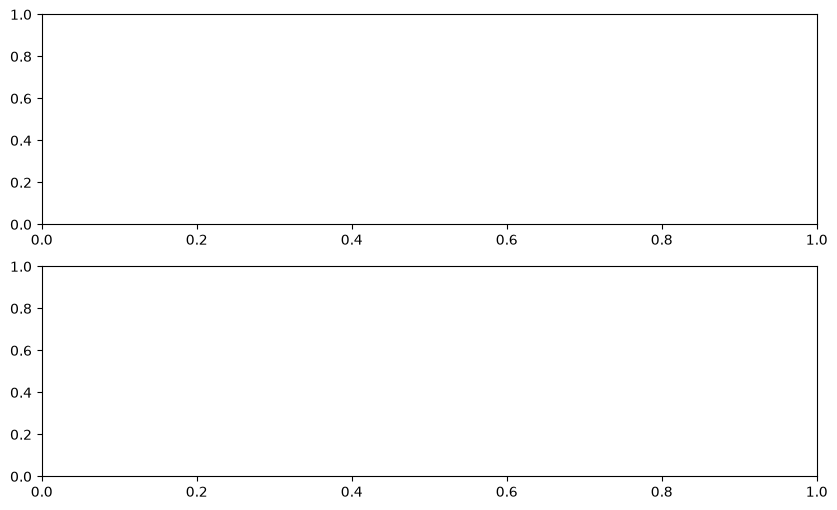

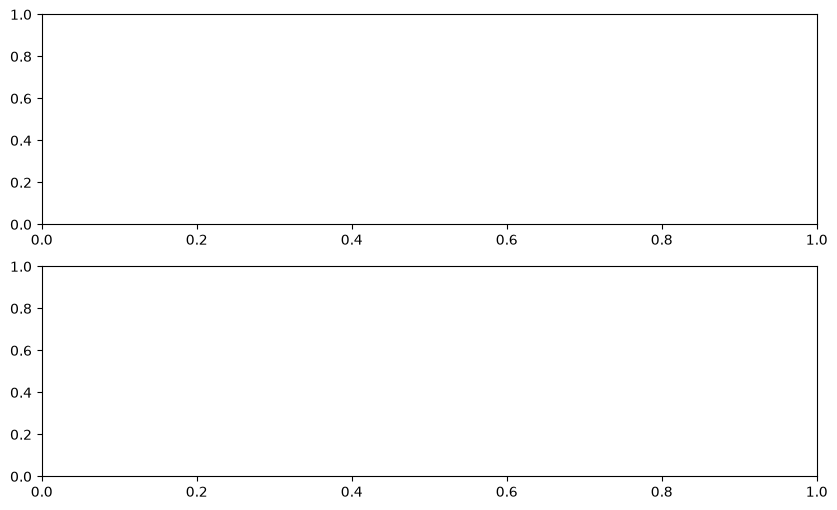

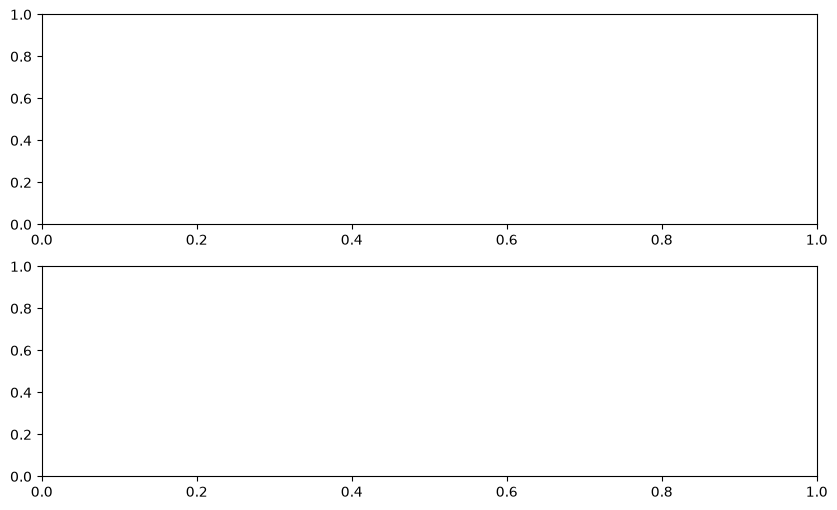

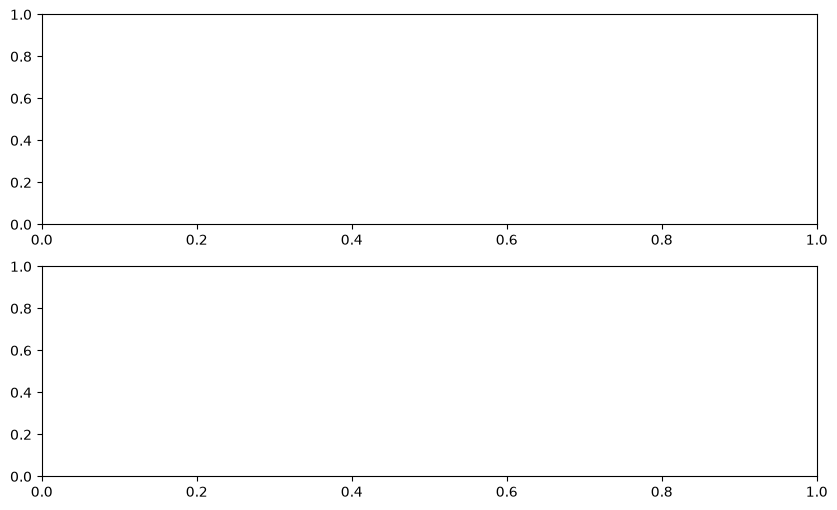

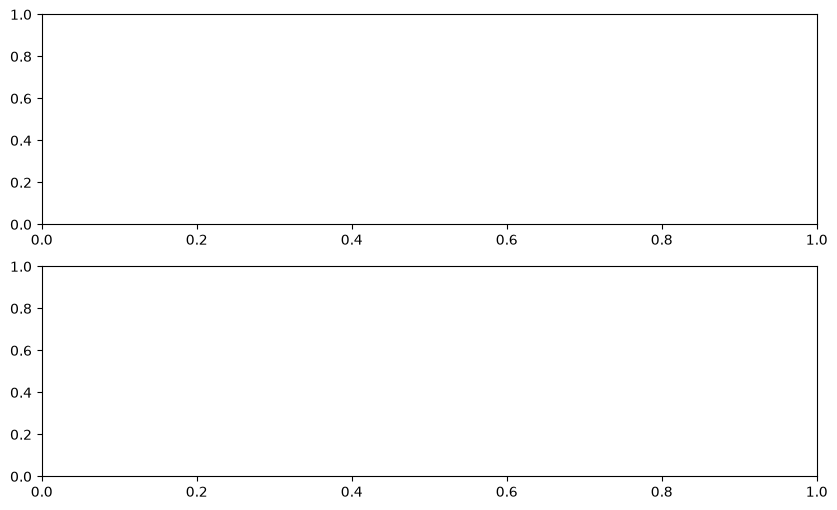

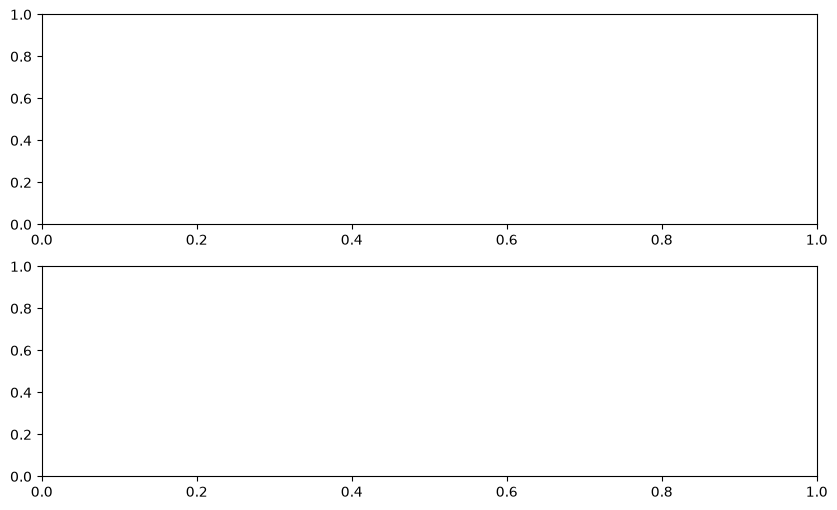

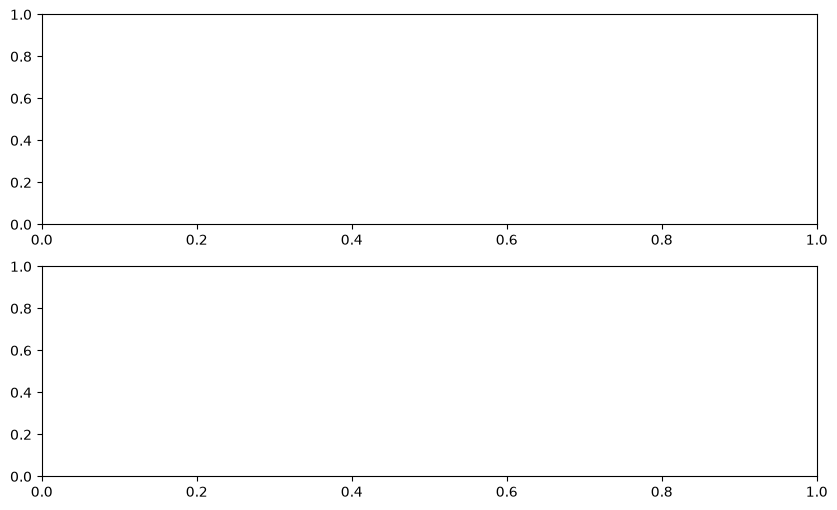

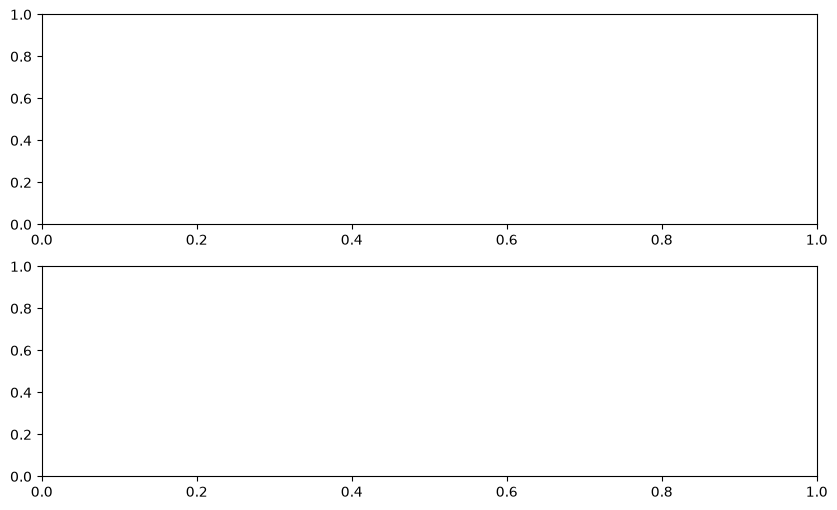

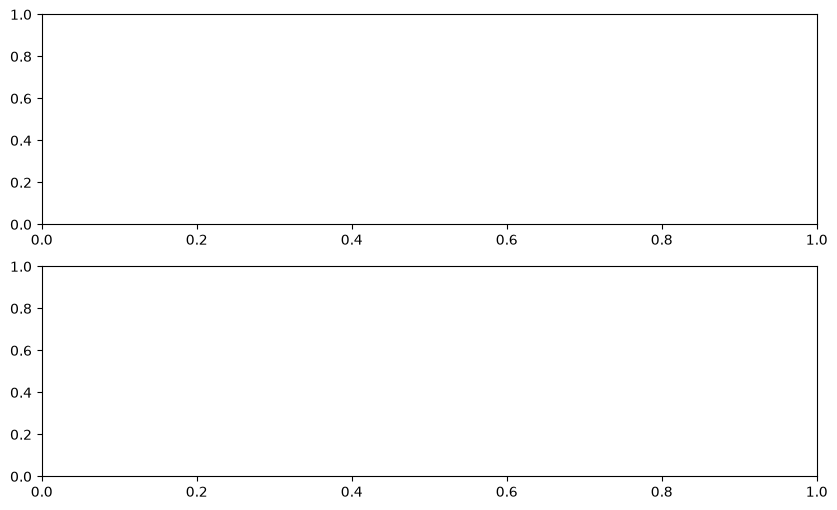

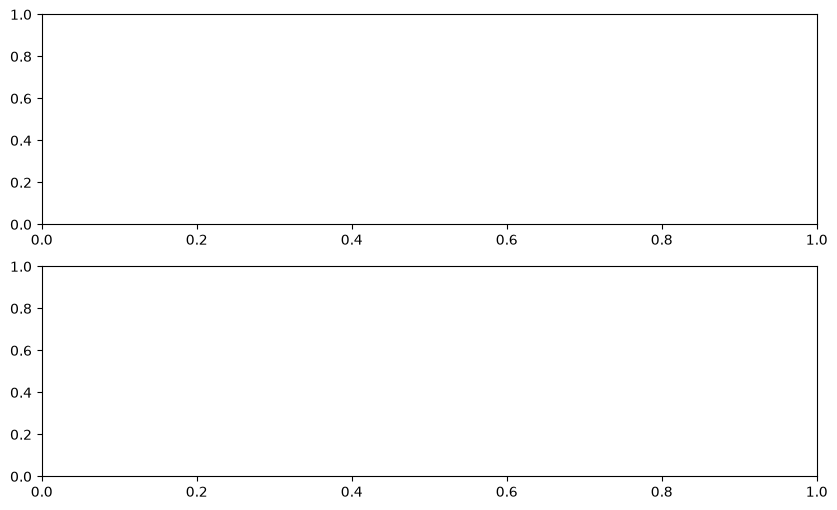

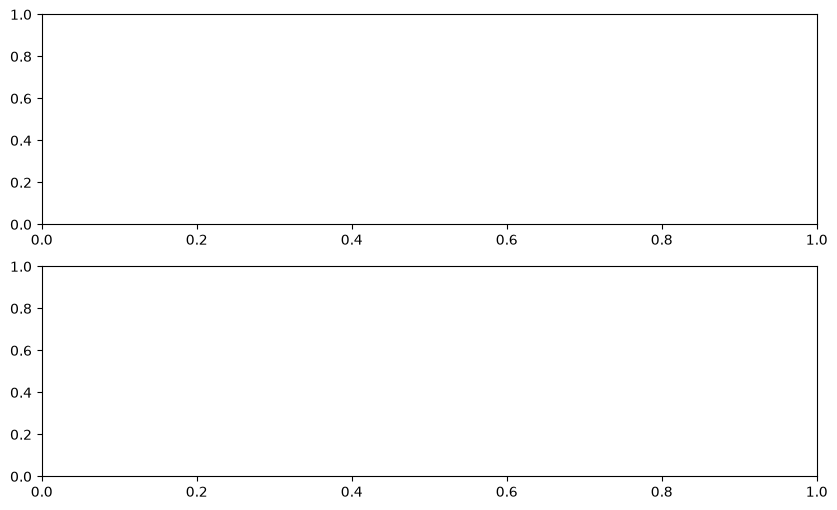

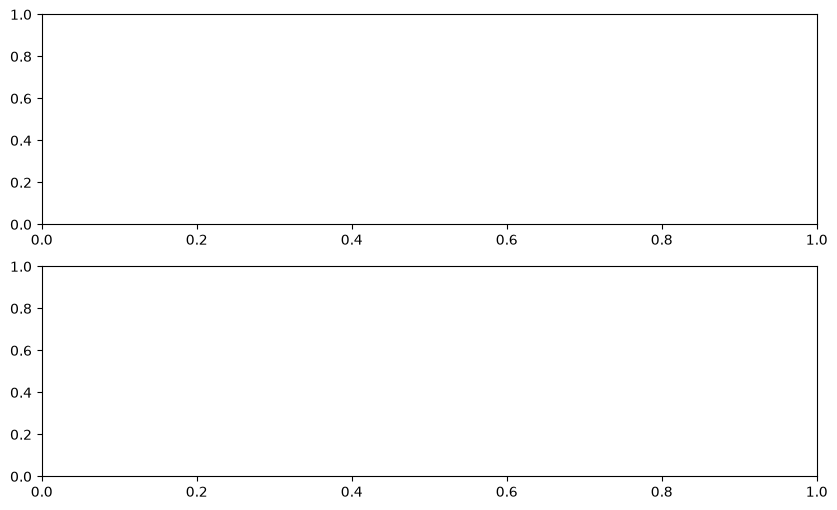

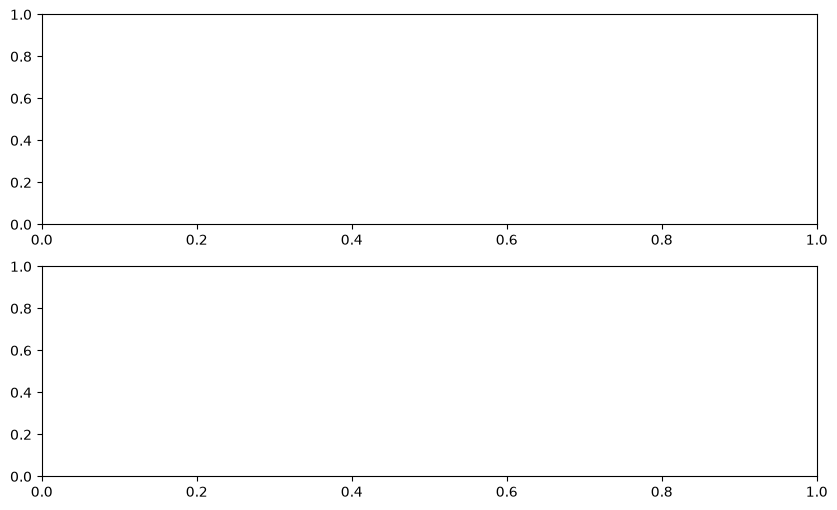

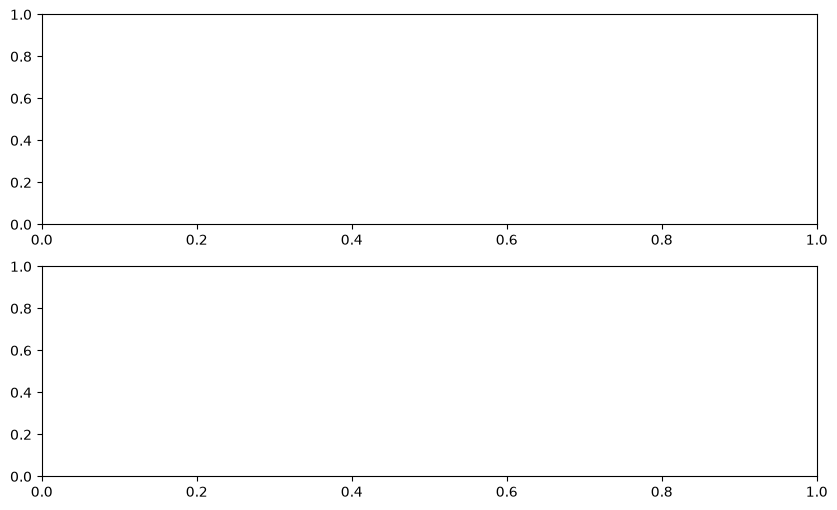

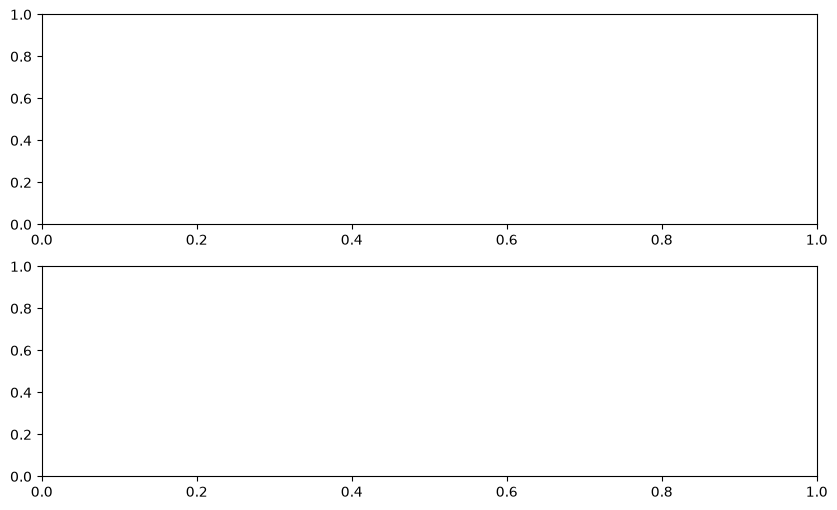

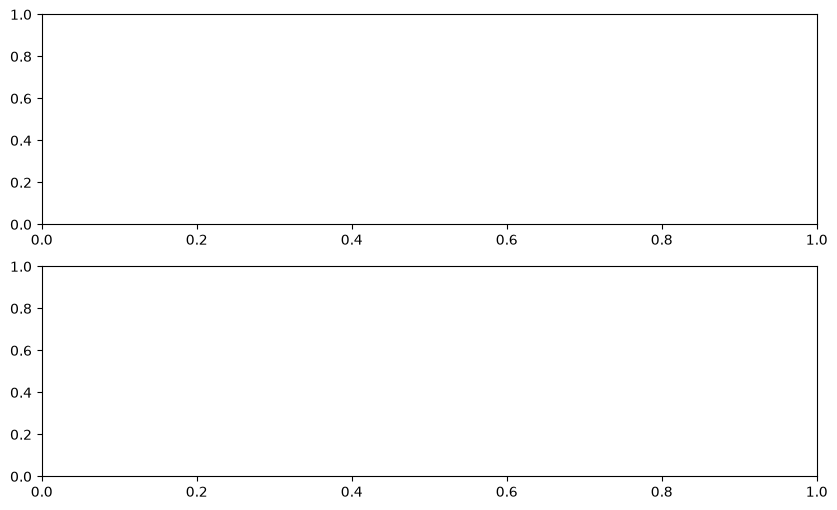

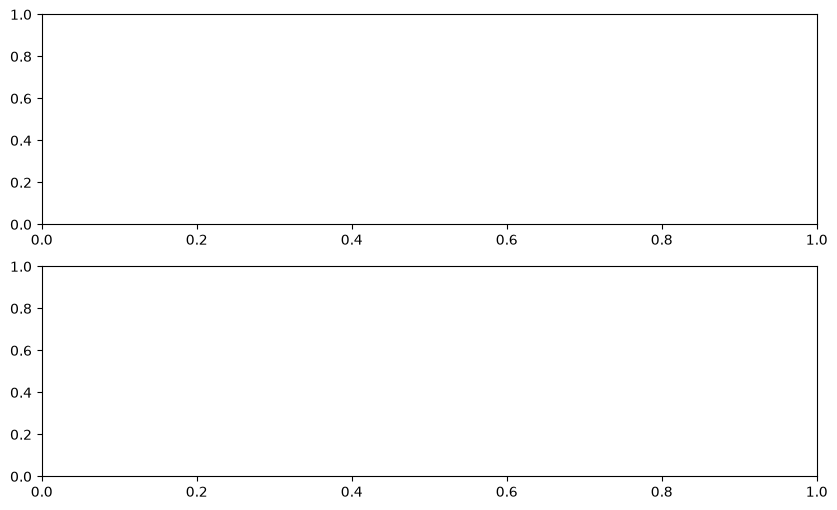

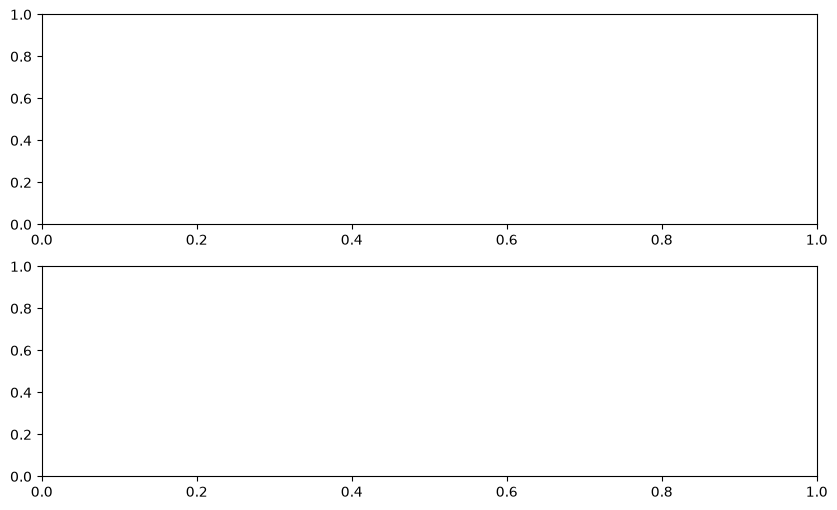

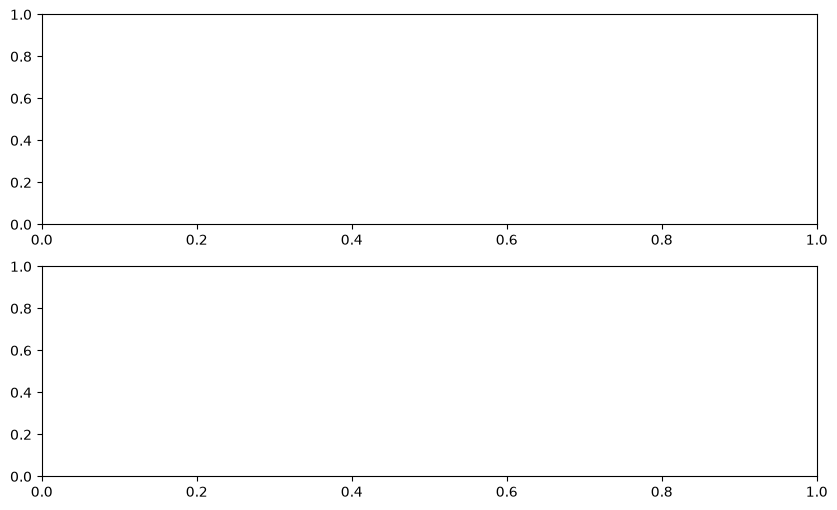

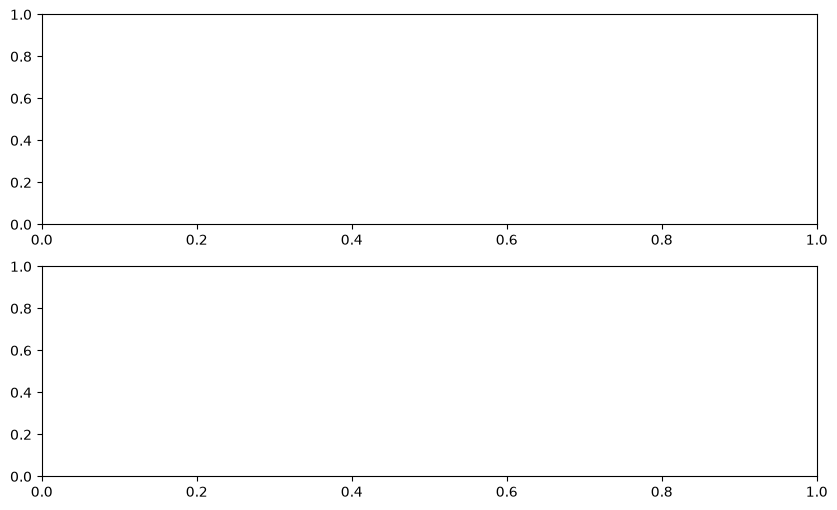

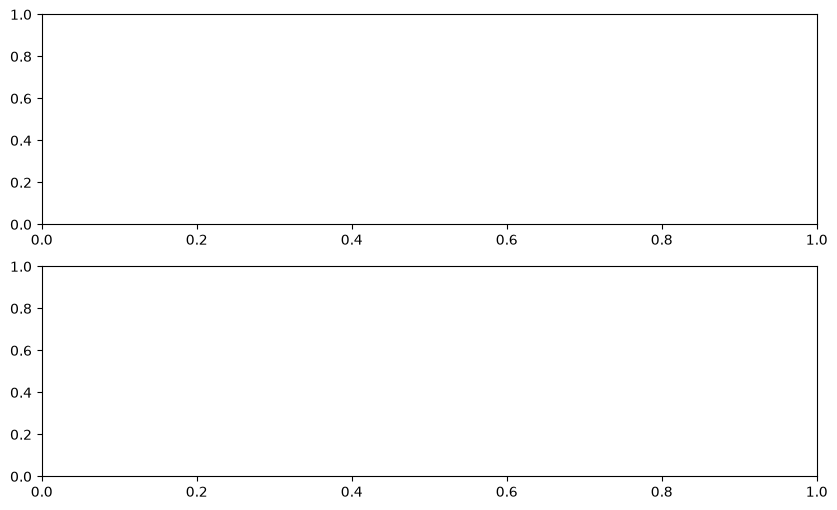

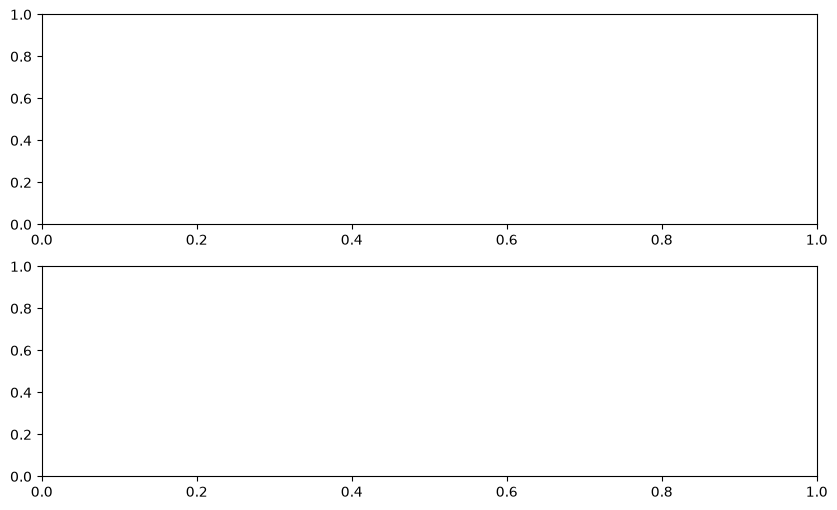

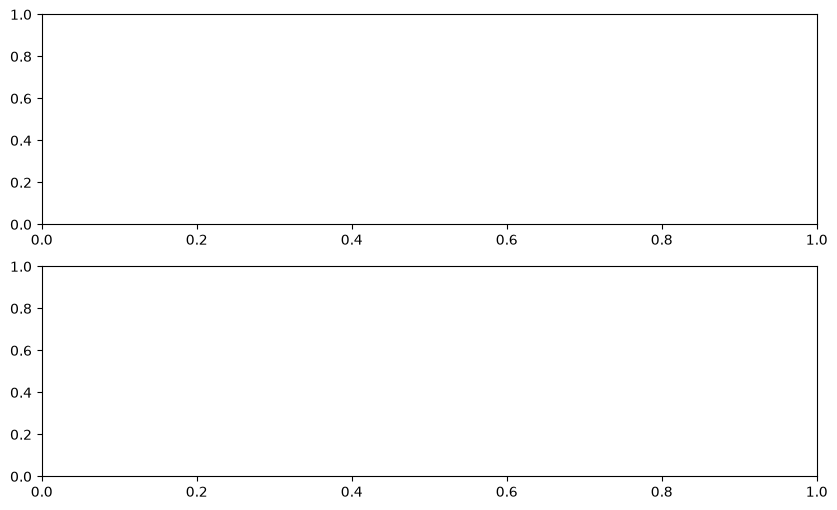

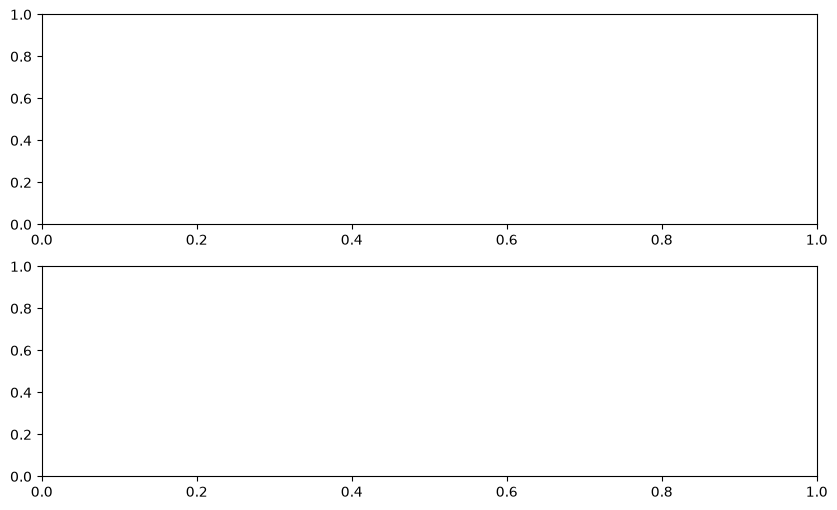

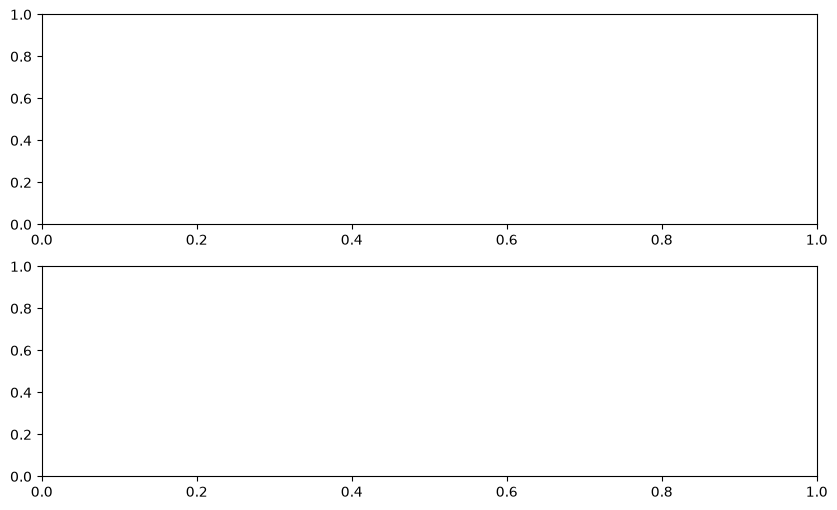

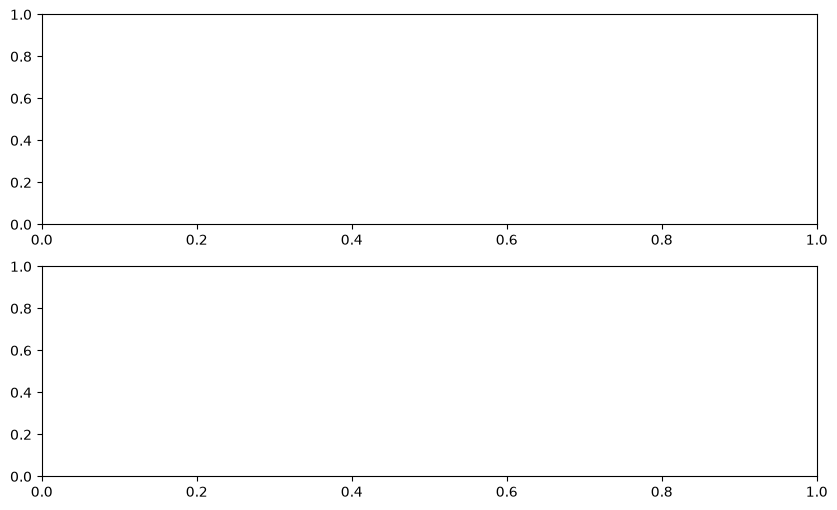

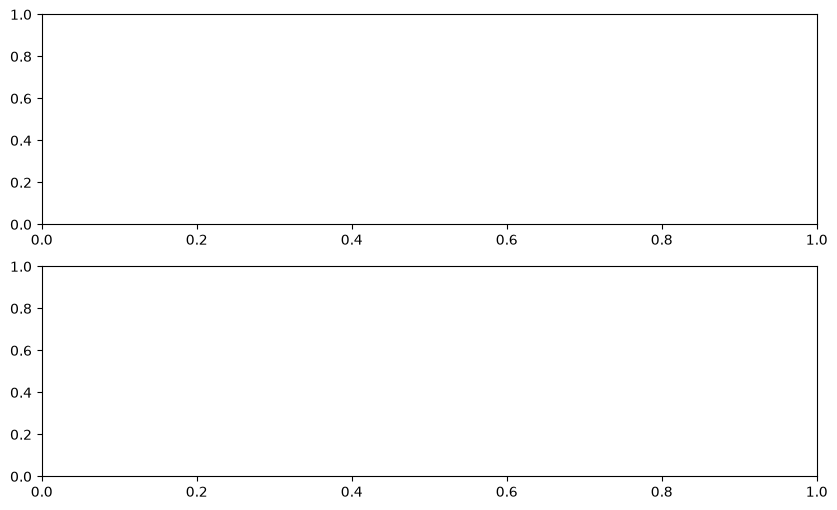

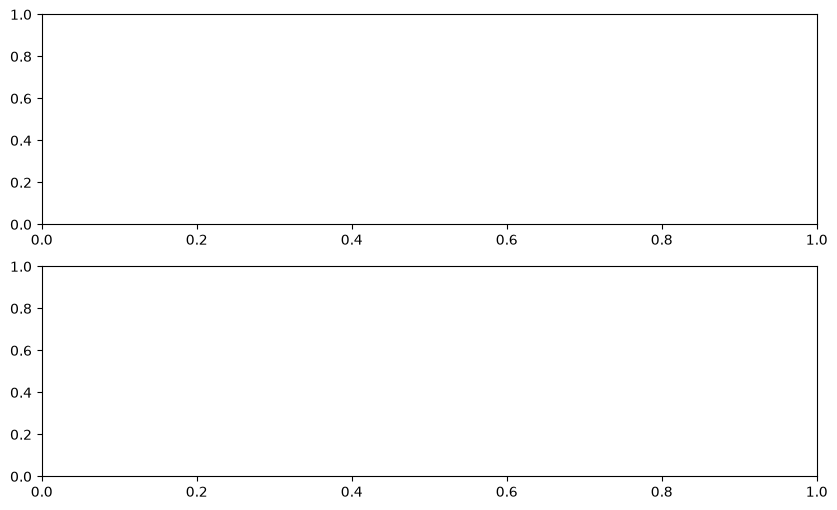

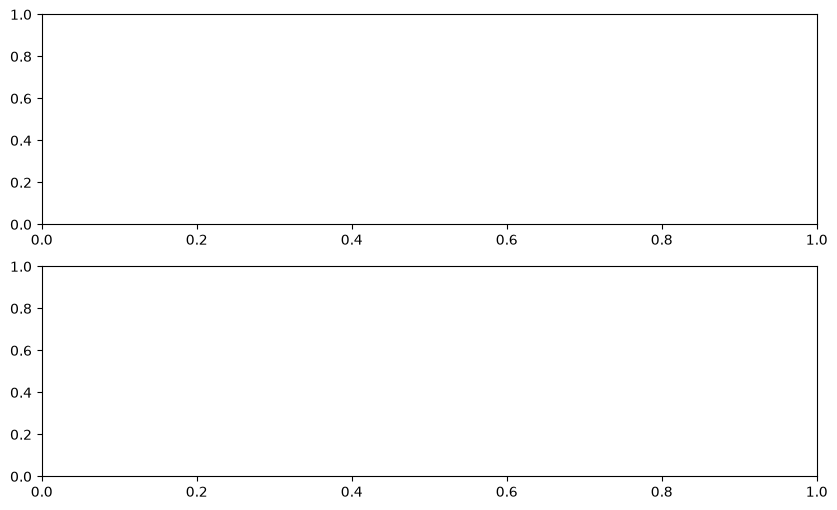

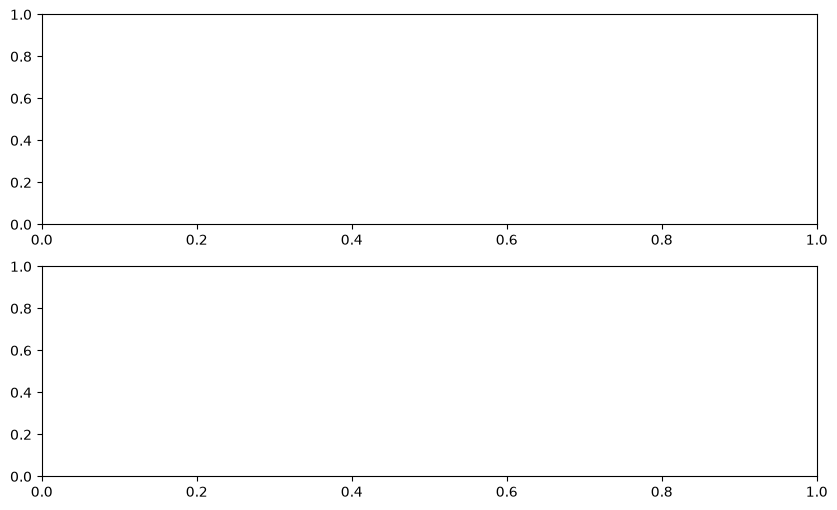

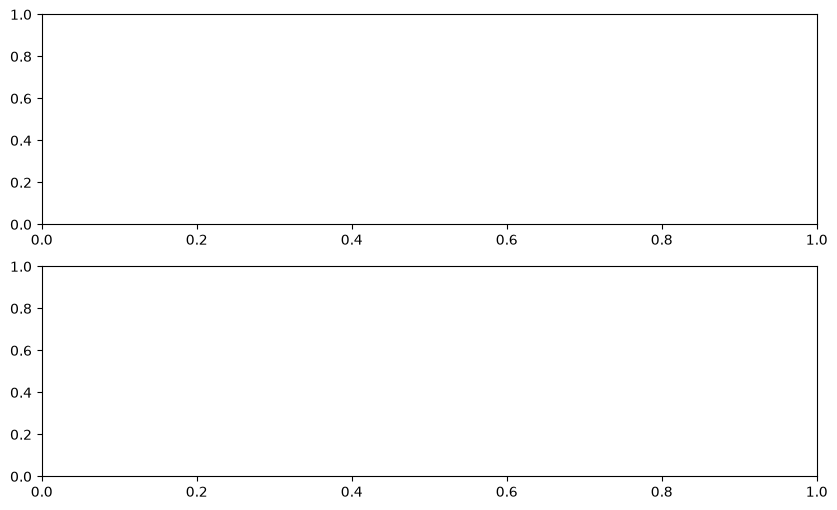

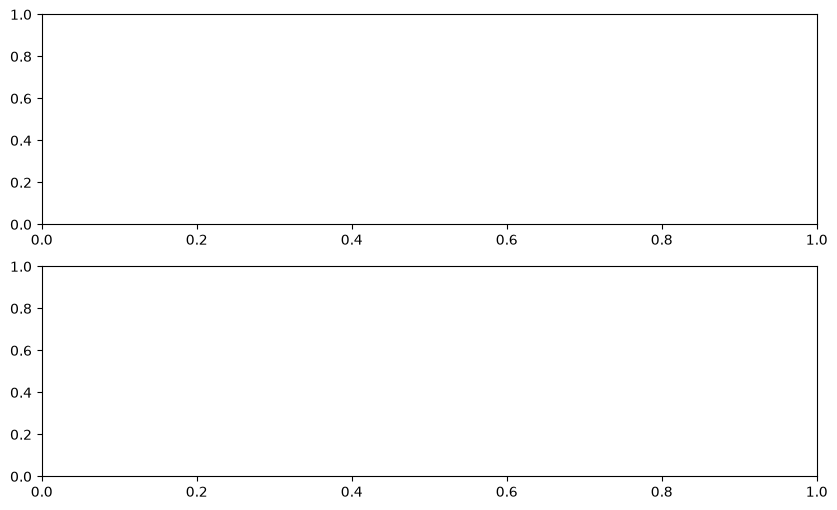

In [35]:

for variable, wissals_var in zip(variable_names, variable_name_in_wissals_data):
    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)

    try:
        my_var_data = ak.ravel(df_my_full_data[variable])
        wissals_var_data = ak.ravel(df_wissals_data[wissals_var])
    except KeyError as e:
        print(f"Variable {variable} not found in my data or wissals data: {e}")
        continue

    if variable == "LeadTrack_pz0" and wissals_var == "Track_pz_gev":
        my_var_data = my_var_data[my_var_data < 1e5]
        wissals_var_data = wissals_var_data[wissals_var_data < 1e5]


    bins = np.linspace(min(np.min(my_var_data), np.min(wissals_var_data)), max(np.max(my_var_data), np.max(wissals_var_data)), 50)
    
    my_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
    her_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))

    my_hist.fill(my_var_data)
    her_hist.fill(wissals_var_data)
    
    mplhep.histplot(my_hist, ax=ax[0], label="My data", alpha=0.5, flow="show")
    mplhep.histplot(her_hist, ax=ax[0], label="Wissal's data", alpha=0.5, flow="show")

    # ax[0].hist(ak.ravel(df_my_full_data[variable]), bins=bins, alpha=0.5, label="My data")
    # ax[0].hist(ak.ravel(df_wissals_data[wissals_var]), bins=bins, alpha=0.5, label="Wissal's data",)
    ax[0].set_xlabel(variable)
    ax[0].set_yscale("log")

    # ratio plot
    ratio = my_hist.view() / her_hist.view()
    ratio_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
    ratio_hist.view()[:] = ratio
    mplhep.histplot(ratio_hist, ax=ax[1], label="My data / Wissal's data", alpha=0.5, histtype="errorbar", color="black", flow="show")
    ax[1].set_xlabel(variable)
    ax[1].axhline(y=1, color='r', linestyle='--')
    
    # ax[0].set_xlim(min(np.min(my_var_data), np.min(wissals_var_data)), min(max(np.max(my_var_data), np.max(wissals_var_data)), 1e5))

(0.0, 5000.0)

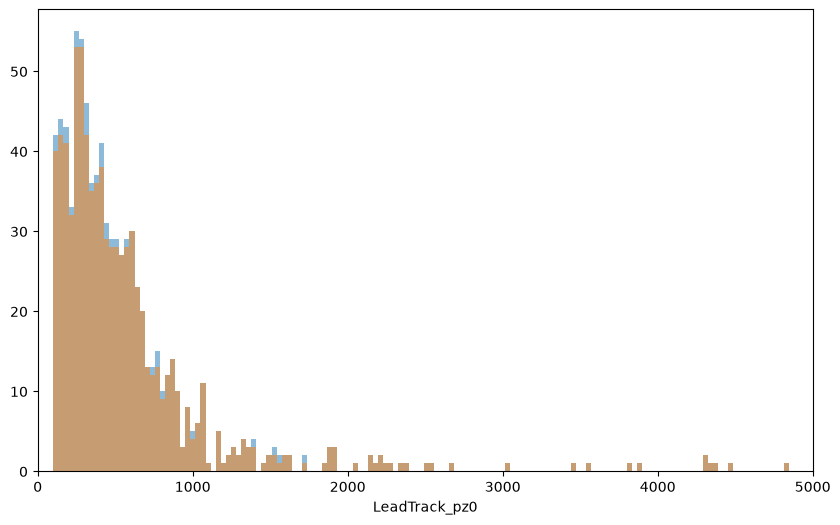

In [36]:
variable = "LeadTrack_pz0"
wissals_var = "Track_pz_gev"

fig, ax = plt.subplots(figsize=(10, 6))

my_var_data = ak.ravel(df_my_full_data[variable])
wissals_var_data = ak.ravel(df_wissals_data[wissals_var])

my_var_data = my_var_data[my_var_data < 1e5]

bins = np.linspace(min(np.min(my_var_data), np.min(wissals_var_data)), max(np.max(my_var_data), np.max(wissals_var_data)), 1000)

ax.hist(ak.ravel(df_my_full_data[variable]), bins=bins, alpha=0.5, label="My data")
ax.hist(ak.ravel(df_wissals_data[wissals_var]), bins=bins, alpha=0.5, label="Wissal's data",)
ax.set_xlabel(variable)
# ax.set_xlim(min(np.min(my_var_data), np.min(wissals_var_data)), min(max(np.max(my_var_data), np.max(wissals_var_data)), 1e5))
ax.set_xlim(0, 5e3)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f0ae11bf3b0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f08e743d340>, text=[])

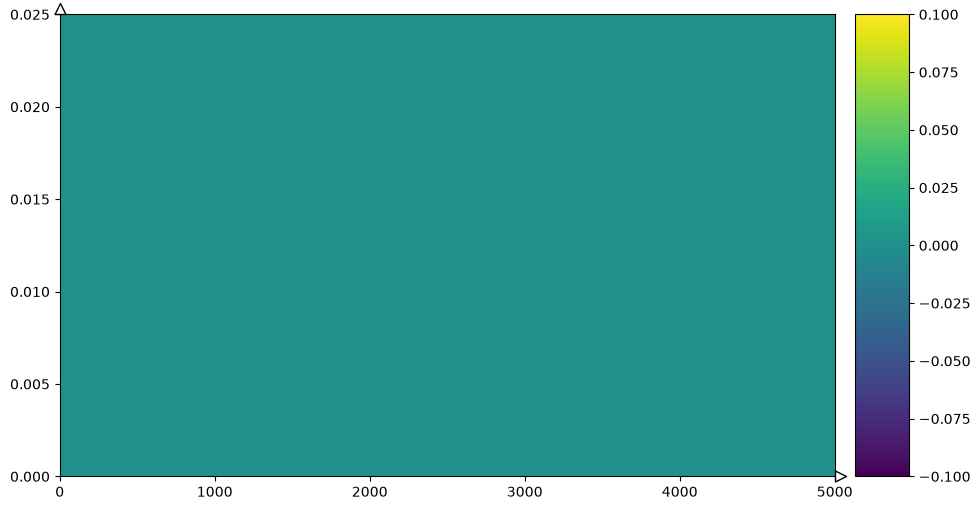

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

h_pz0_vs_theta = bh.Histogram(bh.axis.Regular(25, 0, 5e3), bh.axis.Regular(25, 0, 0.025))

my_pz0 = ak.ravel(df_my_full_data["LeadTrack_pz0"])
my_theta = ak.ravel(df_my_full_data["LeadTrack_Theta"])
h_pz0_vs_theta.fill(my_pz0, my_theta)

mplhep.hist2dplot(h_pz0_vs_theta, ax=ax, cmap="viridis", cbar=True)

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f08d99ff3b0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f0af23ea6f0>, text=[])

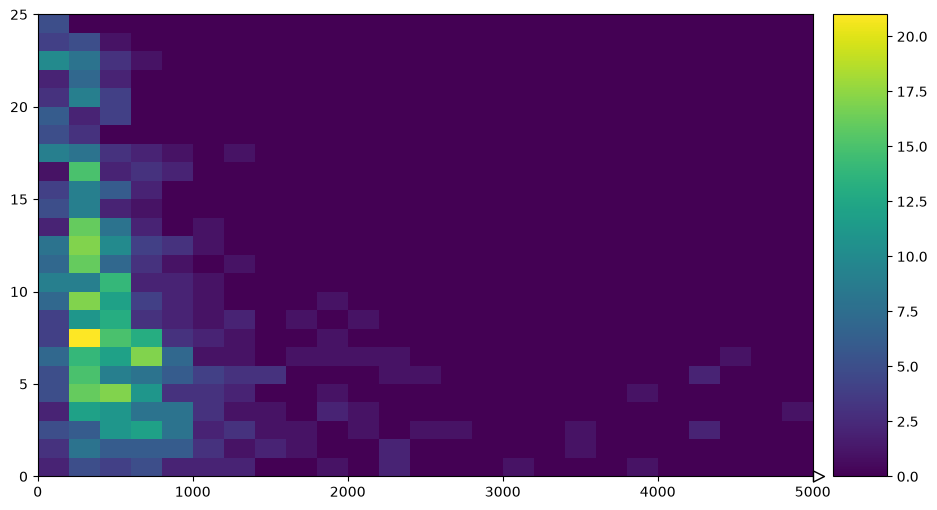

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

h_pz0_vs_theta = bh.Histogram(bh.axis.Regular(25, 0, 5e3), bh.axis.Regular(25, 0, 25))

wissals_pz0 = ak.ravel(df_wissals_data["Track_pz_gev"])
wissals_theta = ak.ravel(df_wissals_data["theta_mrad"])
h_pz0_vs_theta.fill(wissals_pz0, wissals_theta)

mplhep.hist2dplot(h_pz0_vs_theta, ax=ax, cmap="viridis", cbar=True)

KeyError: 'Calo0_baseline,Calo0_baseline_rms,Calo1_baseline,Calo1_baseline_rms,Calo2_baseline,Calo2_baseline_rms,Calo3_baseline,Calo3_baseline_rms,CaloNu0_baseline,CaloNu0_baseline_rms,CaloNu1_baseline,CaloNu1_baseline_rms,CaloNu2_baseline,CaloNu2_baseline_rms,CaloNu3_baseline,CaloNu3_baseline_rms,Preshower0_baseline,Preshower0_baseline_rms,Preshower1_baseline,Preshower1_baseline_rms,Timing0_baseline,Timing0_baseline_rms,Timing1_baseline,Timing1_baseline_rms,Timing2_baseline,Timing2_baseline_rms,Timing3_baseline,Timing3_baseline_rms,Veto10_baseline,Veto10_baseline_rms,Veto20_baseline,Veto20_baseline_rms,Veto21_baseline,Veto21_baseline_rms,VetoNu0_baseline,VetoNu0_baseline_rms,VetoNu1_baseline,VetoNu1_baseline_rms,'

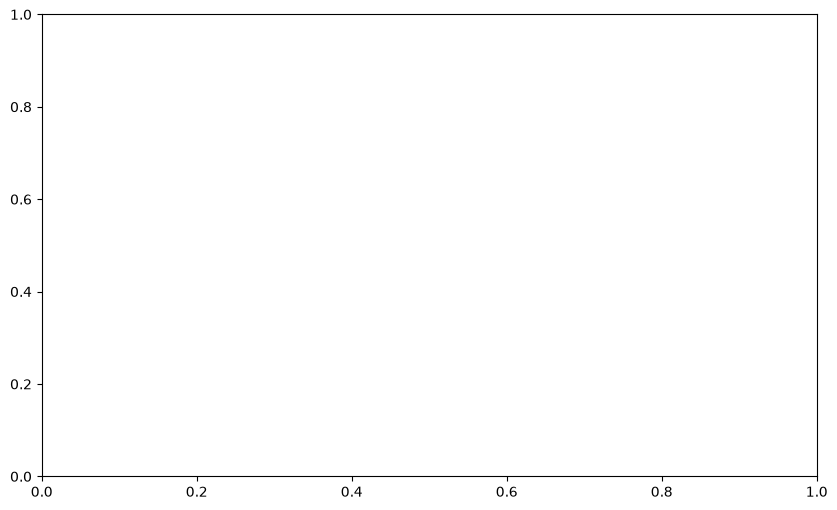

In [39]:
baseline_vars = [
"Calo0_baseline,"
"Calo0_baseline_rms,"
"Calo1_baseline,"
"Calo1_baseline_rms,"
"Calo2_baseline,"
"Calo2_baseline_rms,"
"Calo3_baseline,"
"Calo3_baseline_rms,"
"CaloNu0_baseline,"
"CaloNu0_baseline_rms,"
"CaloNu1_baseline,"
"CaloNu1_baseline_rms,"
"CaloNu2_baseline,"
"CaloNu2_baseline_rms,"
"CaloNu3_baseline,"
"CaloNu3_baseline_rms,"
"Preshower0_baseline,"
"Preshower0_baseline_rms,"
"Preshower1_baseline,"
"Preshower1_baseline_rms,"
"Timing0_baseline,"
"Timing0_baseline_rms,"
"Timing1_baseline,"
"Timing1_baseline_rms,"
"Timing2_baseline,"
"Timing2_baseline_rms,"
"Timing3_baseline,"
"Timing3_baseline_rms,"
"Veto10_baseline,"
"Veto10_baseline_rms,"
"Veto20_baseline,"
"Veto20_baseline_rms,"
"Veto21_baseline,"
"Veto21_baseline_rms,"
"VetoNu0_baseline,"
"VetoNu0_baseline_rms,"
"VetoNu1_baseline,"
"VetoNu1_baseline_rms,"
]

for key in baseline_vars:
    fig, ax = plt.subplots(figsize=(10, 6))
    my_var_data = ak.ravel(df_my_full_data[key])

In [ ]:
df_my_full_data.keys()

Index(['CaloNu0_baseline', 'CaloNu0_baseline_rms', 'CaloNu1_baseline',
       'CaloNu1_baseline_rms', 'CaloNu2_baseline', 'CaloNu2_baseline_rms',
       'CaloNu3_baseline', 'CaloNu3_baseline_rms', 'LeadTrack_Chi2',
       'LeadTrack_Theta', 'LeadTrack_nDoF', 'LeadTrack_nLayers',
       'LeadTrack_pz0', 'LeadTrack_rIFT', 'LeadTrack_rVetoNu',
       'LeadTrack_r_atMaxRadius', 'Preshower0_baseline',
       'Preshower0_baseline_rms', 'Preshower0_charge', 'Preshower1_baseline',
       'Preshower1_baseline_rms', 'Preshower1_charge', 'Timing0_baseline',
       'Timing0_baseline_rms', 'Timing1_baseline', 'Timing1_baseline_rms',
       'Timing2_baseline', 'Timing2_baseline_rms', 'Timing3_baseline',
       'Timing3_baseline_rms', 'Timing_charge_bottom', 'Timing_charge_top',
       'Veto10_baseline', 'Veto10_baseline_rms', 'Veto20_baseline',
       'Veto20_baseline_rms', 'Veto20_charge', 'Veto21_baseline',
       'Veto21_baseline_rms', 'Veto21_charge', 'VetoNu0_baseline',
       'VetoNu0_baseline

In [ ]:
df_my_full_data["CaloNu0_baseline"]

0      1914.598633
1      1914.602051
2      1914.779419
3      1914.651245
4      1914.421875
          ...     
843            NaN
844            NaN
845    1914.519043
846    1914.441528
847    1914.417725
Name: CaloNu0_baseline, Length: 848, dtype: float32

/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-pac

Variable: VetoNu0_reduced_charge, min: 0.0, max: 29.776395797729492
Variable: VetoNu1_reduced_charge, min: 0.0, max: 29.58188819885254
Variable: Veto20_charge, min: 57.07207489013672, max: 48210.453125
Variable: Veto21_charge, min: 54.281951904296875, max: 41405.4140625
Variable: Timing_charge_top, min: 0.4564026892185211, max: 10686.2265625


/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-pac

Variable: Timing_charge_bottom, min: 0.5524706840515137, max: 27518.716796875
Variable: Preshower0_charge, min: 3.3116860389709473, max: 1090.6385498046875
Variable: Preshower1_charge, min: 3.0263705253601074, max: 1051.4027099609375
Variable: longTracks, min: 1, max: 4
Variable: LeadTrack_nLayers, min: 7, max: 9


/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-pac

...

/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-pac

Variable: Veto21_baseline, min: 1899.594970703125, max: 1902.606689453125
Variable: Veto21_baseline_rms, min: 0.1415092647075653, max: 0.48230189085006714
Variable: VetoNu0_baseline, min: 1914.2646484375, max: 1915.4251708984375


/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


Variable: VetoNu0_baseline_rms, min: 0.1933334469795227, max: 0.5164610743522644
Variable: VetoNu1_baseline, min: 1906.58837890625, max: 1907.6962890625
Variable: VetoNu1_baseline_rms, min: 0.18220961093902588, max: 0.5705645680427551


/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


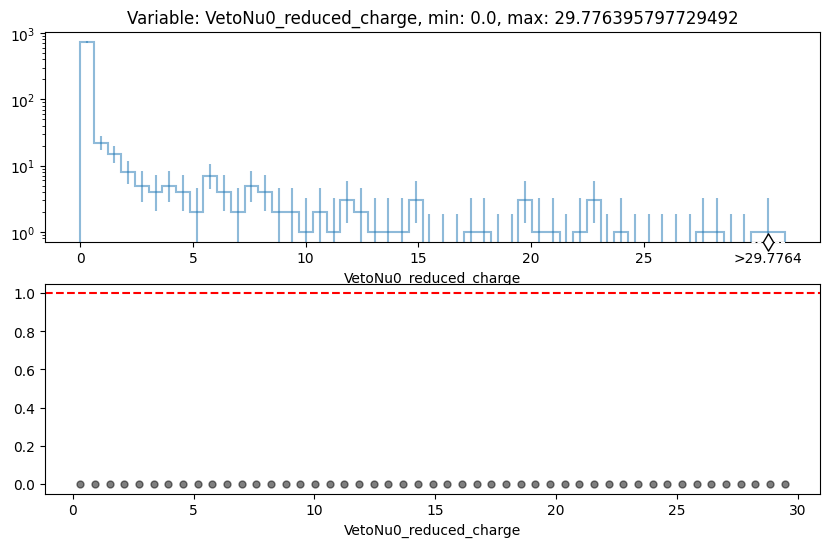

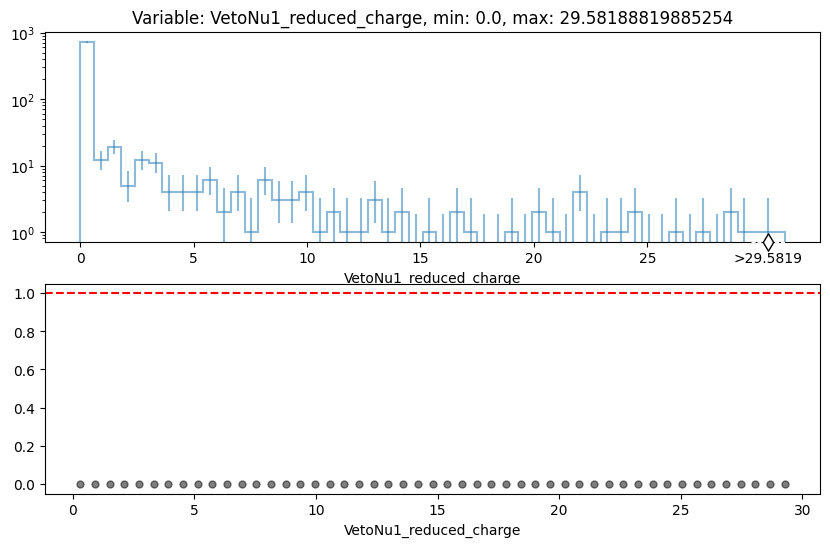

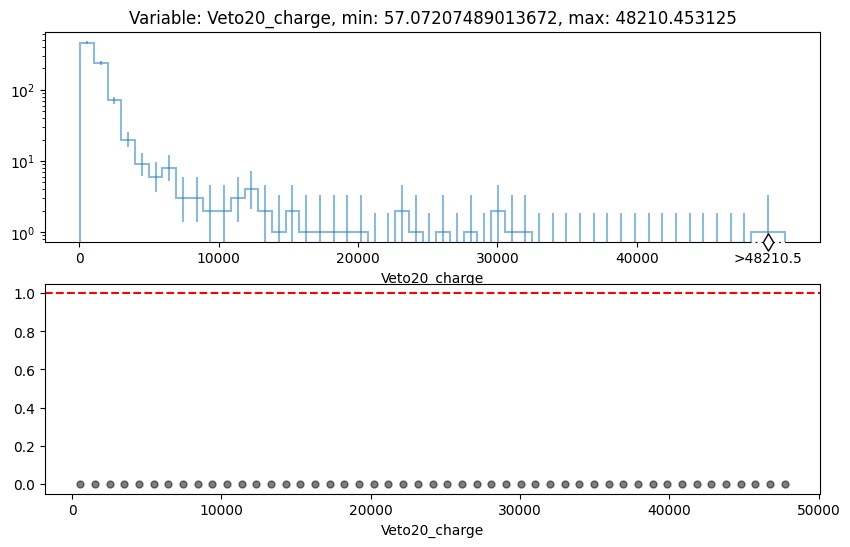

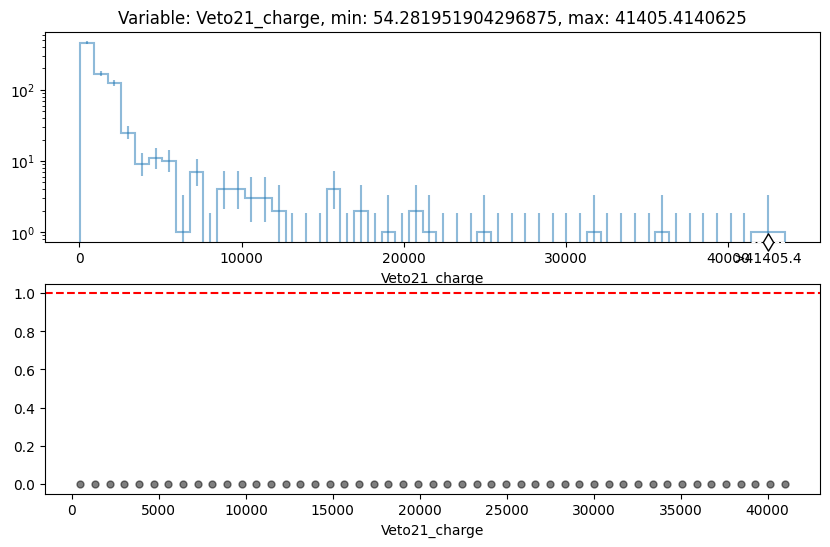

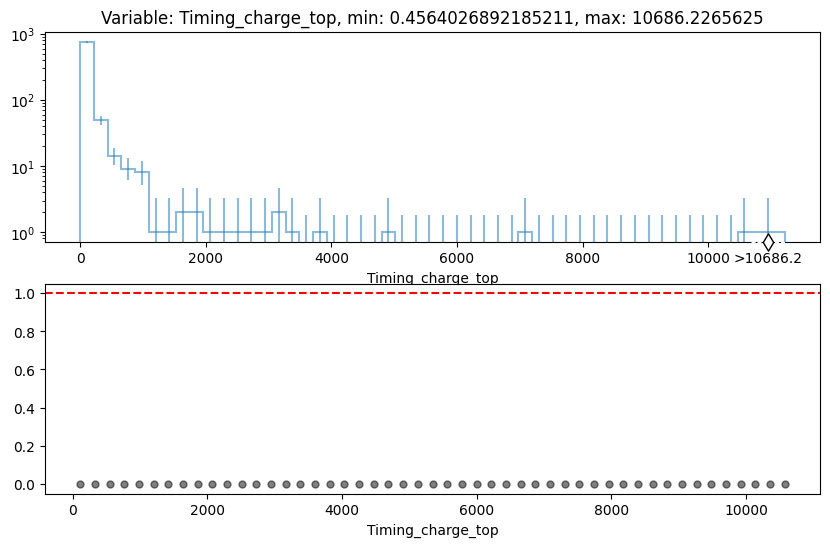

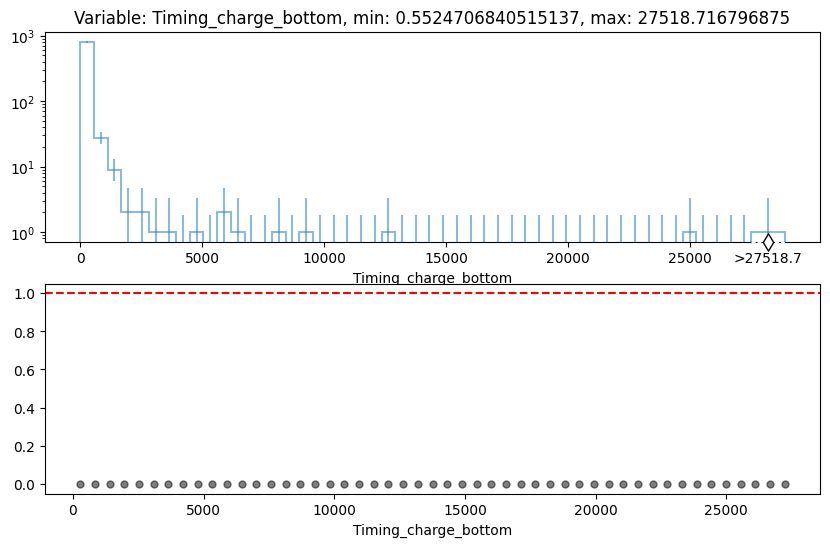

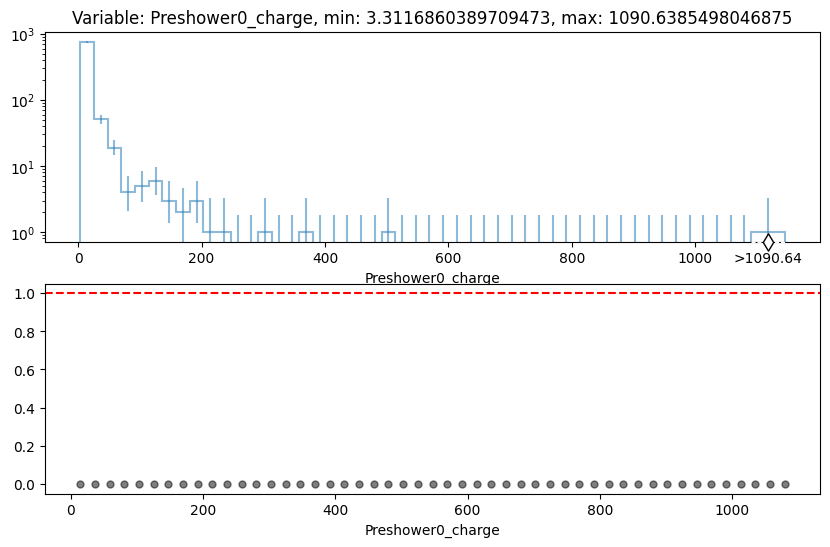

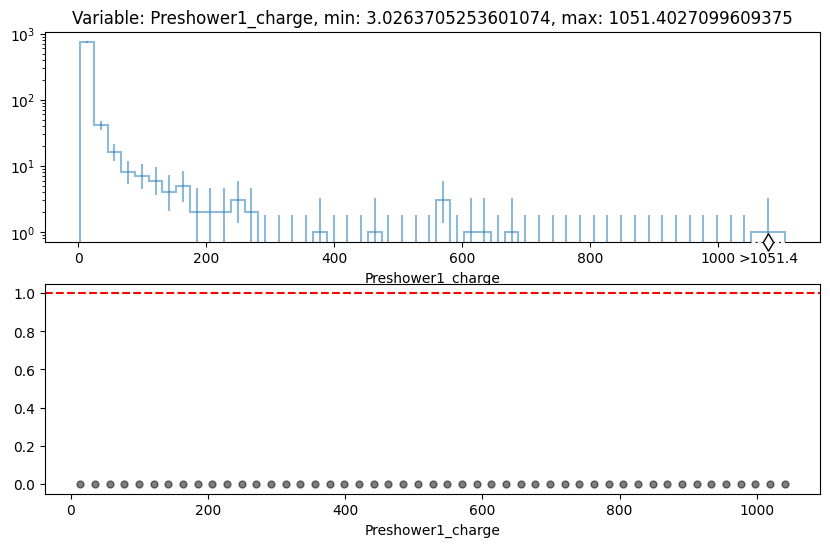

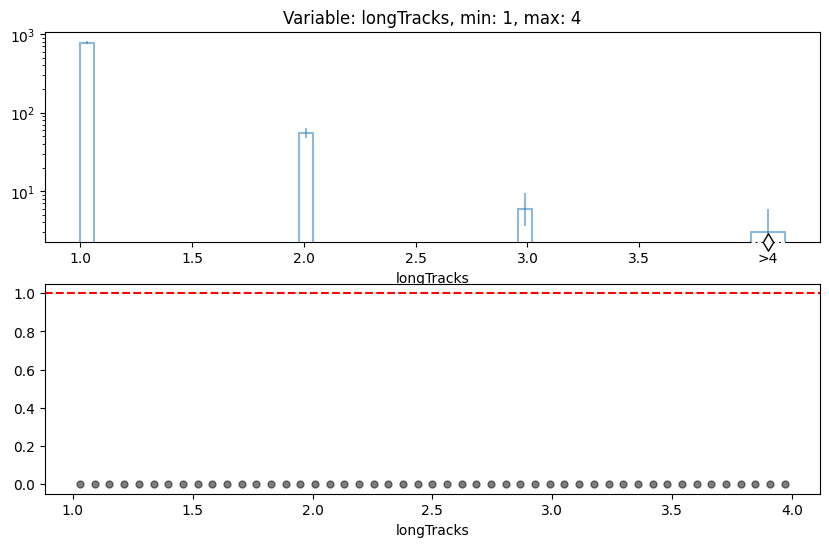

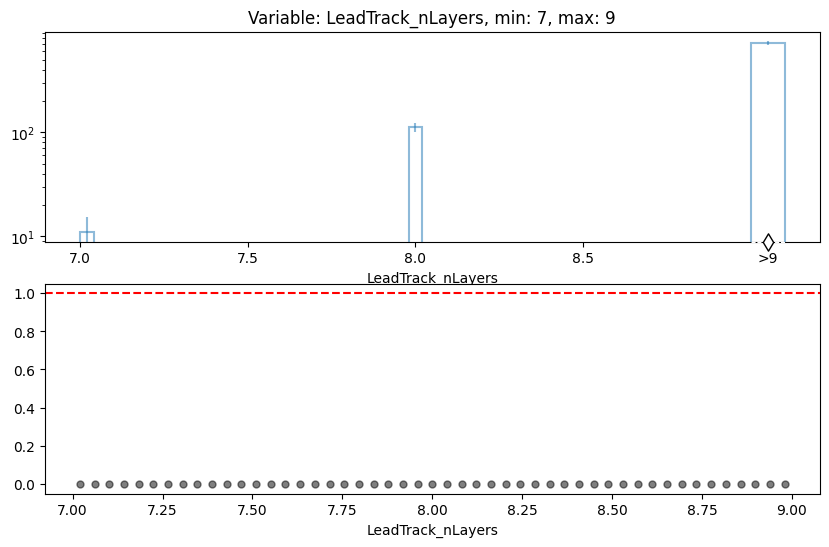

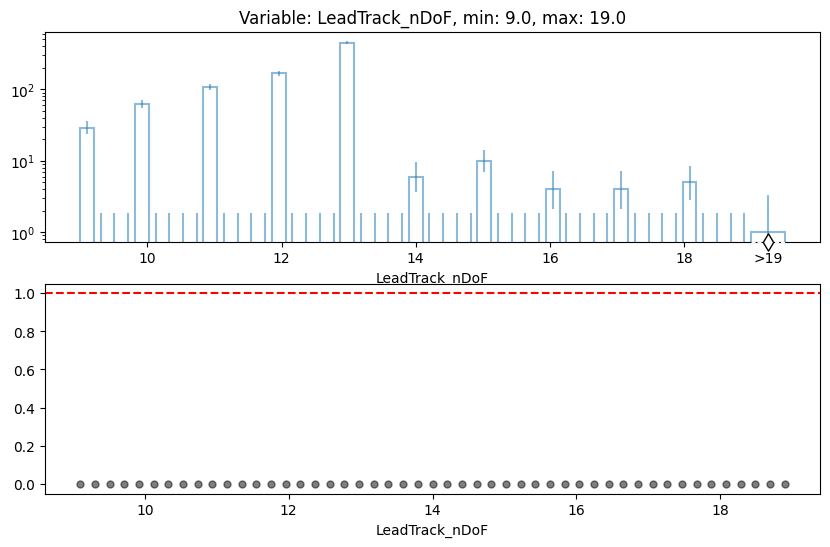

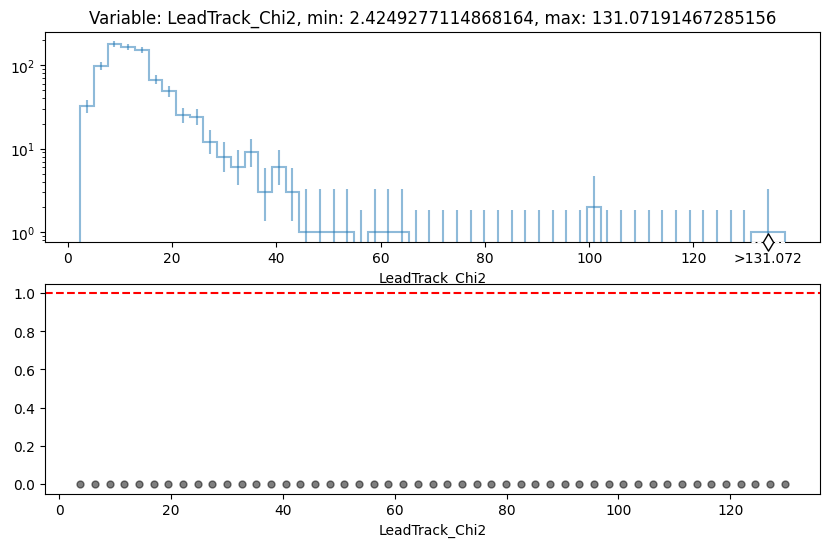

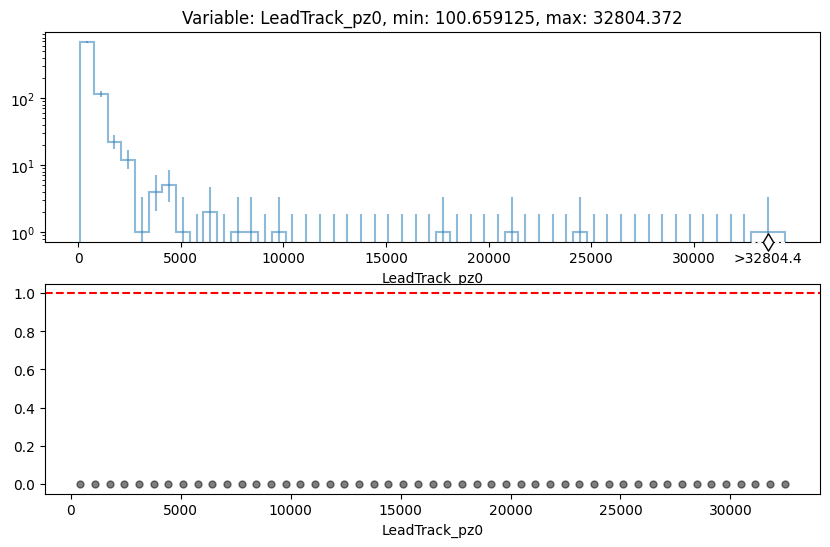

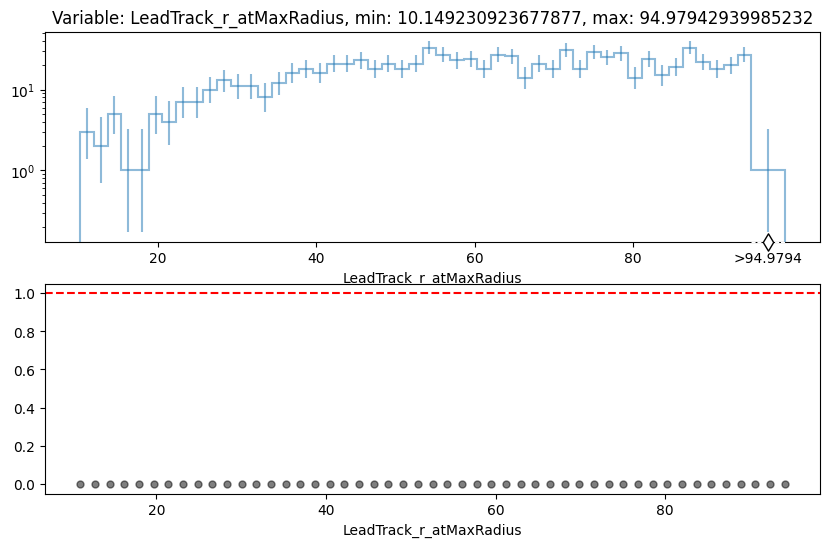

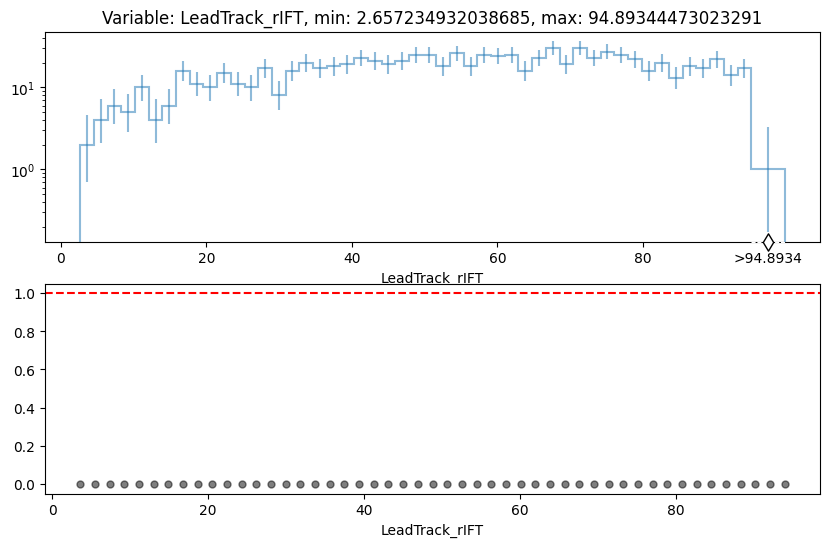

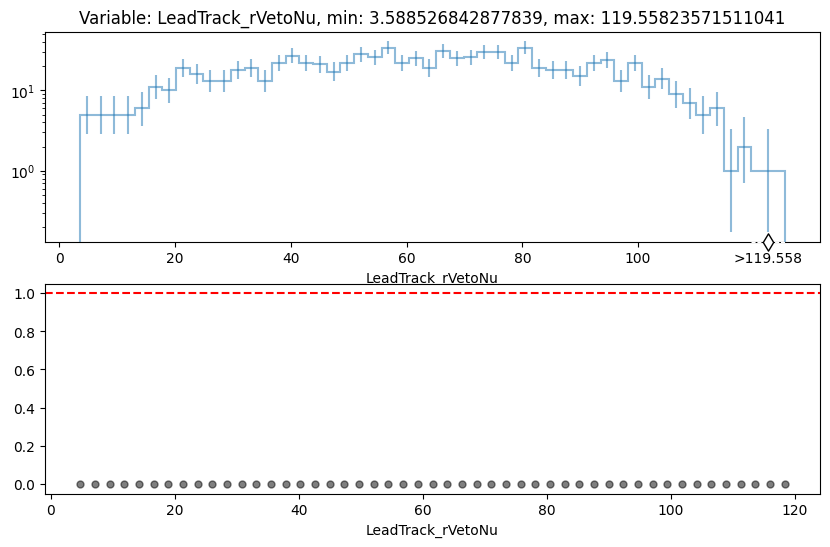

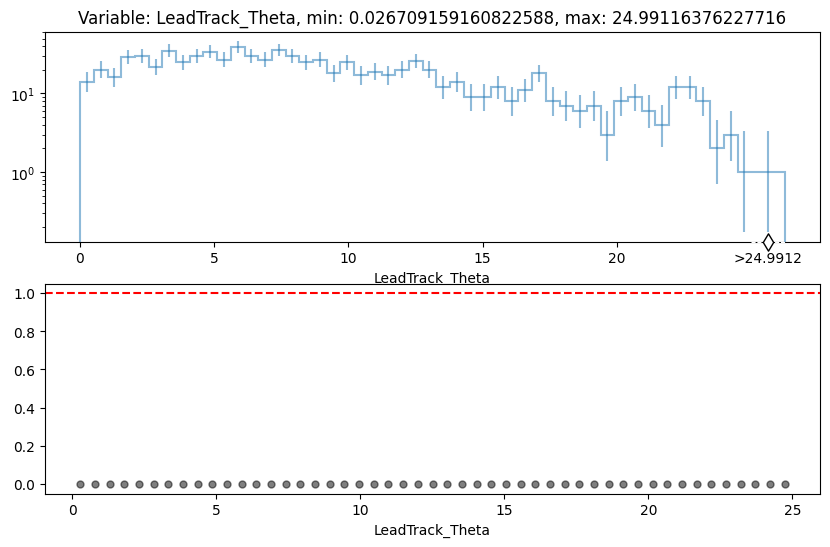

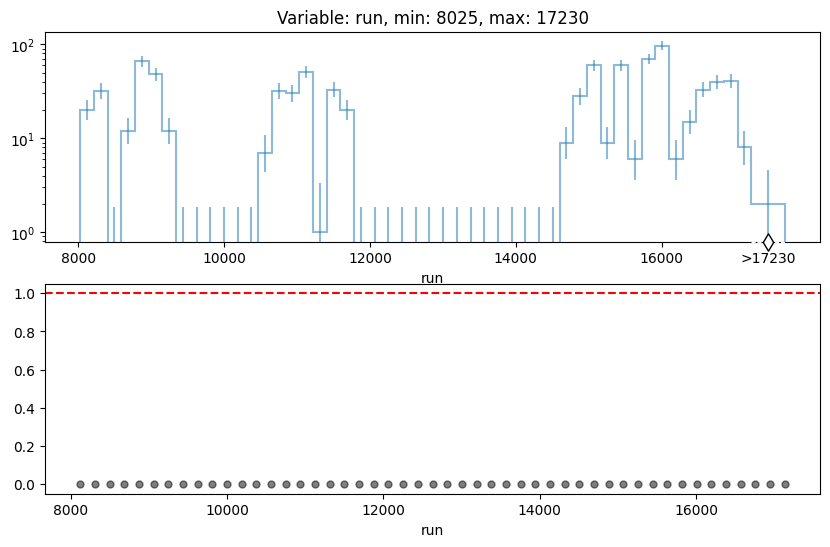

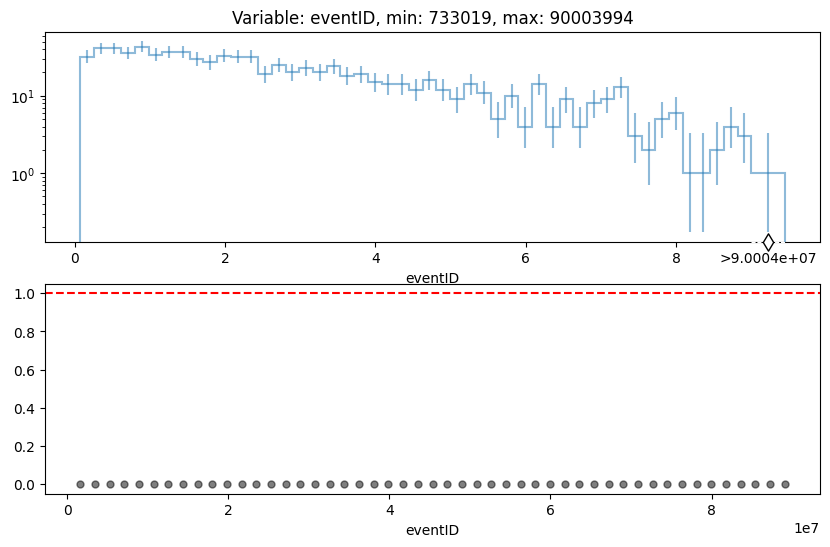

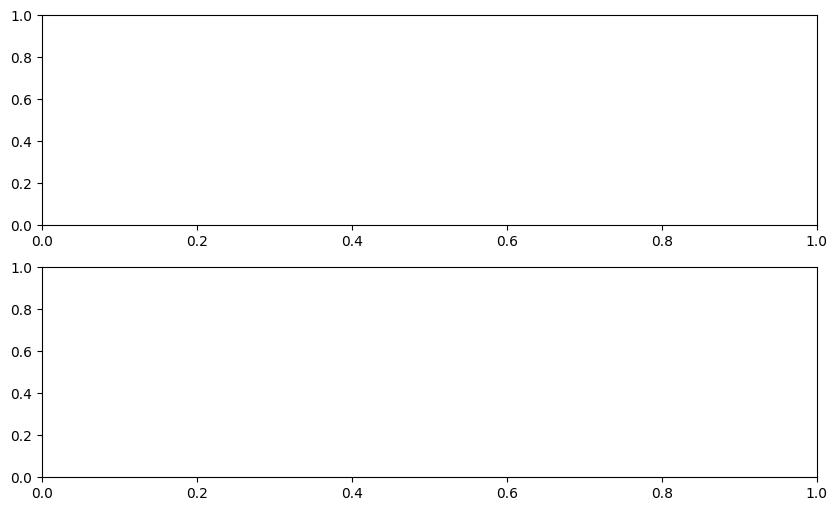

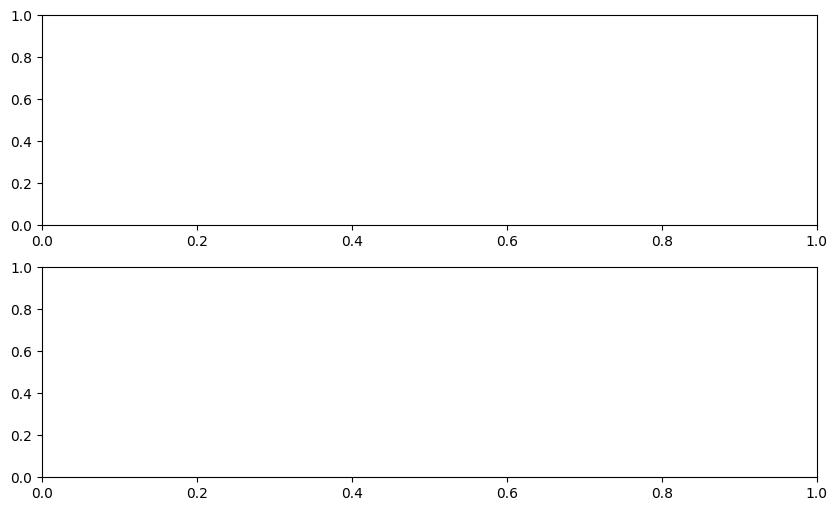

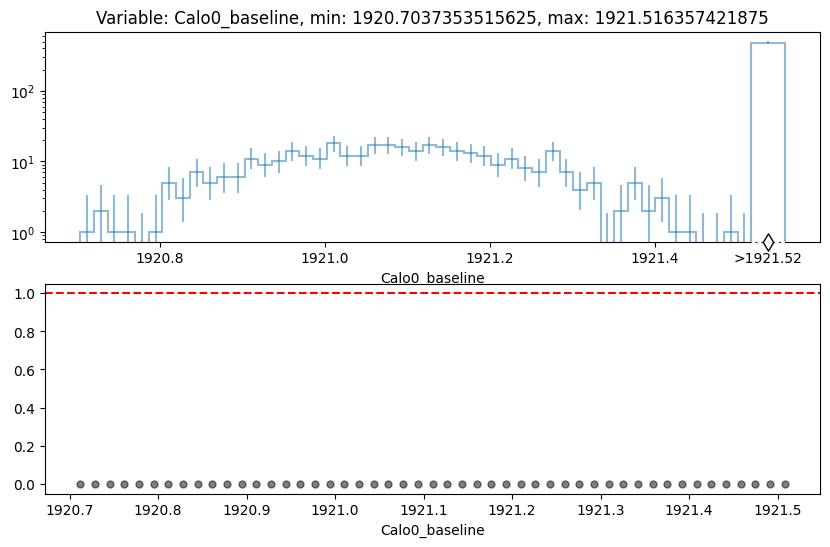

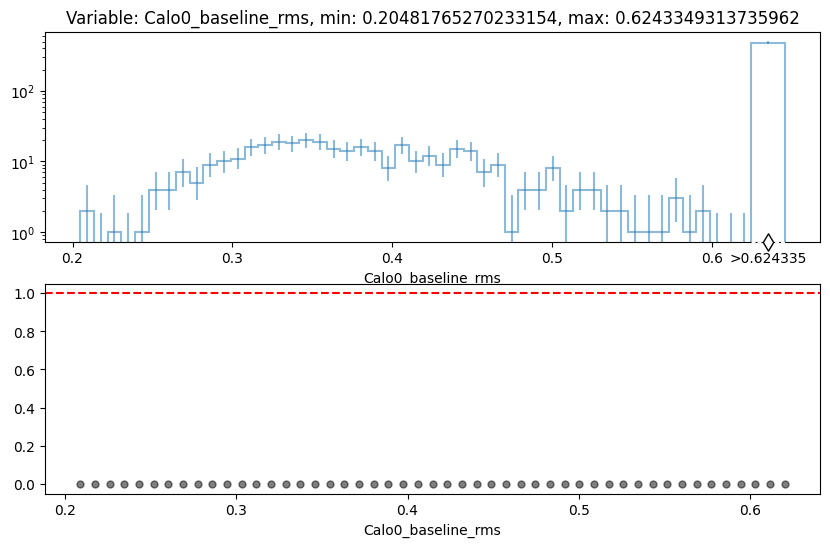

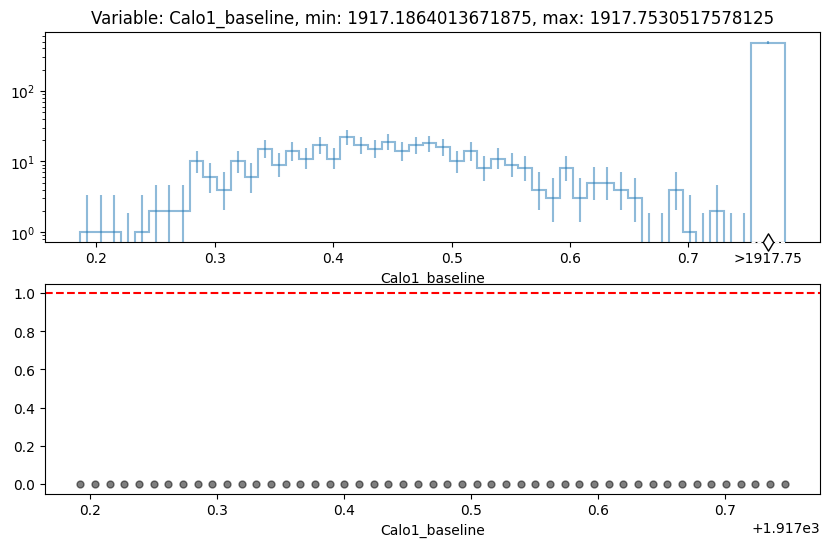

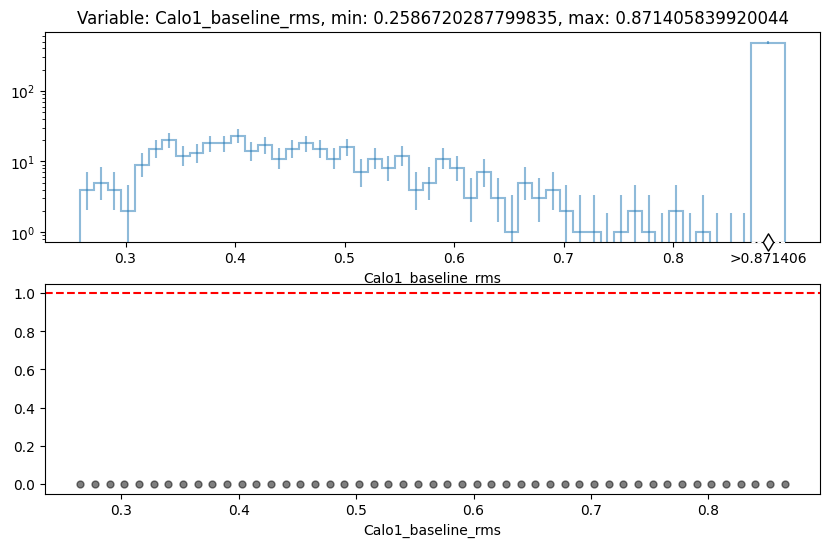

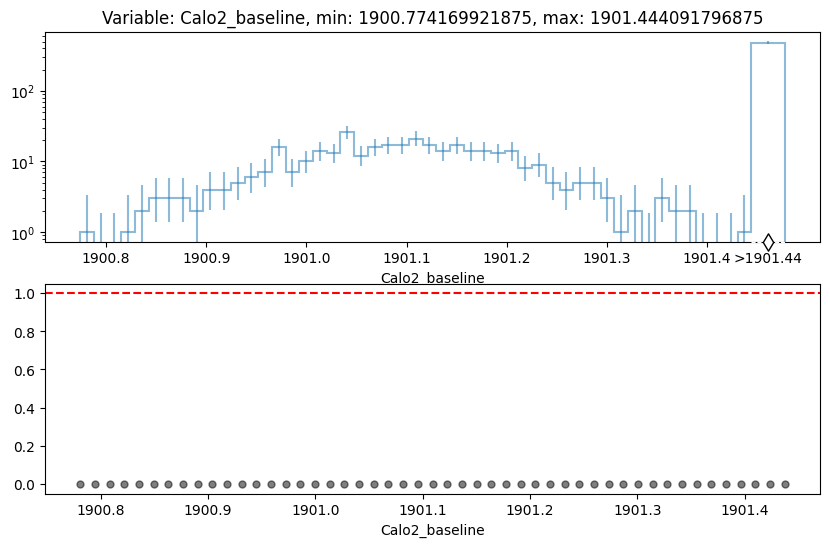

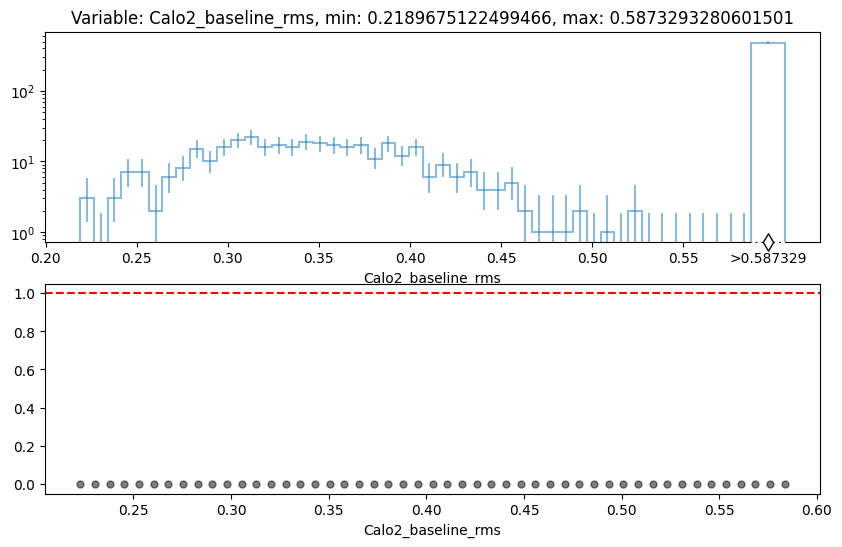

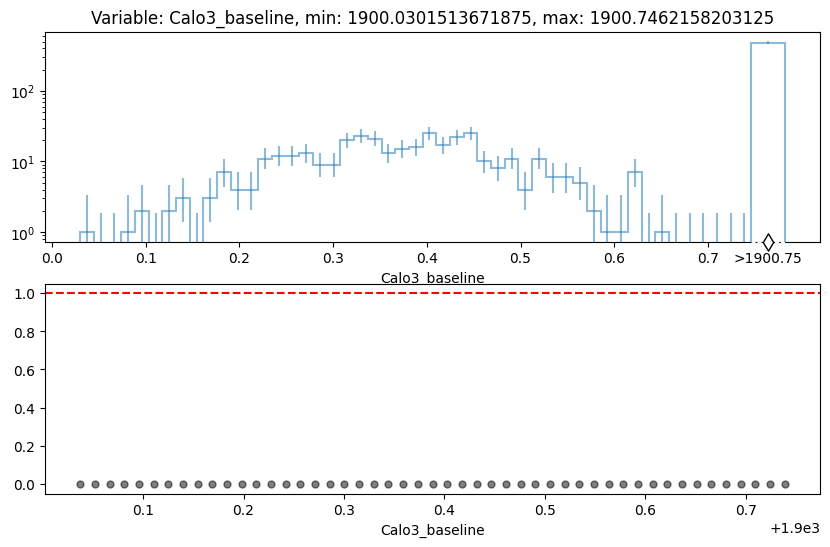

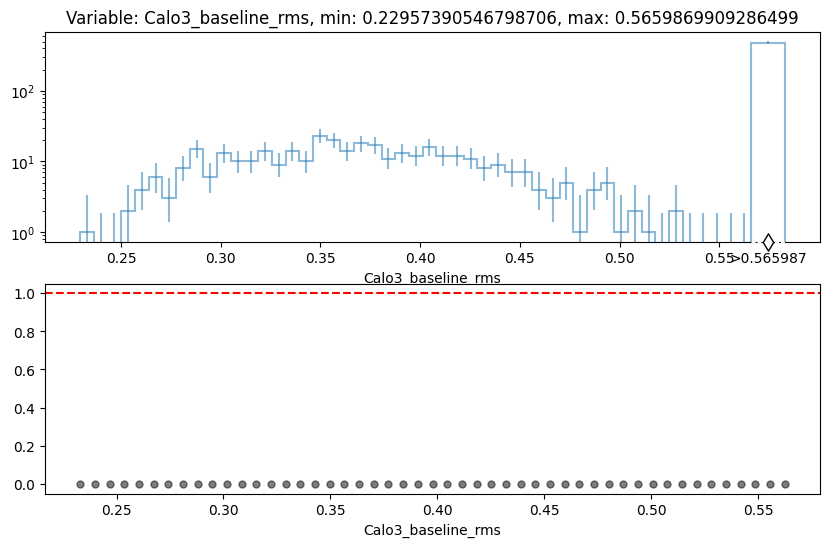

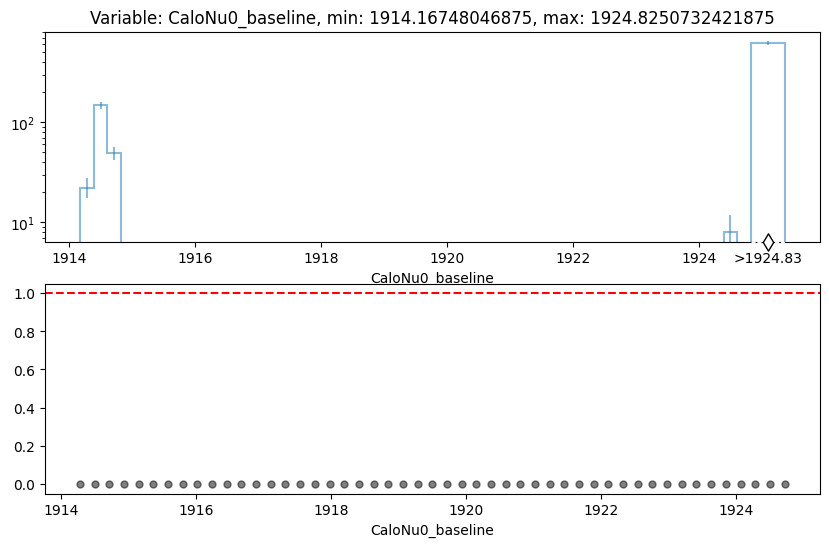

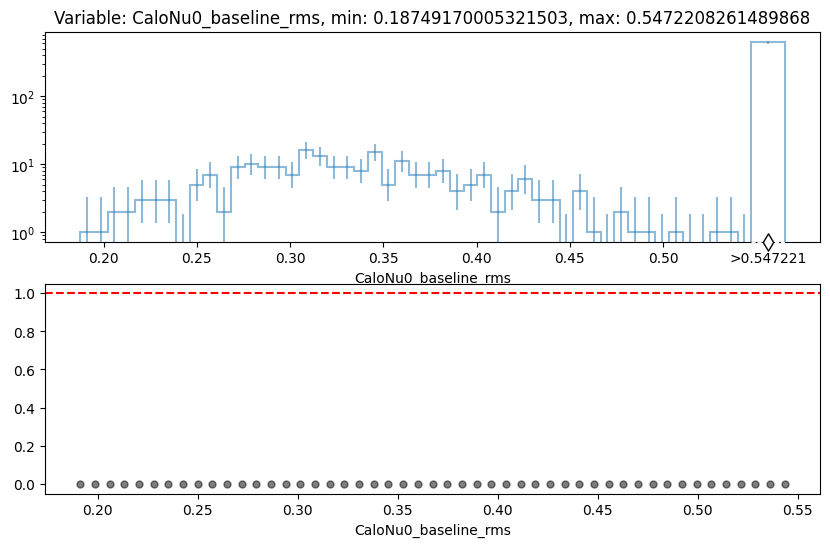

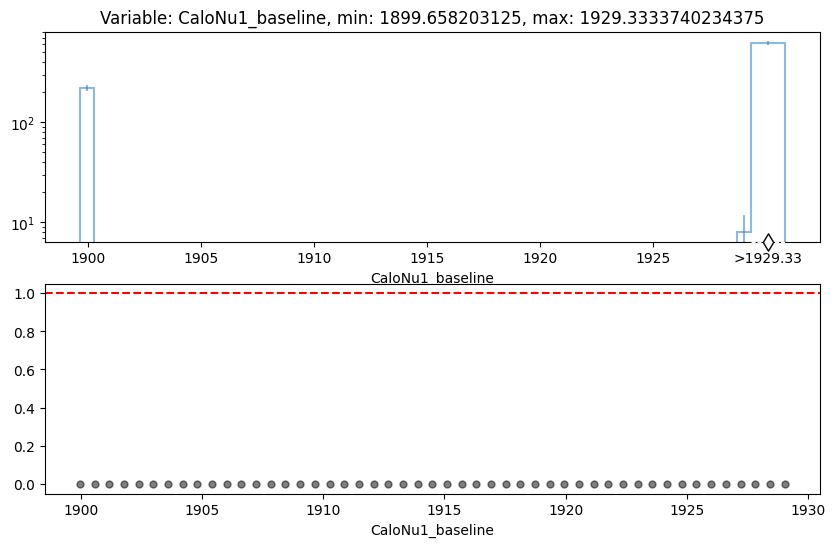

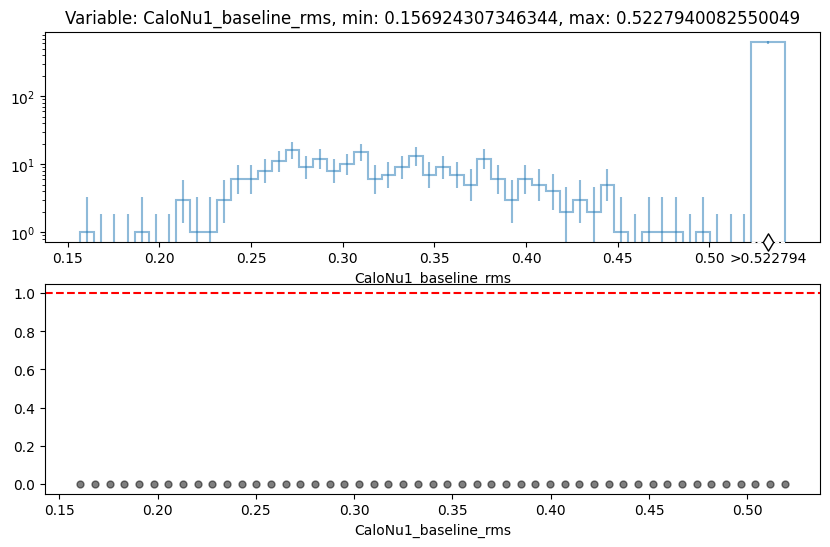

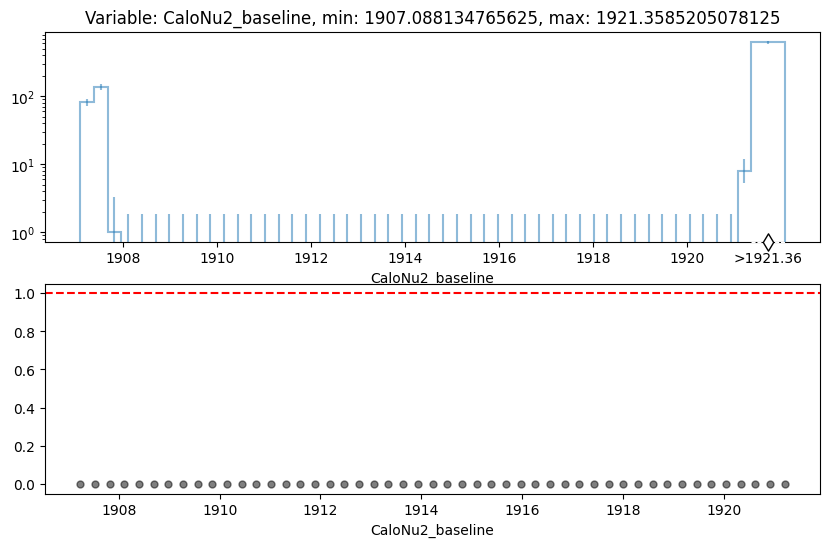

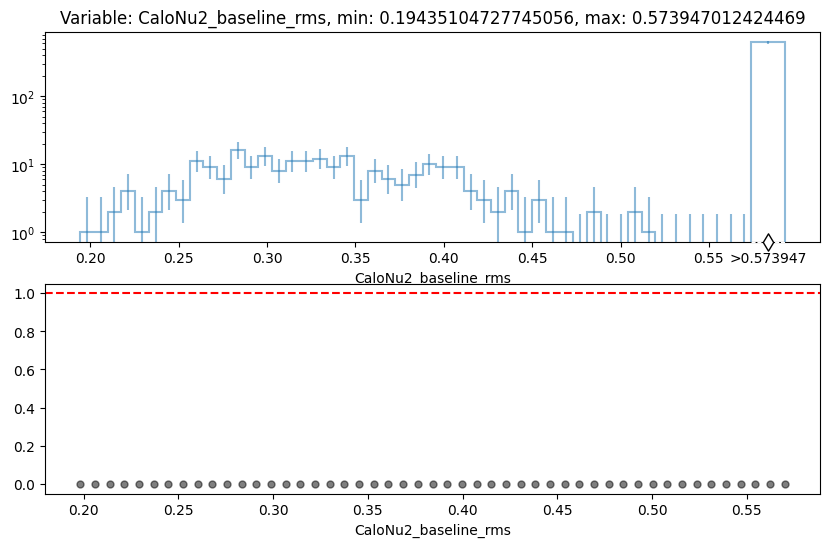

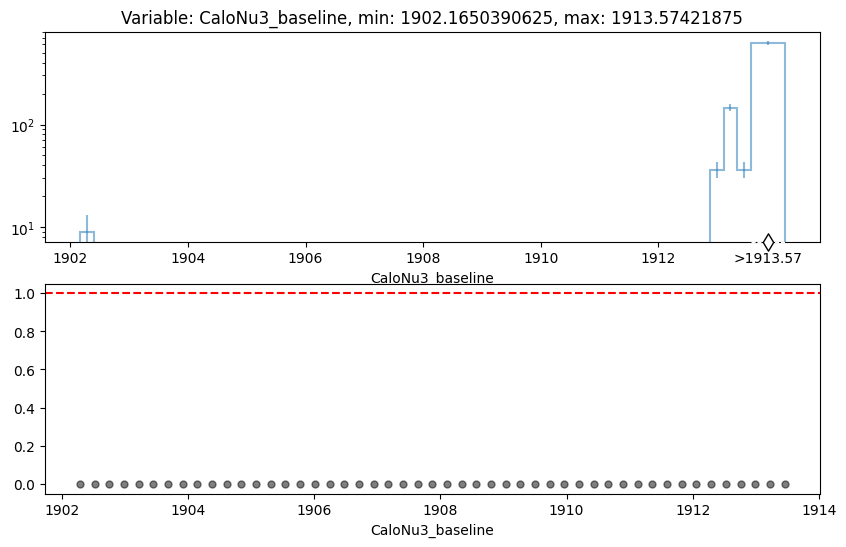

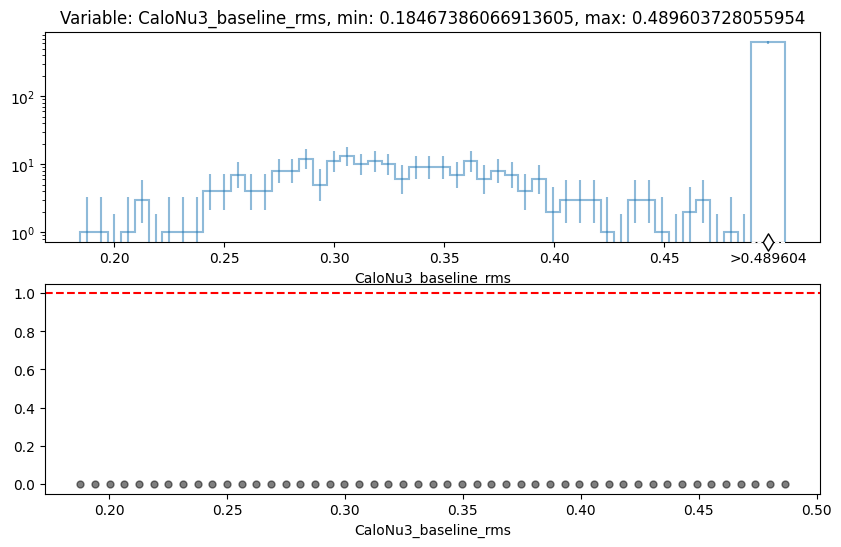

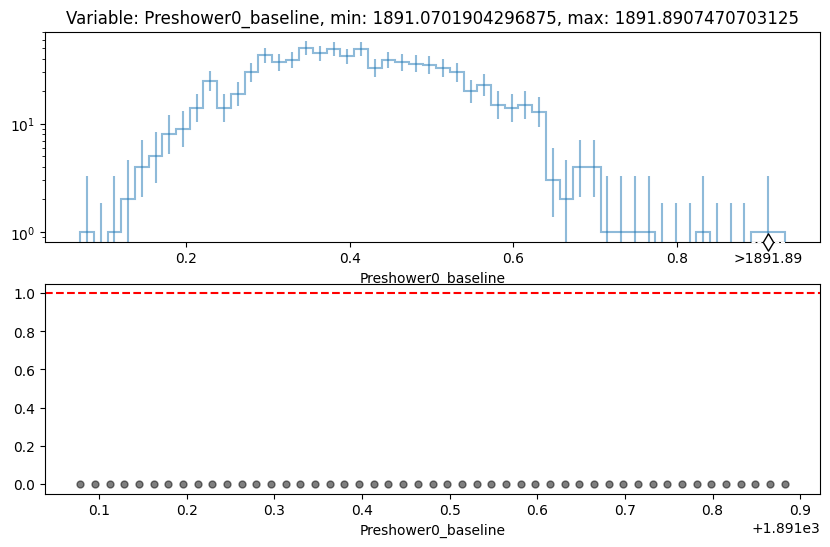

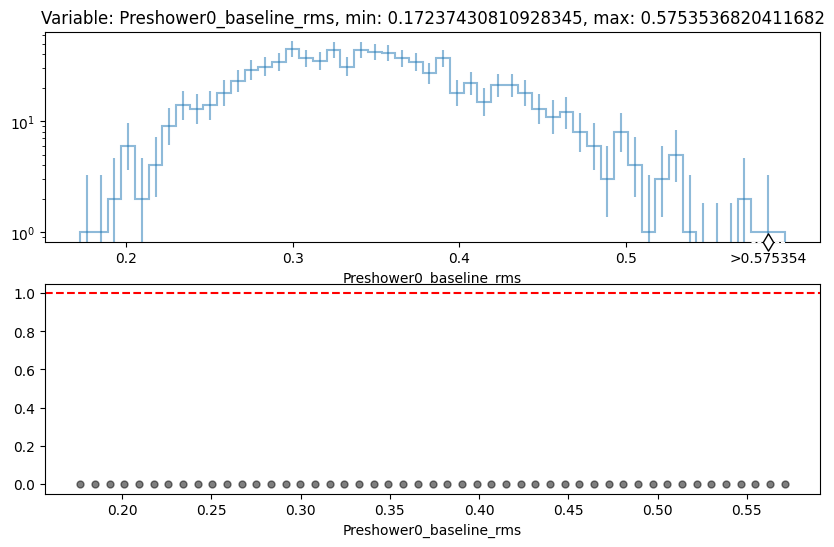

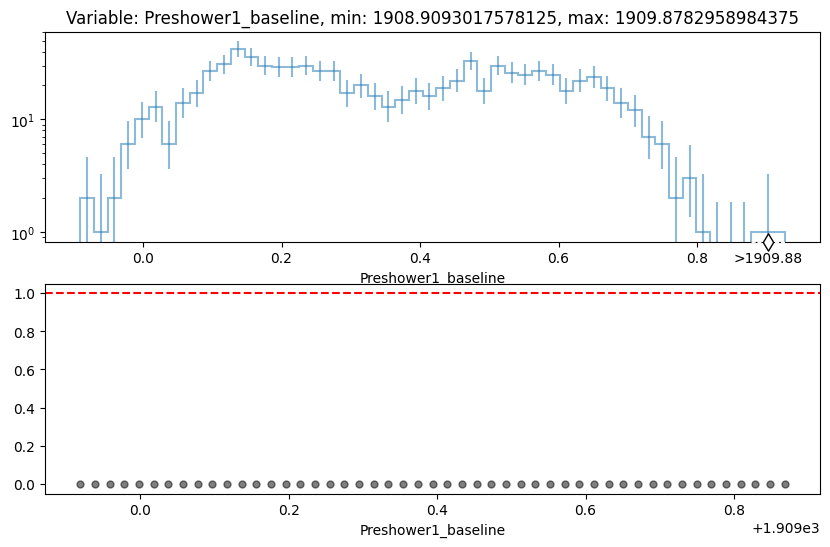

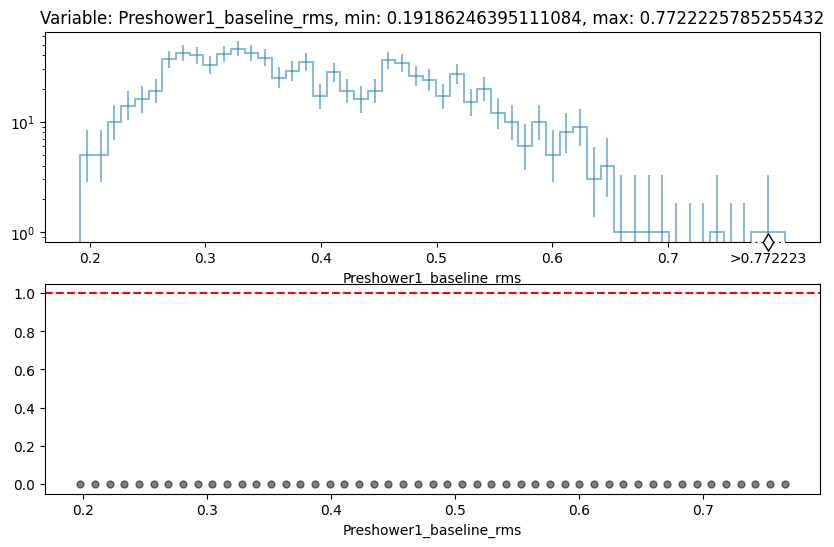

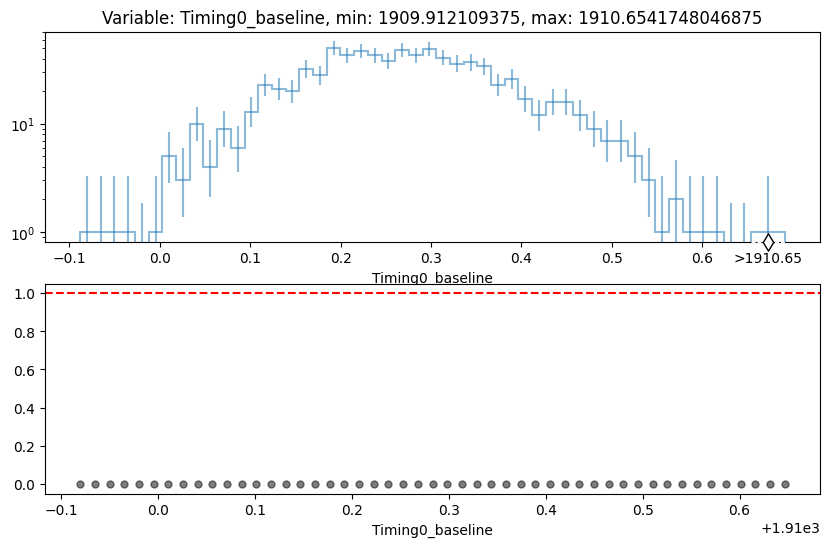

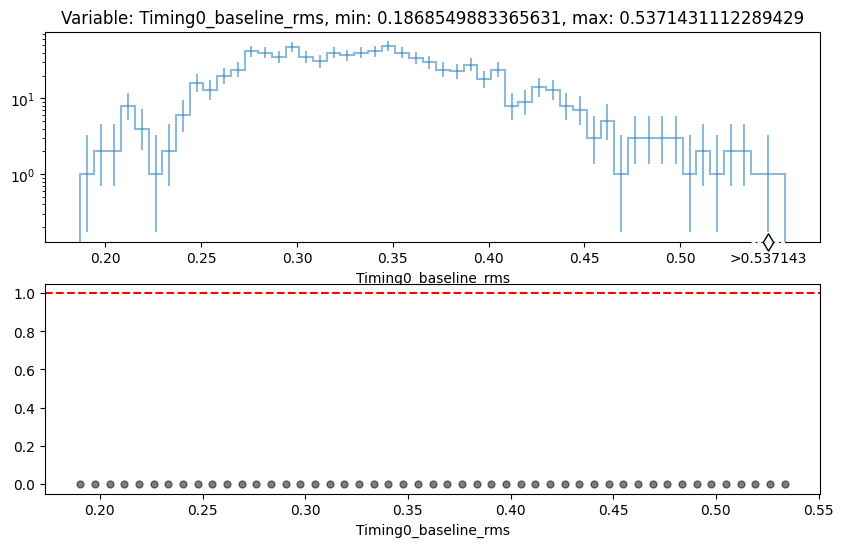

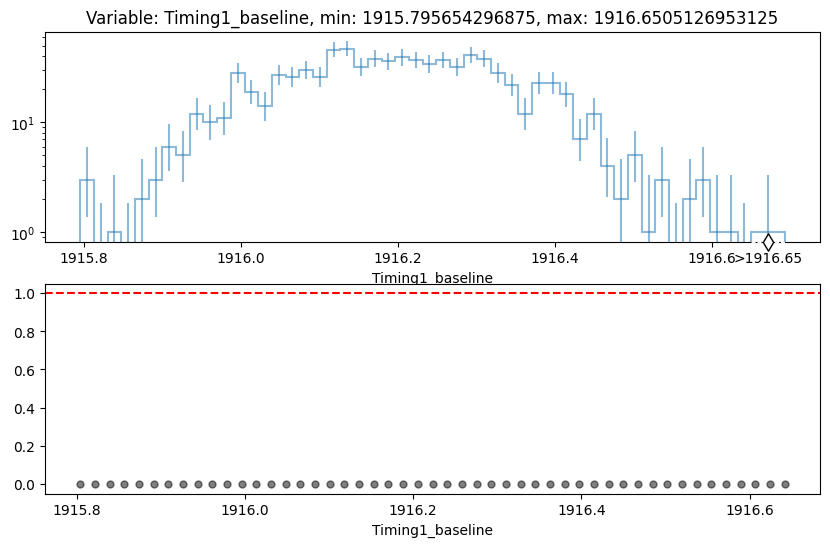

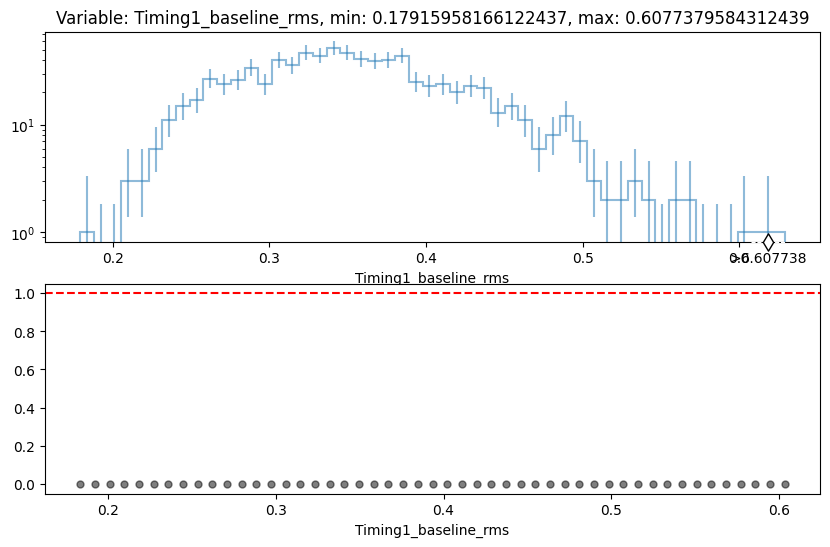

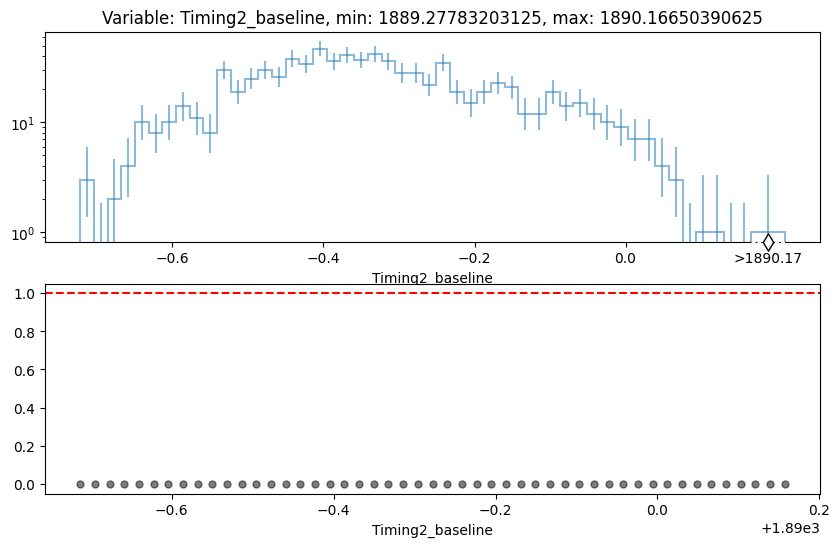

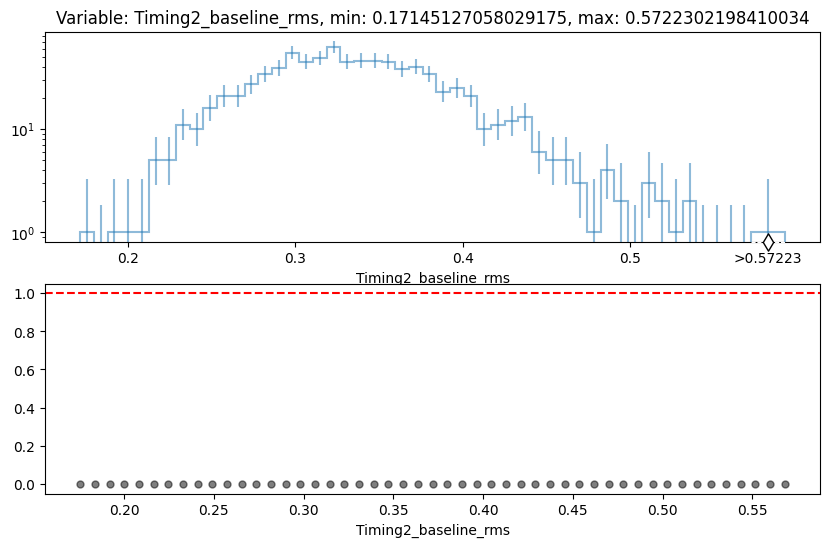

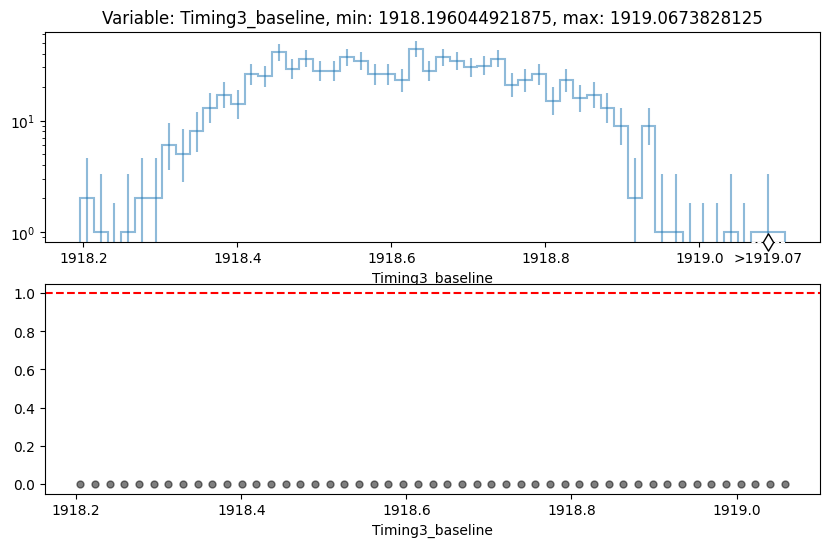

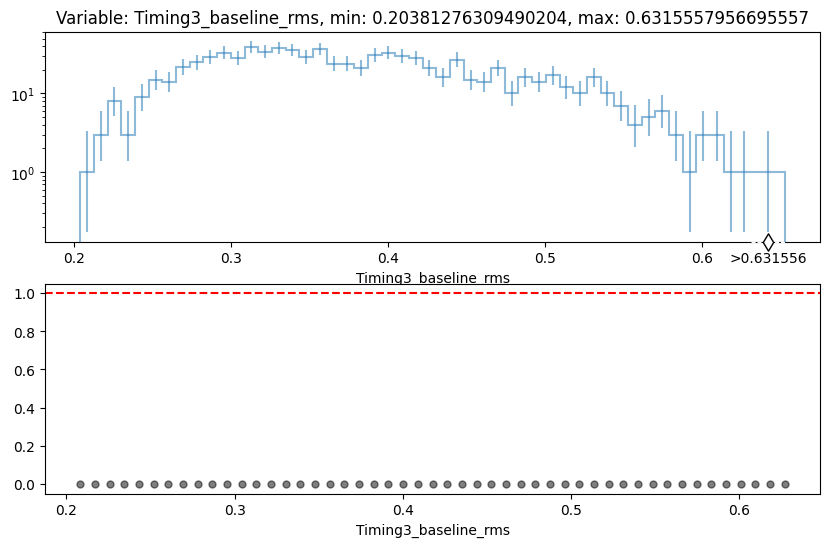

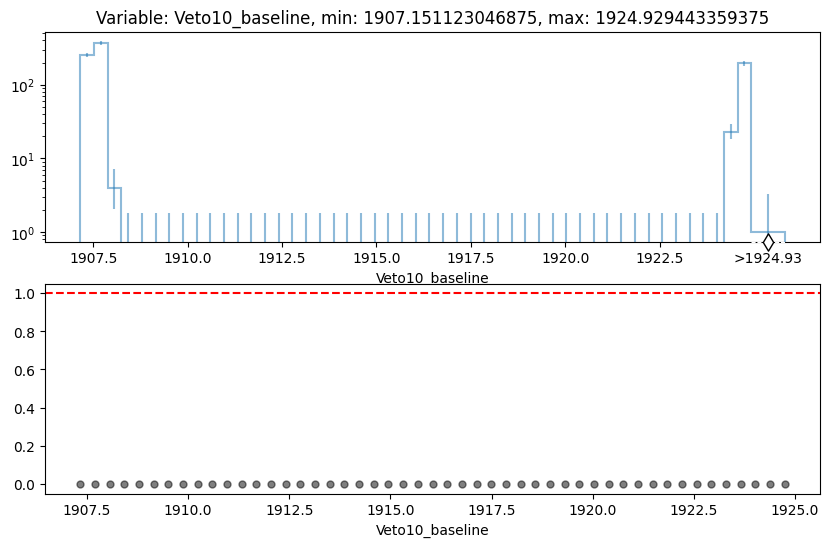

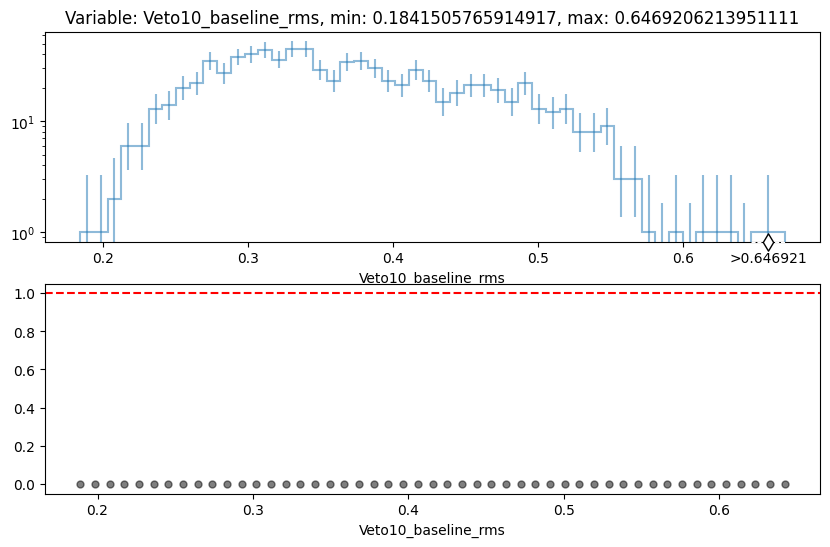

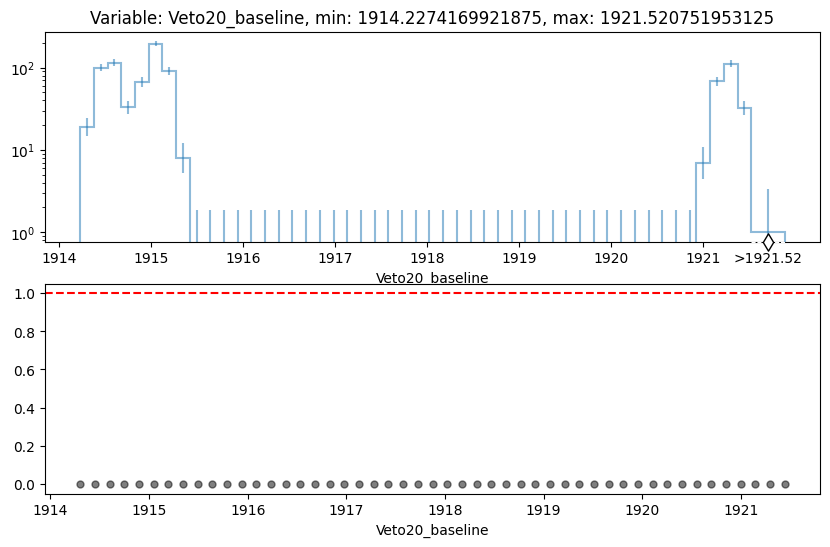

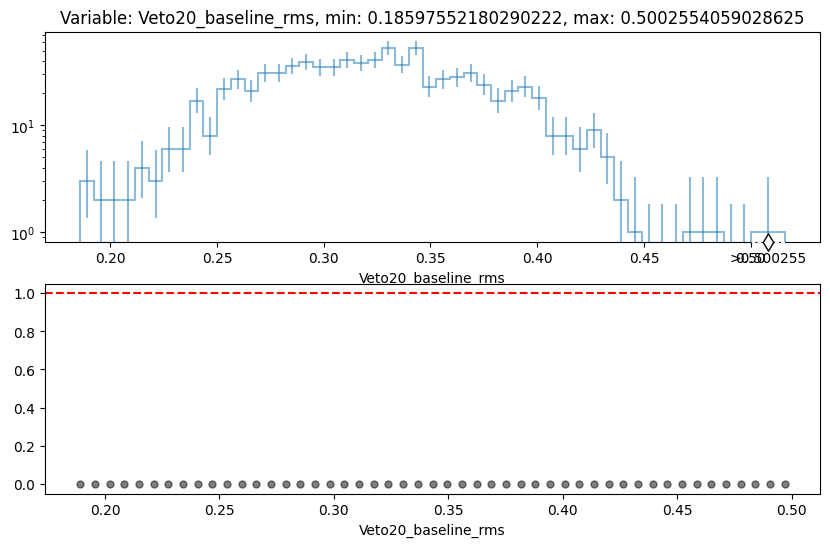

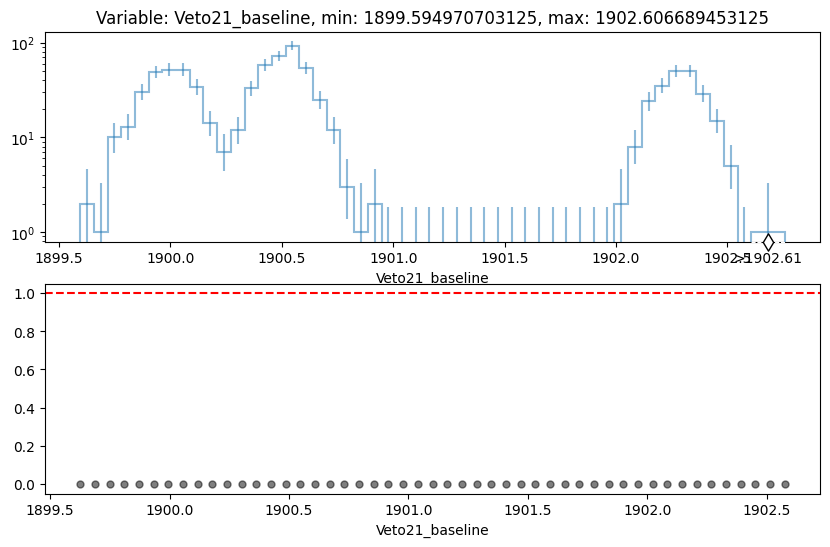

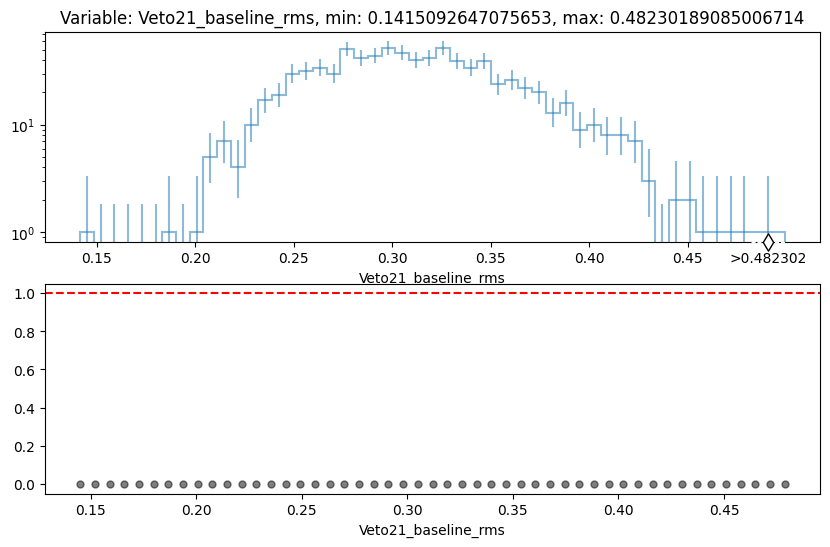

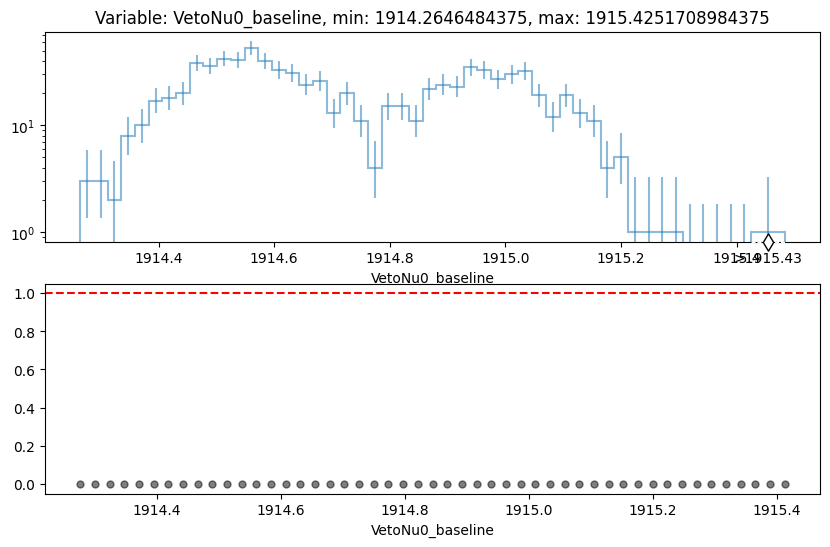

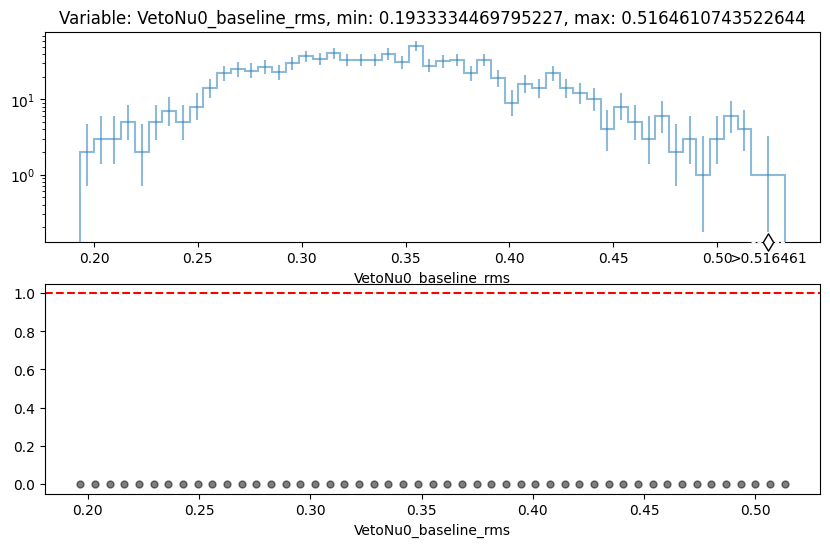

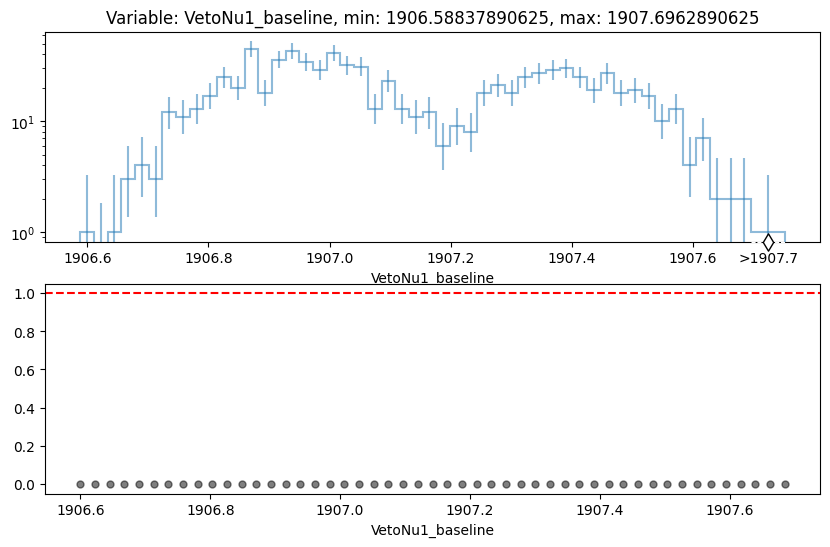

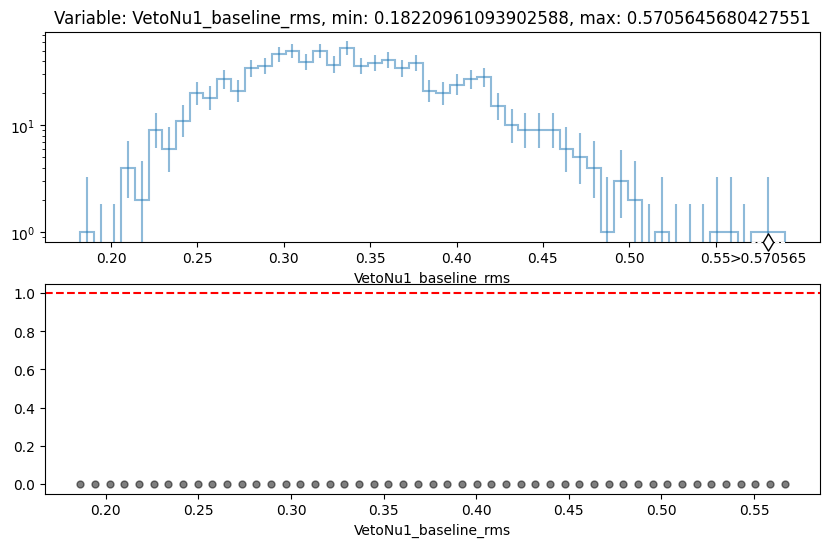

In [ ]:

for variable, wissals_var in zip(variable_names, variable_name_in_wissals_data):
    fig, ax = plt.subplots(figsize=(10, 6), nrows=2)

    
    my_var_data = ak.ravel(df_my_full_data[variable])
        # wissals_var_data = ak.ravel(df_wissals_data[wissals_var])
    # except KeyError as e:
    #     print(f"Variable {variable} not found in my data or wissals data: {e}")
    #     continue

    if variable == "LeadTrack_pz0" and wissals_var == "Track_pz_gev":
        my_var_data = my_var_data[my_var_data < 1e5]
        # wissals_var_data = wissals_var_data[wissals_var_data < 1e5]


    # bins = np.linspace(min(np.min(my_var_data), np.min(wissals_var_data)), max(np.max(my_var_data), np.max(wissals_var_data)), 50)
    bins = np.linspace(np.min(my_var_data), np.max(my_var_data), 50)

    if np.min(my_var_data) ==  np.max(my_var_data):
        print(f"Variable {variable} has the same value for all events: {np.min(my_var_data)}")
        continue


    my_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
    # her_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))

    my_hist.fill(my_var_data)
    # her_hist.fill(wissals_var_data)
    
    mplhep.histplot(my_hist, ax=ax[0], label="My data", alpha=0.5, flow="show")
    # mplhep.histplot(her_hist, ax=ax[0], label="Wissal's data", alpha=0.5, flow="show")

    # ax[0].hist(ak.ravel(df_my_full_data[variable]), bins=bins, alpha=0.5, label="My data")
    # ax[0].hist(ak.ravel(df_wissals_data[wissals_var]), bins=bins, alpha=0.5, label="Wissal's data",)
    ax[0].set_xlabel(variable)
    ax[0].set_yscale("log")

    # ratio plot
    # ratio = my_hist.view() / her_hist.view()
    ratio_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
    # ratio_hist.view()[:] = ratio
    mplhep.histplot(ratio_hist, ax=ax[1], label="My data / Wissal's data", alpha=0.5, histtype="errorbar", color="black", flow="show")
    ax[1].set_xlabel(variable)
    ax[1].axhline(y=1, color='r', linestyle='--')

    ax[0].set_title(f"Variable: {variable}, min: {np.min(my_var_data)}, max: {np.max(my_var_data)}")
    print(f"Variable: {variable}, min: {np.min(my_var_data)}, max: {np.max(my_var_data)}")
    
    # ax[0].set_xlim(min(np.min(my_var_data), np.min(wissals_var_data)), min(max(np.max(my_var_data), np.max(wissals_var_data)), 1e5))